# One-Phonon Diffuse Scattering — Rigid-Body Crystal (6o2h, P1)

One rigid body per unit cell (the lysozyme molecule), 6 degrees of freedom per
cell: a rotation $\Omega$ and a translation $v$. The crystal's phonons are the
normal modes of a Born–von Kármán lattice of these rigid bodies, coupled through
a small set of pairwise contact springs. This notebook builds the model from the
deposited structure, tests it end-to-end against **synthetic** data with a known
ground-truth stiffness, and visualizes the resulting phonon modes.

**Pipeline:** atomic model and mass matrix → hybrid electron density → solvent
contrast → molecular transform $F,L$ → coupling vector $G(\mathbf q)$ → contact
detection, framing, and the geometric prior → dynamical matrix → band structure
and diffuse-scattering maps → synthetic-data refinement → sloppiness analysis →
predicted atomic displacement parameters → mode animations.

**Scope of the synthetic test.** Generating data and fitting it with the same code
paths validates the refinement machinery — the gradient, the optimizer, the
identifiability of $K$ — but not the forward model itself, since any error common
to generation and fitting cancels. The ADP comparison is the clearest instance:
$\Sigma_{\rm true}$ against $\Sigma_{\rm fit}$ is insensitive to a systematic
error in $\Sigma$. The forward model is therefore checked separately, by
assertions that do not depend on the ground truth: the molecular transform against
brute-force summation and against the measured amplitudes, and the two intensity
code paths against each other.

In [1]:
import io
import pathlib
from itertools import product

import numpy as np
import gemmi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D
import scipy.constants as const
from scipy.spatial import cKDTree
from scipy.linalg import eigh
from scipy.ndimage import zoom as nd_zoom
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components as sc_connected_components
from scipy.interpolate import griddata
from scipy.optimize import minimize
from scipy.spatial.transform import Rotation as Rot
import imageio
import imageio.v2 as iio2
from skimage.measure import marching_cubes
from IPython.display import Image as IPImage, display
import gc

np.set_printoptions(precision=4, suppress=True)

def fig_to_image(fig, dpi=72):
    """Rasterize a matplotlib figure to an RGB array, for building GIFs."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    buf.seek(0)
    return iio2.imread(buf)[:, :, :3]


In [2]:
PDB_FILE = pathlib.Path("6o2h.cif")
SF_CIF   = pathlib.Path("6o2h-sf.cif")

D_MIN_MODEL    = 1.5    # Å — resolution for the visualization/reference density
RATE_MODEL     = 1.5
CONTACT_CUTOFF = 4.0    # Å — atom-atom cutoff defining a rigid-body contact
MIN_CONTACTS   = 5      # minimum atom-atom pairs for a contact to count
MAX_IMAGE      = 1      # search ±MAX_IMAGE unit cells (verified sufficient below)
D_MIN_DIFFUSE  = 3.0    # Å — resolution cutoff for the diffuse map
NPLOT_HK       = 8      # sub-integer grid density per Miller index
TEMPERATURE    = 300.0  # K — used only for the frequency-unit conversion

# --- Prior and regularization ---------------------------------------------
# PRIOR_K_PER_PAIR is the stiffness of one atom-pair contact spring, in k_BT/Å².
# 1 k_BT/Å² = 0.414 N/m, a reasonable order of magnitude for a weak non-covalent
# contact (vdW ≈ 1 N/m, H-bond ≈ 10-100 N/m). The prior's *shape* — how it
# scales with the number of atom pairs, and the κ_R/κ_T ratio — is fixed by the
# contact geometry and is the part that matters; this scalar only sets where the
# refinement starts.
PRIOR_K_PER_PAIR = 1.0
LAMBDA_PRIOR     = 3e-1   # weight on the geodesic distance to the prior. This
                          # is what gives the poorly-determined directions a
                          # restoring force; set it from the held-out scan below
                          # the refinement, not by eye.

REG_EIG_FLOOR = 1e-10     # relative eigenvalue floor in the matrix logarithm used
                          # by the geodesic regularizer


# --- Molecular transform from the experimental density ---------------------
# The transform is computed from the hybrid map (measured |F|, model phases),
# unwrapped onto a single molecule. D_MIN_TRANSFORM sets the density grid's
# sampling and should be comfortably finer than the resolution at which the
# diffuse model is used: masking one molecule out of a periodic map convolves
# its transform with the mask transform, so nearby |q| mix and a cutoff sitting
# exactly at the diffuse limit would bite.
D_MIN_TRANSFORM = 2.0     # Angstrom - resolution cutoff for the transform density
RATE_TRANSFORM  = 2.5     # grid oversampling rate (spacing ~ d_min/rate)
UNWRAP_IMAGE    = 1       # lattice images searched when assigning voxels to a
                          # molecule; verified sufficient at run time
TRANSFORM_MEM_MB  = 512   # memory budget for the scattered-point transform

# --- Bulk solvent ----------------------------------------------------------
# The object that moves rigidly is the CONTRAST density rho_prot - rho_sol*M,
# not the raw density: when a molecule displaces, the hole it occupies in the
# solvent moves with it, while the uniform bulk does not. SOLVENT_PROBE sets the
# excluded-volume envelope (van der Waals surface plus probe), SOLVENT_EDGE
# softens it -- a hard mask edge rings in Fourier space -- and SOLVENT_SHELL is
# the extra margin used when reading the flat solvent level off the map.
SOLVENT_PROBE = 1.1       # Angstrom beyond the vdW surface: the envelope
SOLVENT_EDGE  = 0.7       # Angstrom: tanh softening width of the envelope
SOLVENT_SHELL = 1.5       # Angstrom further out: margin for the level estimate

CHUNK_EVAL = 20000      # q-points per batch in the vectorized evaluators
BZ_NGRID   = 20         # Brillouin-zone grid for the ADP integral (convergence
                        # is checked explicitly, never assumed)

np.set_printoptions(precision=4, suppress=True)

In [3]:
st = gemmi.read_structure(str(PDB_FILE))
st.remove_hydrogens()
st.remove_waters()
st.setup_entities()

cell = st.cell
a1 = np.array(cell.orthogonalize(gemmi.Fractional(1,0,0)).tolist())
a2 = np.array(cell.orthogonalize(gemmi.Fractional(0,1,0)).tolist())
a3 = np.array(cell.orthogonalize(gemmi.Fractional(0,0,1)).tolist())
A_orth  = np.column_stack([a1, a2, a3])       # orthogonalization matrix
B_recip = 2*np.pi * np.linalg.inv(A_orth).T   # reciprocal lattice (columns)

print(f"Cell: {cell.a:.3f}×{cell.b:.3f}×{cell.c:.3f} Å  "
      f"α={cell.alpha:.2f} β={cell.beta:.2f} γ={cell.gamma:.2f}°")
print(f"Space group: {st.spacegroup_hm}   Volume: {cell.volume:.1f} Å³")


Cell: 27.424×32.134×34.513 Å  α=88.66 β=108.46 γ=111.88°
Space group: P 1   Volume: 26616.9 Å³


## Electron Density and the Molecular Transform

The density is the **hybrid map**: experimentally measured structure-factor
amplitudes with phases from the refined model. Compared with an isolated-atom
form-factor table it carries bonding density, ordered solvent, and the real static
and dynamic disorder.

It is also the appropriate density on physical grounds. The hybrid map is the
crystallographic **average** density — the instantaneous molecular density
convolved with the displacement distribution, $F_{\rm avg}=F_0e^{-W}$. The
one-phonon intensity requires $|F_0|^2e^{-2W}$, which is exactly
$|F_{\rm avg}|^2$, so the Debye–Waller factor enters with no separate bookkeeping
and no choice about whether to apply the deposited ADPs.

$F(000)$ is not a measured reflection, so the map integrates to zero over the
cell: it is the true density minus the **cell average** $\bar\rho=Z_{\rm cell}/V$.
That is distinct from the bulk solvent level, which is measured from the map in
the solvent section below.

### Unwrapping onto a single molecule

The grid holds the **crystal** density
$\rho_c(\mathbf r)=\sum_{\mathbf n}\rho_{\rm mol}(\mathbf r-\mathbf T_{\mathbf n})$
folded into one box. Transforming it directly gives

$$F_{\rm cell}(\mathbf q)=\sum_{\mathbf n}e^{-i\mathbf q\cdot\mathbf T_{\mathbf n}}
\int_{\rm box-\mathbf T_{\mathbf n}}\rho_{\rm mol}(\mathbf r')
e^{-i\mathbf q\cdot\mathbf r'}\,d^3r'$$

At **integer** $hkl$ every phase factor is 1 and $F_{\rm cell}=F_{\rm mol}$. At
the **fractional** $hkl$ this pipeline runs on they are not, and the parts of the
molecule folded across a cell boundary return with the wrong phase. No roll of the
grid avoids this for a protein, whose molecular region tiles space.

Each voxel is therefore assigned to the molecular image it belongs to — nearest
atom surface over all lattice images — giving it an integer translation
$\mathbf n_v$. Its position in the molecule's own frame is
$\mathbf r_v-\mathbf T_{\mathbf n_v}$, so

$$F_{\rm mol}(\mathbf q)=\sum_v\rho_v\,
e^{-i\mathbf q\cdot\mathbf r_v}\;e^{+2\pi i\,(h,k,l)\cdot\mathbf n_v}\,dV$$

The correction is a per-voxel phase, equal to 1 at integer $hkl$, so this reduces
to the ordinary structure factor there. $\mathbf n_v$ takes only a handful of
distinct values, so the sum splits into a small number of ordinary transforms, one
per translation group — which also lets each group use the separable axis-by-axis
contraction. Checked below against brute-force summation over explicitly unwrapped
coordinates.

*Provenance.* The density-based approach follows Meisburger, Case & Ando; the
grouping-by-translation formulation here is reconstructed from the physics rather
than transcribed, so the specifics are worth checking against the paper and the
`mdx2` source.

In [4]:
# --- Atomic model: positions, masses, deposited ADPs, mass matrix ----------
# Built FIRST, because r_cm_at is the reference point for G, for D, and for the
# ADP projection alike -- the mass matrix M = diag(J, m I) is block-diagonal only
# about the centre of mass, and the (Omega, v) split of a rigid displacement
# depends on which point you reference it to.
ATOMIC_MASS = {'C':12.011,'N':14.007,'O':15.999,'S':32.06,'P':30.974,
               'SE':78.96,'H':1.008,'FE':55.845,'ZN':65.38,'CA':40.078}

masses, apos, b_exp, u_exp, has_aniso, elem_names, Zs = [], [], [], [], [], [], []
for ch in st[0]:
    for res in ch:
        for atom in res:
            masses.append(ATOMIC_MASS.get(atom.element.name.upper(), 12.0))
            apos.append(atom.pos.tolist())
            b_exp.append(atom.b_iso)
            u_exp.append(atom.aniso.as_mat33().tolist())
            has_aniso.append(atom.aniso.nonzero())
            elem_names.append(atom.element.name)
            Zs.append(atom.element.atomic_number)
masses = np.array(masses); apos = np.array(apos); b_exp = np.array(b_exp)
u_exp = np.array(u_exp); has_aniso = np.array(has_aniso)
Z_model = float(np.sum(Zs))          # electrons in the deposited model
all_pos = apos                      # same array, used by the contact search below
n_atoms = len(apos)

m_total = masses.sum()
r_cm_at = (masses[:, None]*apos).sum(0)/m_total     # THE reference point
dr_a    = apos - r_cm_at
r2      = (dr_a**2).sum(1)
J       = (masses[:, None, None]*(r2[:, None, None]*np.eye(3)[None]
          - dr_a[:, :, None]*dr_a[:, None, :])).sum(0)
M_mat   = np.block([[J, np.zeros((3,3))], [np.zeros((3,3)), m_total*np.eye(3)]])
Msq     = np.linalg.cholesky(M_mat)
Msq_inv = np.linalg.inv(Msq)

kBT_SI     = const.k * TEMPERATURE
omega_unit = np.sqrt(kBT_SI / (const.atomic_mass * (1e-10)**2))
freq_unit  = omega_unit / (2*np.pi) / 1e12   # THz per sqrt(reduced stiffness/mass)

print(f"{n_atoms} atoms   total mass {m_total:.0f} amu")
print(f"Centre of mass r_cm_at = ({r_cm_at[0]:.3f}, {r_cm_at[1]:.3f}, {r_cm_at[2]:.3f}) Å")
print(f"Deposited ANISOU records present for {has_aniso.mean():.1%} of atoms")
print(f"Deposited mean B = {b_exp.mean():.2f} Å²")
print(f"Frequency unit: 1 (k_BT/amu/Å²)^½ = {freq_unit:.3f} THz")
print(f"Model electron count Z = {Z_model:.0f} e⁻ "
      f"(no hydrogens in the deposited model, so ~12-14% low)")


1151 atoms   total mass 15368 amu
Centre of mass r_cm_at = (-0.936, 14.029, 24.288) Å
Deposited ANISOU records present for 100.0% of atoms
Deposited mean B = 13.11 Å²
Frequency unit: 1 (k_BT/amu/Å²)^½ = 2.514 THz
Model electron count Z = 7690 e⁻ (no hydrogens in the deposited model, so ~12-14% low)


In [5]:
# --- Hybrid density: measured |F|, model phases ----------------------------
# Phases come from the calculated model density; amplitudes are the experimental
# ones wherever a measurement exists. F(000) is not measured, so the result has
# zero mean -- it is a CONTRAST density about the cell average, which is exactly
# what scatters at q != 0 (see markdown above).

def _good_fft_size(n):
    """Smallest even 2,3,5-smooth integer >= n (FFT-friendly)."""
    n = max(4, int(np.ceil(n)))
    while True:
        m = n
        for p in (2, 3, 5):
            while m % p == 0:
                m //= p
        if m == 1 and n % 2 == 0:
            return n
        n += 1

# --- Measured amplitudes ---------------------------------------------------
doc_sf = gemmi.cif.read(str(SF_CIF))
rb     = gemmi.as_refln_blocks(doc_sf)[0]
miller = np.array(rb.make_miller_array())
F_meas = np.array(rb.make_float_array("F_meas_au"))
ok = np.isfinite(F_meas) & (F_meas > 0)
miller, F_meas = miller[ok], F_meas[ok]

q_refl = miller @ B_recip.T
d_refl = 2*np.pi/np.maximum(np.linalg.norm(q_refl, axis=1), 1e-9)
use = d_refl >= D_MIN_TRANSFORM
mil_u, Fm_u = miller[use], F_meas[use]

# --- Transform grid --------------------------------------------------------
# Sampling is set by D_MIN_TRANSFORM, which should be comfortably finer than the
# resolution at which the diffuse model is used -- masking a molecule out of a
# periodic map convolves its transform with the mask transform, so nearby |q|
# mix and a cutoff exactly at the diffuse limit would bite.
#
# The grid must also satisfy n_i >= 2*h_max_i + 1 or distinct reflections fold
# onto the same point. h_max is taken from the actual indices rather than from
# a/d_min, which under-estimates it for a triclinic cell.
h_lim = np.abs(mil_u).max(axis=0)
n_tr = [_good_fft_size(max(RATE_TRANSFORM*L/D_MIN_TRANSFORM, 2*hm + 1))
        for L, hm in zip((cell.a, cell.b, cell.c), h_lim)]
nu, nv, nw = n_tr
spacing = np.array([cell.a/nu, cell.b/nv, cell.c/nw])

# --- Model phases ----------------------------------------------------------
dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN_MODEL; dc.rate = RATE_MODEL
dc.set_grid_cell_and_spacegroup(st)
dc.initialize_grid()
dc.add_model_density_to_grid(st[0])
dc.grid.symmetrize_sum()
rho_model = np.array(dc.grid)                   # also reused for the isosurface
nu_m, nv_m, nw_m = rho_model.shape
assert min(nu_m, nv_m, nw_m) >= 2*h_lim.max() + 1, "model grid too coarse for phase lookup"
F_calc_grid = np.fft.ifftn(rho_model)

ph = np.angle(F_calc_grid[mil_u[:,0] % nu_m, mil_u[:,1] % nv_m, mil_u[:,2] % nw_m])
F_hyb = Fm_u*np.exp(1j*ph)

# rho(r) = (1/V) sum_h F_h exp(-2 pi i h.r) -- numpy's forward fftn convention.
F_grid = np.zeros((nu, nv, nw), dtype=complex)
F_grid[mil_u[:,0] % nu, mil_u[:,1] % nv, mil_u[:,2] % nw] = F_hyb/cell.volume
F_grid[(-mil_u[:,0]) % nu, (-mil_u[:,1]) % nv, (-mil_u[:,2]) % nw] = F_hyb.conj()/cell.volume
rho = np.fft.fftn(F_grid).real
dV  = cell.volume/rho.size

print(f"Transform grid: {nu}x{nv}x{nw} = {rho.size} voxels, "
      f"spacing {spacing.round(2)} A  (D_MIN_TRANSFORM = {D_MIN_TRANSFORM} A)")
print(f"Reflections used: {use.sum()} of {len(miller)}  "
      f"({d_refl[use].min():.2f}-{d_refl[use].max():.2f} A), |h|max = {tuple(h_lim)}")
print(f"Density RMS {rho.std():.4f} e-/A^3; cell integral "
      f"{rho.sum()*dV:.3f} e- (~0 by construction, F(000) unmeasured)")

# Missing low-order terms distort the molecular envelope far more than missing
# high-order ones, so report the low-resolution completeness explicitly.
n_low = int((d_refl[use] > 8.0).sum())
print(f"Reflections beyond 8 A: {n_low} "
      f"({'SPARSE -- the envelope may be distorted' if n_low < 30 else 'adequate'})")


Transform grid: 36x48x48 = 82944 voxels, spacing [0.76 0.67 0.72] A  (D_MIN_TRANSFORM = 2.0 A)
Reflections used: 6961 of 30103  (2.00-32.55 A), |h|max = (np.int32(13), np.int32(16), np.int32(17))
Density RMS 0.4446 e-/A^3; cell integral -0.000 e- (~0 by construction, F(000) unmeasured)
Reflections beyond 8 A: 109 (adequate)


In [6]:
# --- Unwrap the periodic density onto a single molecule --------------------
# Every voxel is assigned to the molecular image whose atom surface it sits
# nearest, over all lattice translations in +-UNWRAP_IMAGE. That assignment is a
# fundamental domain of the lattice: one voxel per orbit, so no density is
# double-counted or lost, and the images tile space.
#
# The assignment yields an integer translation n_v per voxel. In the molecule's
# own frame the voxel sits at r_v - T_{n_v}, so the transform picks up a per-voxel
# phase exp(+2*pi*i*(h,k,l).n_v) -- exactly 1 at integer hkl, which is why this
# reduces to the ordinary structure factor where it must.
#
# Assignment is by distance to the atom SURFACE (centre distance minus the van
# der Waals radius) rather than to the atom centre, so a large atom does not lose
# surface voxels to a small one nearby.

VDW_RADIUS = {'C':1.70,'N':1.55,'O':1.52,'S':1.80,'P':1.80,'H':1.20,
              'SE':1.90,'FE':2.00,'ZN':1.39,'CA':2.31,'MG':1.73,'CL':1.75}
vdw_at = np.array([VDW_RADIUS.get(e.upper(), 1.70) for e in elem_names])

ii = np.arange(nu)/nu; jj = np.arange(nv)/nv; kk = np.arange(nw)/nw
Ig, Jg, Kg = np.meshgrid(ii, jj, kk, indexing='ij')
r_grid = (A_orth @ np.stack([Ig, Jg, Kg]).reshape(3, -1)).T      # (N_vox, 3)
N_VOX  = len(r_grid)

_imgs = np.array([(i, j, k) for i in range(-UNWRAP_IMAGE, UNWRAP_IMAGE+1)
                            for j in range(-UNWRAP_IMAGE, UNWRAP_IMAGE+1)
                            for k in range(-UNWRAP_IMAGE, UNWRAP_IMAGE+1)])
_T_img   = _imgs @ A_orth.T
_pos_img = np.vstack([apos + T for T in _T_img])
_img_of  = np.repeat(np.arange(len(_imgs)), n_atoms)
_vdw_img = np.tile(vdw_at, len(_imgs))

# Query enough neighbours that the surface-distance winner is certainly among
# them, then re-rank by surface distance.
_tree_img = cKDTree(_pos_img)
_K_NEAR = 8
_dc, _ic = _tree_img.query(r_grid, k=_K_NEAR, workers=-1)
_ds_cand = _dc - _vdw_img[_ic]                      # distance to each atom SURFACE
_best    = np.argmin(_ds_cand, axis=1)
_rows    = np.arange(N_VOX)
_idx_near  = _ic[_rows, _best]
d_surface  = _ds_cand[_rows, _best]                 # (N_vox,) can be negative inside atoms
grp_img    = _img_of[_idx_near]
n_of_vox   = _imgs[grp_img]
r_mol      = r_grid - n_of_vox @ A_orth.T           # molecule-frame positions

groups  = np.unique(grp_img)
GRP_IDX = [np.where(grp_img == g)[0] for g in groups]
GRP_N   = _imgs[groups].astype(float)

print(f"Voxels assigned to {len(groups)} distinct lattice images "
      f"(of {len(_imgs)} searched, UNWRAP_IMAGE={UNWRAP_IMAGE})")
for g in groups:
    m = grp_img == g
    print(f"   n={tuple(_imgs[g])}: {m.sum():7d} voxels ({100*m.mean():5.1f}%)")

# Sufficiency of UNWRAP_IMAGE: a large share of voxels in NON-ZERO images is
# expected and harmless -- the molecule genuinely reaches into its neighbours.
# The meaningful test is whether widening the search by one shell would claim any
# voxels at all, so the assignment is repeated with UNWRAP_IMAGE+1 and the
# fraction landing beyond the original radius is reported.
def _assign_images(max_img):
    im  = np.array([(i, j, k) for i in range(-max_img, max_img+1)
                              for j in range(-max_img, max_img+1)
                              for k in range(-max_img, max_img+1)])
    pos = np.vstack([apos + T for T in im @ A_orth.T])
    dc, ic = cKDTree(pos).query(r_grid, k=_K_NEAR, workers=-1)
    ds = dc - np.tile(vdw_at, len(im))[ic]
    b  = np.argmin(ds, axis=1)
    return im, np.repeat(np.arange(len(im)), n_atoms)[ic[_rows, b]], ds[_rows, b]

_im_ext, _g_ext, _ = _assign_images(UNWRAP_IMAGE + 1)
_beyond = float((np.abs(_im_ext[_g_ext]).max(axis=1) > UNWRAP_IMAGE).mean())
if _beyond > 1e-3:
    print(f"NOTE: widening the search to {UNWRAP_IMAGE+1} shells claims {_beyond:.2%} "
          f"of voxels; raise UNWRAP_IMAGE.")
else:
    print(f"Widening the search to {UNWRAP_IMAGE+1} shells claims {_beyond:.3%} of "
          f"voxels: UNWRAP_IMAGE={UNWRAP_IMAGE} is sufficient.")

_span = r_mol.max(0) - r_mol.min(0)
print(f"Unwrapped molecular extent: {_span.round(1)} Å "
      f"(cell is {cell.a:.1f}×{cell.b:.1f}×{cell.c:.1f} Å -- the unwrapped molecule "
      f"is expected to be LARGER than the cell in at least one direction)")


Voxels assigned to 15 distinct lattice images (of 27 searched, UNWRAP_IMAGE=1)
   n=(np.int64(-1), np.int64(-1), np.int64(-1)):     305 voxels (  0.4%)
   n=(np.int64(-1), np.int64(-1), np.int64(0)):     716 voxels (  0.9%)
   n=(np.int64(-1), np.int64(0), np.int64(-1)):    1909 voxels (  2.3%)
   n=(np.int64(-1), np.int64(0), np.int64(0)):    2080 voxels (  2.5%)
   n=(np.int64(0), np.int64(-1), np.int64(-1)):     489 voxels (  0.6%)
   n=(np.int64(0), np.int64(-1), np.int64(0)):    6183 voxels (  7.5%)
   n=(np.int64(0), np.int64(0), np.int64(-1)):   17497 voxels ( 21.1%)
   n=(np.int64(0), np.int64(0), np.int64(0)):   49706 voxels ( 59.9%)
   n=(np.int64(0), np.int64(0), np.int64(1)):     283 voxels (  0.3%)
   n=(np.int64(0), np.int64(1), np.int64(-1)):     349 voxels (  0.4%)
   n=(np.int64(0), np.int64(1), np.int64(0)):     141 voxels (  0.2%)
   n=(np.int64(1), np.int64(0), np.int64(-1)):      63 voxels (  0.1%)
   n=(np.int64(1), np.int64(0), np.int64(0)):    3112 voxels (  3.8

### Bulk Solvent: the Excluded-Volume Contrast

**What moves.** Write the crystal density as protein plus a flat bulk solvent
filling the complement of the molecular envelope $M$:

$$\rho_c(\mathbf r)=\sum_{\mathbf n}\rho_{\rm prot}(\mathbf r-\mathbf T_{\mathbf n})
+\rho_{\rm sol}\Bigl[1-\sum_{\mathbf n}M(\mathbf r-\mathbf T_{\mathbf n})\Bigr]
=\underbrace{\rho_{\rm sol}}_{\text{static, uniform}}
+\sum_{\mathbf n}\underbrace{\bigl[\rho_{\rm prot}-\rho_{\rm sol}M\bigr]}
_{\textstyle\rho_{\rm eff},\ \text{moves rigidly}}(\mathbf r-\mathbf T_{\mathbf n})$$

When a molecule displaces, its atoms move and so does the hole it occupies in the
solvent — water rearranges behind it on a timescale far shorter than a phonon
period. The uniform bulk term does not move. The object whose motion generates
one-phonon diffuse scattering is therefore the **contrast** density
$\rho_{\rm eff}=\rho_{\rm prot}-\rho_{\rm sol}M$, the same quantity that governs
solution scattering.

**Negative regions.** Inside the envelope, wherever the protein's own density
falls below the bulk solvent level — interatomic voids, and the shell between the
flat-solvent boundary and the first atoms — the contrast is negative: those
regions hold fewer electrons than the solvent they displaced. Along a line running
from bulk solvent into the protein the profile is a flat plateau at
$\rho_{\rm sol}$, a dip **below** it through the excluded-volume shell, then a
rise to the atomic peaks. The first diagnostic panel below is that profile, and
it is the direct check on the subtraction.

**Babinet.** The solvent occupies the *complement* of the envelope, and
$\mathcal F[1]=\delta(\mathbf q)$, so

$$\mathcal F\bigl[\rho_{\rm sol}(1-M)\bigr]
=\rho_{\rm sol}V\,\delta_{\mathbf q,0}-\rho_{\rm sol}\mathcal F[M]
\;\xrightarrow{\ \mathbf q\neq0\ }\;-\rho_{\rm sol}\,\mathcal F[M]$$

Complementary regions scatter identically apart from the direct beam. That
equivalence is what allows solvent spread over the whole complement to be
represented as a **negative** density confined inside the envelope, making the
moving object compactly supported. It is the same flat bulk-solvent model used in
refinement, where $F_{\rm sol}=-k_{\rm sol}e^{-B_{\rm sol}s^2}F_{\rm mask}$.
Transforming a density with negative regions needs nothing special — the Fourier
transform is linear. Babinet justifies the *form* of $\rho_{\rm eff}$, not its
evaluation.

**Consequences for scale.** The contrast electron count is roughly
$Z_{\rm prot}-\rho_{\rm sol}V_{\rm mask}$, several times smaller than
$Z_{\rm prot}$, so $|F|$ at low $q$ drops by that factor and intensity by its
square. The effect is confined to low resolution: at high $hkl$ the envelope
transform $\mathcal F[M]$ is negligible and $F_{\rm eff}\to F_{\rm meas}$, which
the resolution-binned check in the transform cell confirms.

The envelope also makes the image-assignment boundary harmless. That boundary lies
in bulk solvent where $M\approx0$, so voxels with an ambiguous assignment
contribute nothing. At crystal contacts the envelopes of neighbouring molecules
overlap, and the nearest-surface rule splits the shared density between them.

Deep-solvent voxels: 3100 (3.7% of the cell), beyond 2.6 Å from any atom surface
Flat solvent level in the map: rho_sol = -0.0527 e⁻/Å³
Implied cell-average density:     0.3551 e⁻/Å³
Implied absolute solvent density: 0.3024 e⁻/Å³ (bulk water ≈ 0.335, no H in the model)

Envelope volume: 20793 Å³ (78% of the cell)
Contrast electrons  ∫rho_eff dV        =   1532.2 e⁻
  Z_model - rho_sol_abs*V_mask         =   1402.6 e⁻
  raw model electron count             =   7690.0 e⁻
  contrast/raw ratio: 0.199 in |F|, 0.0397 in intensity at low q
  flat-solvent identity  -rho_sol*V_cell =   1402.6 e⁻  (gap 8%)
Negative-density fraction inside the envelope: 58.2%
  (nonzero is CORRECT: excluded-volume regions hold fewer electrons than
   the solvent they displaced -- see the profile below.)

Contrast-density centroid: [-1.08 14.52 23.92] Å
Atomic centre of mass:     [-0.94 14.03 24.29] Å
  separation: 0.63 Å  (a few Å is normal for a contrast density; tens of Å means the unwrapping or the mask failed

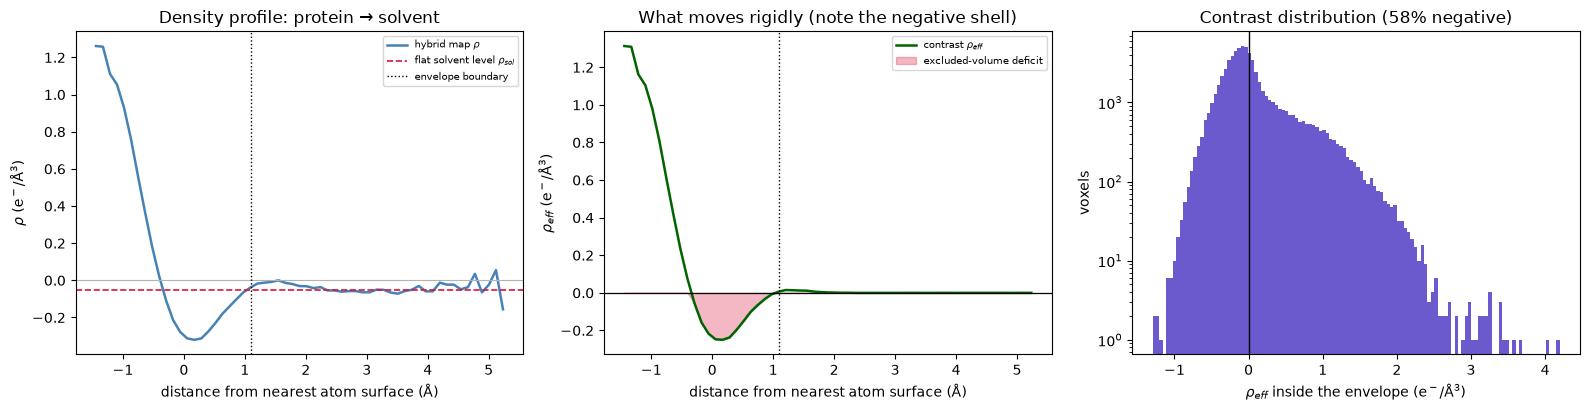

Left panel is the profile to check against the physical picture: a flat
plateau in bulk solvent, a dip BELOW it through the excluded-volume shell,
then the rise to the atomic peaks. If the plateau is not flat, or the
dashed line does not sit on it, the solvent level is misestimated.


In [7]:
# --- Flat bulk-solvent level ----------------------------------------------
# Read off the map itself, in the map's own offset, so no assumption about
# absolute scale is needed. "Deep solvent" = beyond the probe shell and a further
# margin, to stay clear of the transition region at the envelope boundary.
_deep = d_surface > (SOLVENT_PROBE + SOLVENT_SHELL)
if _deep.sum() < 0.005*N_VOX:
    print(f"WARNING: only {_deep.sum()} voxels ({100*_deep.mean():.3f}%) are deep "
          f"solvent; falling back to the outermost 2% by surface distance.")
    _deep = d_surface > np.quantile(d_surface, 0.98)
rho_sol_map = float(np.median(rho.ravel()[_deep]))

print(f"Deep-solvent voxels: {_deep.sum()} ({100*_deep.mean():.1f}% of the cell), "
      f"beyond {SOLVENT_PROBE + SOLVENT_SHELL:.1f} Å from any atom surface")
print(f"Flat solvent level in the map: rho_sol = {rho_sol_map:+.4f} e⁻/Å³")

# --- Excluded-volume envelope ---------------------------------------------
# Standard bulk-solvent mask: within SOLVENT_PROBE of an atom's van der Waals
# surface. Softened with a tanh ramp of width SOLVENT_EDGE rather than left as a
# step -- a hard mask edge rings in Fourier space, and the soft ramp is the real
# -space counterpart of the B_sol smearing applied to F_mask in refinement.
M_soft = 0.5*(1.0 - np.tanh((d_surface - SOLVENT_PROBE)/SOLVENT_EDGE))
V_mask = float(M_soft.sum()*dV)

# --- The density that moves rigidly ---------------------------------------
rho_eff = ((rho.ravel() - rho_sol_map)*M_soft).reshape(rho.shape)

# Absolute scale. The map is rho_true - rho_bar with rho_bar = Z_cell/V, and the
# cell holds protein plus solvent: Z_cell = Z_prot + rho_sol_abs*V_solv. With
# rho_sol_abs = rho_sol_map + rho_bar, that pair solves to
#     rho_bar = (Z_prot + rho_sol_map*V_solv)/V_mask
# The result should land near 0.33 e-/A^3 for water; the deposited model has no
# hydrogens, so Z_prot is low by ~12% and this check reads low with it.
V_solv      = cell.volume - V_mask
rho_bar     = (Z_model + rho_sol_map*V_solv)/V_mask
rho_sol_abs = rho_sol_map + rho_bar
print(f"Implied cell-average density:     {rho_bar:.4f} e⁻/Å³")
print(f"Implied absolute solvent density: {rho_sol_abs:.4f} e⁻/Å³ "
      f"(bulk water ≈ 0.335, no H in the model)")

_inside   = M_soft > 0.5
_neg_frac = float((rho_eff.ravel()[_inside] < 0).mean())
Q_contrast = float(rho_eff.sum()*dV)

print(f"\nEnvelope volume: {V_mask:.0f} Å³ ({100*V_mask/cell.volume:.0f}% of the cell)")
print(f"Contrast electrons  ∫rho_eff dV        = {Q_contrast:8.1f} e⁻")
print(f"  Z_model - rho_sol_abs*V_mask         = {Z_model - rho_sol_abs*V_mask:8.1f} e⁻")
print(f"  raw model electron count             = {Z_model:8.1f} e⁻")
print(f"  contrast/raw ratio: {Q_contrast/Z_model:.3f} in |F|, "
      f"{(Q_contrast/Z_model)**2:.4f} in intensity at low q")
# Since the map integrates to zero over the cell, ∫rho_eff dV = -rho_sol*V_cell
# exactly IF the map is flat at rho_sol throughout the solvent region. The gap
# between the two measures how well that flat-solvent assumption holds.
print(f"  flat-solvent identity  -rho_sol*V_cell = {-rho_sol_map*cell.volume:8.1f} e⁻  "
      f"(gap {100*abs(Q_contrast + rho_sol_map*cell.volume)/abs(Q_contrast):.0f}%)")
print(f"Negative-density fraction inside the envelope: {_neg_frac:.1%}")
print("  (nonzero is CORRECT: excluded-volume regions hold fewer electrons than")
print("   the solvent they displaced -- see the profile below.)")

# --- Weight channels for the transform ------------------------------------
# [rho_eff, rho_eff*(x-x_cm), rho_eff*(y-y_cm), rho_eff*(z-z_cm)] x dV, so one
# matrix product per translation group yields F and all three components of L.
# The lever arm uses the MOLECULE-FRAME position and the MASS centre of mass.
_w = rho_eff.ravel()*dV
_d = r_mol - r_cm_at
WL_grid = np.column_stack([_w, _d[:,0]*_w, _d[:,1]*_w, _d[:,2]*_w])

_rho_cm = ((r_mol*_w[:, None]).sum(0)/_w.sum()) if abs(_w.sum()) > 1e-9 else np.full(3, np.nan)
print(f"\nContrast-density centroid: {_rho_cm.round(2)} Å")
print(f"Atomic centre of mass:     {r_cm_at.round(2)} Å")
print(f"  separation: {np.linalg.norm(_rho_cm - r_cm_at):.2f} Å  "
      f"(a few Å is normal for a contrast density; tens of Å means the unwrapping "
      f"or the mask failed)")

# --- The profile Meisburger sketched --------------------------------------
_edges = np.linspace(-1.5, min(6.0, d_surface.max()), 60)
_cen   = 0.5*(_edges[:-1] + _edges[1:])
_bi    = np.clip(np.digitize(d_surface, _edges)-1, 0, len(_cen)-1)
_prof_raw = np.array([rho.ravel()[_bi==b].mean() if (_bi==b).any() else np.nan
                      for b in range(len(_cen))])
_prof_eff = np.array([rho_eff.ravel()[_bi==b].mean() if (_bi==b).any() else np.nan
                      for b in range(len(_cen))])
_prof_m   = np.array([M_soft[_bi==b].mean() if (_bi==b).any() else np.nan
                      for b in range(len(_cen))])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax = axes[0]
ax.plot(_cen, _prof_raw, lw=1.8, color='steelblue', label=r'hybrid map $\rho$')
ax.axhline(rho_sol_map, color='crimson', ls='--', lw=1.2,
           label=r'flat solvent level $\rho_{sol}$')
ax.axhline(0, color='0.7', lw=0.8)
ax.axvline(SOLVENT_PROBE, color='k', ls=':', lw=1, label='envelope boundary')
ax.set_xlabel('distance from nearest atom surface (Å)')
ax.set_ylabel(r'$\rho$ (e$^-$/Å$^3$)')
ax.set_title('Density profile: protein → solvent'); ax.legend(fontsize=7)

ax = axes[1]
ax.plot(_cen, _prof_eff, lw=1.8, color='darkgreen', label=r'contrast $\rho_{eff}$')
ax.fill_between(_cen, 0, np.where(_prof_eff < 0, _prof_eff, 0), color='crimson',
                alpha=0.3, label='excluded-volume deficit')
ax.axhline(0, color='k', lw=0.9)
ax.axvline(SOLVENT_PROBE, color='k', ls=':', lw=1)
ax.set_xlabel('distance from nearest atom surface (Å)')
ax.set_ylabel(r'$\rho_{eff}$ (e$^-$/Å$^3$)')
ax.set_title('What moves rigidly (note the negative shell)'); ax.legend(fontsize=7)

ax = axes[2]
ax.hist(rho_eff.ravel()[_inside], bins=120, color='slateblue')
ax.axvline(0, color='k', lw=1)
ax.set_yscale('log')
ax.set_xlabel(r'$\rho_{eff}$ inside the envelope (e$^-$/Å$^3$)')
ax.set_ylabel('voxels')
ax.set_title(f'Contrast distribution ({_neg_frac:.0%} negative)')
plt.tight_layout(); plt.savefig('solvent_contrast.png', dpi=150); plt.show()

print("Left panel is the profile to check against the physical picture: a flat")
print("plateau in bulk solvent, a dip BELOW it through the excluded-volume shell,")
print("then the rise to the atomic peaks. If the plateau is not flat, or the")
print("dashed line does not sit on it, the solvent level is misestimated.")


## Coupling Vector $G(\mathbf{q})$

$$G = \begin{pmatrix}G_R\\G_T\end{pmatrix}
    = \begin{pmatrix}i\mathbf{q}\times L(\mathbf{q})\\
                      i\mathbf{q}\,F(\mathbf{q})\end{pmatrix},
\quad F = \int\rho_{\rm eff}\,e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r,
\quad L = \int(\mathbf{r}-\mathbf{r}_{\rm cm})\,\rho_{\rm eff}\,
          e^{-i\mathbf{q}\cdot\mathbf{r}}d^3r$$

with $\rho_{\rm eff}$ the unwrapped single-molecule contrast density and
$\mathbf r_{\rm cm}=$ `r_cm_at`, the atomic centre of mass — the same reference
point the dynamical matrix uses. That choice is forced: $M=\mathrm{diag}(J,mI)$ is
block-diagonal only about the centre of mass, and the $(\Omega,v)$ split of a
rigid displacement depends on the reference point, so $G$ and $D$ must share one.

$G$ is complex, and $I=G^\dagger D^{-1}G$ is a Hermitian quadratic form in a
complex Hermitian $D$; both stay complex throughout.

In [8]:
# --- Molecular transform F(q), L(q) from the unwrapped density -------------
#
#   F(q) = sum_v rho_v e^{-i q.r_v} e^{+2 pi i (h,k,l).n_v} dV
#   L(q) = sum_v rho_v (r_v - T_{n_v} - r_cm) e^{-i q.r_v} e^{+2 pi i (h,k,l).n_v} dV
#
# Split by translation group: within a group the phase correction is a single
# scalar, so each group is an ordinary Fourier sum over a subset of the grid.

def F_L_batch(h_arr, k_arr, l_arr, chunk=None):
    """F and L at arbitrary fractional Miller indices. Memory is bounded by a
    (chunk x group-size) phase matrix; chunk is derived from a fixed budget."""
    h_arr = np.asarray(h_arr, float); k_arr = np.asarray(k_arr, float)
    l_arr = np.asarray(l_arr, float)
    N = len(h_arr)
    F_out = np.zeros(N, complex); L_out = np.zeros((N, 3), complex)
    if N == 0:
        return F_out, L_out
    chunk = chunk or max(1, int(TRANSFORM_MEM_MB*1024**2 / (16*max(N_VOX, 1))))
    for s in range(0, N, chunk):
        sl = slice(s, min(s+chunk, N))
        hkl = np.column_stack([h_arr[sl], k_arr[sl], l_arr[sl]])
        q = hkl @ B_recip.T                                    # (n,3)
        for gi, idx in enumerate(GRP_IDX):
            if len(idx) == 0:
                continue
            ph_g = np.exp(2j*np.pi*(hkl @ GRP_N[gi]))          # (n,) group phase
            out  = np.exp(-1j*(q @ r_grid[idx].T)) @ WL_grid[idx]   # (n,4)
            F_out[sl] += ph_g*out[:, 0]
            L_out[sl] += ph_g[:, None]*out[:, 1:4]
    return F_out, L_out

def F_L_plane(h_pts, k_pts, l_val):
    """Same transform on a full (h,k) plane, by three sequential axis
    contractions instead of one dense (M x N_vox) phase matrix.

    q.r factorizes exactly on a lattice grid:
        q.r = 2 pi (h i/nu + k j/nv + l m/nw)
    so contracting one axis at a time costs O(N_vox + nH nu nv + nH nK nv)
    instead of O(nH nK N_vox) -- about three orders of magnitude for a full
    experimental plane, which is what makes a full-plane comparison affordable.
    """
    h_pts = np.asarray(h_pts, float); k_pts = np.asarray(k_pts, float)
    nH, nK = len(h_pts), len(k_pts)
    Ei = np.exp(-2j*np.pi*np.outer(h_pts, np.arange(nu))/nu)     # (nH, nu)
    Ej = np.exp(-2j*np.pi*np.outer(np.arange(nv), k_pts)/nv)     # (nv, nK)
    Ek = np.exp(-2j*np.pi*l_val*np.arange(nw)/nw)                # (nw,)
    F = np.zeros((nH, nK), complex); L = np.zeros((nH, nK, 3), complex)
    for gi, idx in enumerate(GRP_IDX):
        if len(idx) == 0:
            continue
        ph_g = np.exp(2j*np.pi*(h_pts[:, None]*GRP_N[gi, 0]
                                + k_pts[None, :]*GRP_N[gi, 1]
                                + l_val*GRP_N[gi, 2]))           # (nH, nK)
        for ch in range(4):
            w = np.zeros(N_VOX); w[idx] = WL_grid[idx, ch]
            block = ((Ei @ (w.reshape(nu, nv, nw) @ Ek)) @ Ej)   # (nH, nK)
            if ch == 0:
                F += ph_g*block
            else:
                L[:, :, ch-1] += ph_g*block
    return F, L

# --- Verification ----------------------------------------------------------
# 1. At integer hkl the group phases are all exactly 1, so the transform reduces
#    to an ordinary cell structure factor. It is computed from the CONTRAST
#    density, so |F| should approach |F_meas| at high resolution -- where the
#    envelope transform F[M] is negligible -- and fall below it at low
#    resolution, where the solvent subtraction removes real amplitude. Binning
#    the ratio by resolution is therefore a direct check on both the transform
#    and the solvent model.
_rng_v = np.random.default_rng(0)
_sel = _rng_v.choice(len(mil_u), size=min(2000, len(mil_u)), replace=False)
_Fi, _ = F_L_batch(mil_u[_sel,0], mil_u[_sel,1], mil_u[_sel,2])
_ratio = np.abs(_Fi)/Fm_u[_sel]
_dres  = 2*np.pi/np.maximum(np.linalg.norm(mil_u[_sel] @ B_recip.T, axis=1), 1e-9)
_edges = np.quantile(_dres, np.linspace(0, 1, 7))
print(f"At integer hkl, |F_contrast| / |F_meas| by resolution "
      f"({len(_sel)} reflections):")
for _b in range(len(_edges)-1):
    _m = (_dres >= _edges[_b]) & (_dres <= _edges[_b+1])
    if _m.sum() < 10:
        continue
    print(f"   {_edges[_b]:6.2f}-{_edges[_b+1]:6.2f} Å ({_m.sum():5d} refl):  "
          f"median ratio {np.median(_ratio[_m]):.3f}")
print("   (approaches 1 at high resolution; the low-resolution shortfall is the")
print("    solvent subtraction removing amplitude the bulk contributed)")

# 2. At FRACTIONAL hkl, check the group-phase construction against brute-force
#    summation over explicitly unwrapped coordinates. A transform of the
#    periodic grid WITHOUT the unwrapping phase is evaluated alongside, to show
#    the size of the effect the phase corrects.
_hf = np.array([1 + 3/11, -2 + 5/11, 0.5])
_kf = np.array([0.5, 1 - 4/11, -1 + 2/13])
_lf = np.array([-1 + 2/13, 0.25, 1 + 6/13])
_Fg, _Lg = F_L_batch(_hf, _kf, _lf)
_qf = np.column_stack([_hf, _kf, _lf]) @ B_recip.T
_ph_brute = np.exp(-1j*(_qf @ r_mol.T))                      # unwrapped positions
_F_brute = _ph_brute @ (rho_eff.ravel()*dV)
_F_naive = np.exp(-1j*(_qf @ r_grid.T)) @ (rho_eff.ravel()*dV)   # no unwrap phase
print("\nAt fractional hkl:")
print(f"   grouped vs brute-force unwrapped: max rel. error "
      f"{np.abs(_Fg-_F_brute).max()/np.abs(_F_brute).max():.3e}")
print(f"   periodic grid, no unwrap phase:   max rel. error "
      f"{np.abs(_F_naive-_F_brute).max()/np.abs(_F_brute).max():.3e}  (size of the effect)")
assert np.abs(_Fg-_F_brute).max() < 1e-8*np.abs(_F_brute).max(), \
    "group-phase unwrapping disagrees with brute force"

# 3. The plane path must agree with the scattered-point path.
_hp = np.arange(-3, 4) + 2/11
_kp = np.arange(-2, 3) + 3/11
_Fp, _Lp = F_L_plane(_hp, _kp, 4/13)
_HH, _KK = np.meshgrid(_hp, _kp, indexing='ij')
_Fb, _Lb = F_L_batch(_HH.ravel(), _KK.ravel(), np.full(_HH.size, 4/13))
print(f"   plane vs scattered path: max rel. error "
      f"{np.abs(_Fp.ravel()-_Fb).max()/np.abs(_Fb).max():.3e}")
assert np.abs(_Fp.ravel()-_Fb).max() < 1e-8*np.abs(_Fb).max()
print("OK: transform checks pass.")


def G_at_hkl_batch(h_arr, k_arr, l_arr):
    """Vectorized G(q) at arrays of fractional Miller indices. (N, 6) complex."""
    h_arr = np.asarray(h_arr, float); k_arr = np.asarray(k_arr, float)
    l_arr = np.asarray(l_arr, float)
    q  = (h_arr[:, None]*B_recip[:, 0] + k_arr[:, None]*B_recip[:, 1]
          + l_arr[:, None]*B_recip[:, 2])
    iq = 1j*q
    F, L = F_L_batch(h_arr, k_arr, l_arr)
    return np.concatenate([np.cross(iq, L), iq*F[:, None]], axis=1)

def G_at_hkl(h, k, l):
    return G_at_hkl_batch([h], [k], [l])[0]

def G_plane(h_pts, k_pts, l_val):
    """G(q) over a full (h,k) plane via the separable transform. (nH, nK, 6)."""
    h_pts = np.asarray(h_pts, float); k_pts = np.asarray(k_pts, float)
    F, L = F_L_plane(h_pts, k_pts, l_val)
    HH, KK = np.meshgrid(h_pts, k_pts, indexing='ij')
    q = (HH[..., None]*B_recip[:, 0] + KK[..., None]*B_recip[:, 1]
         + l_val*B_recip[:, 2])
    iq = 1j*q
    return np.concatenate([np.cross(iq, L), iq*F[..., None]], axis=-1)

_Gt = G_at_hkl(1 + 5/11, -2 + 3/11, 4/13)
print("G at a representative fractional hkl (complex, 6 components):")
print("  |Re G| =", np.abs(_Gt.real).round(1))
print("  |Im G| =", np.abs(_Gt.imag).round(1))
assert np.abs(_Gt.imag).max() > 1e-6*np.abs(_Gt).max(), \
    "G must be complex; a purely real G means the transform lost its phase"
print("OK: G retains a substantial imaginary part, as it must.")


At integer hkl, |F_contrast| / |F_meas| by resolution (2000 reflections):
     2.00-  2.12 Å (  334 refl):  median ratio 0.941
     2.12-  2.28 Å (  333 refl):  median ratio 0.972
     2.28-  2.51 Å (  333 refl):  median ratio 0.980
     2.51-  2.87 Å (  333 refl):  median ratio 0.983
     2.87-  3.55 Å (  333 refl):  median ratio 0.966
     3.55- 24.01 Å (  334 refl):  median ratio 0.962
   (approaches 1 at high resolution; the low-resolution shortfall is the
    solvent subtraction removing amplitude the bulk contributed)

At fractional hkl:
   grouped vs brute-force unwrapped: max rel. error 1.048e-15
   periodic grid, no unwrap phase:   max rel. error 1.307e+00  (size of the effect)
   plane vs scattered path: max rel. error 6.392e-16
OK: transform checks pass.
G at a representative fractional hkl (complex, 6 components):
  |Re G| = [230.8 492.5 248.8  70.2  48.5  30.9]
  |Im G| = [13.2 32.8 21.4  6.8  4.7  3. ]
OK: G retains a substantial imaginary part, as it must.


## Rigid-Body Contacts

Two unit-cell images are in contact if any of their atoms come within
`CONTACT_CUTOFF`. Born–von Kármán translational symmetry means the contact
between cell 0 and cell $\mathbf n$ depends only on $\mathbf n$, and the two
directions of a contact ($\mathbf n$ and $-\mathbf n$) are the same physical
spring seen from either side — which is why 12 directed images collapse to 6
independent stiffnesses.

Note this is *not* a point-group symmetry reduction: in $P1$ there is no point
symmetry at all, so the six contacts are genuinely **distinct**, not
"symmetry-distinct". They share nothing, and each carries its own free
$6\times6$ matrix.

For each contact we record the centroid of the atom pairs actually within the
cutoff — the physical location of the contact patch — which sets both the
contact-local reference frame and the geometric prior on $K$.


In [9]:
tree = cKDTree(all_pos)

def canonical(n):
    return min(n, tuple(-x for x in n))

def _find_interfaces(max_image):
    found = {}
    for n_tup in product(range(-max_image, max_image+1), repeat=3):
        if n_tup == (0,0,0):
            continue
        R_n = sum(n_tup[i]*[a1,a2,a3][i] for i in range(3))
        idx_lists = tree.query_ball_point(all_pos + R_n, CONTACT_CUTOFF)
        n_c = sum(len(idx) for idx in idx_lists)
        if n_c >= MIN_CONTACTS:
            found[n_tup] = {'R_n': R_n, 'n_contacts': n_c, 'idx_lists': idx_lists}
    return found

raw_interfaces = _find_interfaces(MAX_IMAGE)

# Verify MAX_IMAGE is actually large enough rather than assuming it. One of the
# detected contacts here sits at |R_n| ≈ 47 Å, so the molecule is long enough
# that second-shell images are worth ruling out explicitly.
_outer = {n: v for n, v in _find_interfaces(MAX_IMAGE+1).items()
          if max(abs(x) for x in n) > MAX_IMAGE}
if _outer:
    print(f"WARNING: {len(_outer)} contact(s) found beyond MAX_IMAGE={MAX_IMAGE}: "
          f"{sorted(_outer)} -- increase MAX_IMAGE.")
else:
    print(f"Checked shell {MAX_IMAGE+1}: no additional contacts, MAX_IMAGE={MAX_IMAGE} is sufficient.")

unique = {}
for n_tup, info in raw_interfaces.items():
    c = canonical(n_tup)
    if c not in unique:
        unique[c] = dict(info, n_tup=n_tup)

def contact_midpoints(R_n, idx_lists):
    """Midpoints (lab frame) of every atom pair within CONTACT_CUTOFF."""
    j_idx = np.concatenate([np.full(len(ii), j, int) for j, ii in enumerate(idx_lists) if len(ii)]) \
            if any(len(ii) for ii in idx_lists) else np.zeros(0, int)
    i_idx = np.concatenate([np.asarray(ii, int) for ii in idx_lists if len(ii)]) \
            if any(len(ii) for ii in idx_lists) else np.zeros(0, int)
    return 0.5*(all_pos[i_idx] + all_pos[j_idx] + R_n)

for c, info in unique.items():
    info['midpoints']  = contact_midpoints(info['R_n'], info['idx_lists'])
    info['contact_pt'] = info['midpoints'].mean(0)

shell_order = sorted(unique.keys())
print(f"\nDetected {len(unique)} distinct contacts ({len(raw_interfaces)} directed images):")
for c in shell_order:
    info = unique[c]
    d = info['midpoints'] - info['contact_pt']
    rg = np.sqrt((d**2).sum(1).mean())
    info['rho_g'] = rg          # patch gyration radius: the contact's own length scale
    print(f"  n={c}  |R_n|={np.linalg.norm(info['R_n']):6.2f} Å  "
          f"atom-pairs={info['n_contacts']:3d}  patch gyration radius={rg:5.2f} Å")


Checked shell 2: no additional contacts, MAX_IMAGE=1 is sufficient.

Detected 6 distinct contacts (12 directed images):
  n=(-1, -1, 0)  |R_n|= 33.58 Å  atom-pairs= 33  patch gyration radius= 6.43 Å
  n=(-1, 0, -1)  |R_n|= 36.66 Å  atom-pairs= 16  patch gyration radius= 6.71 Å
  n=(-1, 0, 0)  |R_n|= 27.42 Å  atom-pairs= 31  patch gyration radius=10.37 Å
  n=(0, -1, 0)  |R_n|= 32.13 Å  atom-pairs= 63  patch gyration radius= 6.78 Å
  n=(0, -1, 1)  |R_n|= 46.60 Å  atom-pairs=  9  patch gyration radius= 3.47 Å
  n=(0, 0, -1)  |R_n|= 34.51 Å  atom-pairs= 53  patch gyration radius= 5.89 Å


## Reduced Units

Stiffnesses are expressed directly in units of $k_BT$, so $k_BT=1$ throughout and
no Boltzmann factor appears in the diffuse-intensity or displacement formulas.

One consequence is worth stating because it is a free correctness test: in the
classical limit the generalized-coordinate covariance is
$\langle u_{\mathbf q}u_{\mathbf q}^\dagger\rangle = k_BT\,D(\mathbf q)^{-1}$,
which contains **no mass matrix at all**. $M$ therefore affects only the plotted
frequencies — never $I(\mathbf q)$, never the ADPs. At room temperature the
classical limit is amply justified here: the branches sit below $\sim0.4$ THz,
i.e. $\hbar\omega\lesssim1.6$ meV against $k_BT=25.9$ meV, so
$\hbar\omega/k_BT\lesssim0.06$.

In [10]:
# The mass matrix was built alongside the atomic model above (it has to be, since
# r_cm_at is also G's reference point). Report it here and check the classical
# limit's mass-independence explicitly.
print(f"Moment of inertia J (amu·Å²), eigenvalues: {np.linalg.eigvalsh(J).round(0)}")
print(f"Total mass: {m_total:.0f} amu")
print(f"Frequency unit: 1 (k_BT/amu/Å²)^½ = {freq_unit:.3f} THz")

hbar_over_kT_THz = const.hbar*2*np.pi*1e12/(const.k*TEMPERATURE)
print(f"\nClassical-limit check: ħω/k_BT = {hbar_over_kT_THz:.4f} × (ω in THz)")
print(f"  at 0.4 THz -> {0.4*hbar_over_kT_THz:.3f};  at 2 THz -> {2*hbar_over_kT_THz:.3f}")
print("  Both « 1, so the classical (equipartition) form is appropriate.")

Moment of inertia J (amu·Å²), eigenvalues: [1399889. 2335593. 2519362.]
Total mass: 15368 amu
Frequency unit: 1 (k_BT/amu/Å²)^½ = 2.514 THz

Classical-limit check: ħω/k_BT = 0.1600 × (ω in THz)
  at 0.4 THz -> 0.064;  at 2 THz -> 0.320
  Both « 1, so the classical (equipartition) form is appropriate.


## Contact Frames, the Geometric Prior, and the Stiffness Parameterization

Each contact's $6\times6$ stiffness $K$ is specified in a **local contact frame**:
origin at the measured contact centroid, $z$-axis along $\mathbf R_{\mathbf n}$. A
fixed rigid shift-and-rotation, computed once from the structure and never fit,
re-expresses $K$ at the far body's own centre of mass, which is the representation
the dynamical matrix uses.

**The prior.** Model the contact as $n$ independent isotropic point springs of
stiffness $k$ at the atom-pair midpoints $\mathbf m_i$, with
$\mathbf d_i=\mathbf m_i-\bar{\mathbf m}$:

$$E=\tfrac{k}{2}\sum_i\bigl|\mathbf v+\boldsymbol\Omega\times\mathbf d_i\bigr|^2
\;\Longrightarrow\;
K_{TT}=k\,n\,I_3,\qquad
K_{RR}=k\sum_i\bigl(|\mathbf d_i|^2I-\mathbf d_i\mathbf d_i^{\mathsf T}\bigr),\qquad
K_{TR}=0$$

the last exactly, since $\sum_i\mathbf d_i=0$ at the centroid. This costs no extra
parameters and supplies four things at once:

* **scaling with the number of atom–atom contacts**, which spans 9 to 63 here;
* **the $\kappa_R/\kappa_T$ ratio**, of order $\rho_g^2$ with $\rho_g$ the patch
  gyration radius. The two are not interchangeable — one is $k_BT/\mathrm{rad}^2$,
  the other $k_BT/\mathrm{Å}^2$ — and getting the ratio wrong by $\rho_g^2$ makes
  the librational springs far too soft relative to the translational ones;
* **the patch anisotropy**: a flat contact is automatically soft about axes lying
  in its own plane;
* **a vanishing local-frame $T$–$R$ block**, rather than one imposed by hand.

Refinement is regularized toward this prior. In a sloppy model the alternative is
that the poorly-determined directions — most of the 21 per contact, including
every overall magnitude — are held by nothing and drift to whichever boundary the
optimizer reaches first.

### The regularizer metric

$K$ mixes units: in $(\boldsymbol\Omega,\mathbf v)$ the rotational block is
$k_BT/\mathrm{rad}^2$, the translational block $k_BT/\mathrm{Å}^2$, and the cross
block $k_BT/(\mathrm{rad}\cdot\mathrm{Å})$. A Frobenius norm of
$K-K^{\rm prior}$ would add squared quantities differing by powers of length, and
would weight the rotational block more heavily by $\sim\rho_g^4$.

The penalty is instead the **affine-invariant (geodesic) distance** on the cone of
positive-definite matrices,

$$d^2\bigl(K,K^{\rm prior}\bigr)
=\bigl\|\log\bigl(K_{\rm prior}^{-1/2}KK_{\rm prior}^{-1/2}\bigr)\bigr\|_F^2
=\sum_i\bigl(\log s_i\bigr)^2$$

with $s_i$ the generalized eigenvalues of the pencil $(K,K^{\rm prior})$. The
prior carries exactly the units of $K$, so the ratio is dimensionless and no
length scale has to be introduced. Three further properties:

* **Coordinate-invariant.** Under $K\to TKT^{\mathsf T}$ — which is what moving the
  reference point from the contact centroid to the far body's centre of mass, or
  rotating the local axes, amounts to — the penalty is unchanged, because the
  prior transforms identically. The penalty therefore does not depend on a
  bookkeeping choice.
* **Symmetric in stiff/soft.** A factor of two too stiff costs exactly what a
  factor of two too soft costs.
* **Barrier at the boundary.** $d\to\infty$ as $K$ approaches singular, so each
  contact stays positive definite without a bound constraint.

**Stability.** $K=LL^{\mathsf T}$ with $L$ lower-triangular and otherwise free is
positive semidefinite for any real $L$, so the optimizer runs unconstrained. That
is sufficient for the whole crystal, because each contact enters the dynamical
matrix only as

$$D_{\mathbf n}(\mathbf q)=M_{\mathbf n}(\mathbf q)^\dagger K_{\mathbf n}
M_{\mathbf n}(\mathbf q),\qquad
M_{\mathbf n}(\mathbf q)=A_{\mathbf n}-e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}I$$

which is manifestly Hermitian positive semidefinite.

In [11]:
def skew(v):
    return np.array([[0,-v[2],v[1]],[v[2],0,-v[0]],[-v[1],v[0],0]])

def contact_frame(R_n):
    """Orthonormal frame with z along R_n."""
    ez = R_n / np.linalg.norm(R_n)
    perp = np.array([1.,0.,0.]) if abs(ez[0]) < 0.9 else np.array([0.,1.,0.])
    ex = np.cross(perp, ez); ex /= np.linalg.norm(ex)
    return np.column_stack([ex, np.cross(ez, ex), ez])

def Gc_inv_matrix(c):
    """Inverse of the rigid-shift adjoint that moves a reference point by c."""
    G = np.eye(6); G[3:6, 0:3] = -skew(c)
    return G

def K_local_to_lab(K_local, R_frame, c_local):
    """K_local is expressed at the contact centroid, in local-frame axes.
    Returns K expressed at the far body's own centre of mass, in lab axes."""
    Gc_inv = Gc_inv_matrix(c_local)
    K_shifted = Gc_inv.T @ K_local @ Gc_inv
    Gamma = np.block([[R_frame, np.zeros((3,3))],[np.zeros((3,3)), R_frame]])
    return Gamma @ K_shifted @ Gamma.T

for c in shell_order:
    info = unique[c]
    R_frame = contact_frame(info['R_n'])
    d_c     = info['contact_pt'] - r_cm_at        # contact offset from body-0 COM
    info['R_frame'] = R_frame
    info['c_local'] = R_frame.T @ (info['R_n'] - d_c)
    info['Gamma']   = np.block([[R_frame, np.zeros((3,3))],
                                [np.zeros((3,3)), R_frame]])

TRIL_I, TRIL_J = np.tril_indices(6)
N_TRIL   = len(TRIL_I)                # 21
N_SHELL  = len(shell_order)
N_PARAMS = N_SHELL * N_TRIL

def theta_to_Lmap(theta):
    Lmap, idx = {}, 0
    for c in shell_order:
        L = np.zeros((6,6))
        L[TRIL_I, TRIL_J] = theta[idx:idx+N_TRIL]
        Lmap[c] = L
        idx += N_TRIL
    return Lmap

def Lmap_to_theta(Lmap):
    theta, idx = np.zeros(N_PARAMS), 0
    for c in shell_order:
        theta[idx:idx+N_TRIL] = Lmap[c][TRIL_I, TRIL_J]
        idx += N_TRIL
    return theta

def build_K(Lmap):
    """Cholesky factors -> (K in the local contact frame, K in the lab frame at
    each contact's far-body COM, the representation dynamical_matrix expects)."""
    K_local, K_lab = {}, {}
    for c in shell_order:
        Kl = Lmap[c] @ Lmap[c].T
        K_local[c] = Kl
        K_lab[c] = K_local_to_lab(Kl, unique[c]['R_frame'], unique[c]['c_local'])
    return K_local, K_lab

# --- Geometric prior: n isotropic point springs at the atom-pair midpoints ---
def contact_patch_stiffness(info, k_per_pair):
    d = info['midpoints'] - info['contact_pt']
    n = len(d)
    K = np.zeros((6,6))
    K[3:6, 3:6] = k_per_pair * n * np.eye(3)                        # translation
    K[0:3, 0:3] = k_per_pair * ((d**2).sum()*np.eye(3) - d.T @ d)   # rotation
    return K                                                        # T-R block = 0

def prior_Lmap(k_per_pair=PRIOR_K_PER_PAIR, ridge_frac=1e-3):
    Lmap, K_prior_local = {}, {}
    for c in shell_order:
        info = unique[c]
        Gamma = info['Gamma']
        Kl = Gamma.T @ contact_patch_stiffness(info, k_per_pair) @ Gamma
        Kl = 0.5*(Kl + Kl.T)
        Kl += ridge_frac * np.trace(Kl)/6 * np.eye(6)   # keep strictly PD
        K_prior_local[c] = Kl
        Lmap[c] = np.linalg.cholesky(Kl)
    return Lmap, K_prior_local

L_PRIOR, K_PRIOR_LOCAL = prior_Lmap()
_, K_LAB_PRIOR = build_K(L_PRIOR)

# --- Regularizer: geodesic distance to the geometric prior ------------------
# K mixes units -- K_RR is k_BT/rad^2, K_RT is k_BT/(rad*A), K_TT is k_BT/A^2 --
# so a Frobenius norm of (K - K_prior) would add squared quantities differing by
# powers of length, and would weight the rotational block more heavily by
# ~rho_g^4. The penalty is instead the affine-invariant (geodesic) distance on
# the cone of positive-definite matrices,
#
#     d^2 = || log( K_prior^{-1/2} K K_prior^{-1/2} ) ||_F^2 = sum_i (log s_i)^2
#
# with s_i the generalized eigenvalues of the pencil (K, K_prior). The prior
# carries exactly the units of K, so the ratio is dimensionless. It is also
# invariant under K -> T K T^T, hence independent of whether K is referenced at
# the contact centroid or the far body's centre of mass and of the choice of
# local axes; symmetric in stiff/soft; and divergent as K approaches singular,
# which keeps each contact positive definite without a bound constraint.

def _sqrtm_inv_sym(A):
    w, V = np.linalg.eigh(0.5*(A + A.T))
    w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
    return (V*w**-0.5) @ V.T

REG_PISQRT = {c: _sqrtm_inv_sym(K_PRIOR_LOCAL[c]) for c in shell_order}

def _affine_core(K, Minv):
    """Eigen-data of P = K_prior^{-1/2} K K_prior^{-1/2}, the dimensionless
    relative stiffness."""
    P = Minv @ K @ Minv; P = 0.5*(P + P.T)
    w, U = np.linalg.eigh(P)
    w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
    return w, U, np.log(w)

# lam defaults to None and is looked up at CALL time, not at def time. A default
# of `lam=LAMBDA_PRIOR` would bind the value once, when the cell is executed, so
# the scan further down -- which rebinds the module-level LAMBDA_PRIOR in a loop
# -- would silently run every value at whatever lambda was set here.
def regularizer_prior(K_local, lam=None):
    """lam * sum_n d^2(K_n, K_n^prior) over the contacts present in K_local."""
    lam = LAMBDA_PRIOR if lam is None else lam
    return lam*sum(np.sum(_affine_core(K_local[c], REG_PISQRT[c])[2]**2)
                   for c in K_local)

def regularizer_prior_dK(K_local, lam=None):
    """dR/dK per contact (symmetric): 2*lam * Minv (P^{-1} log P) Minv."""
    lam = LAMBDA_PRIOR if lam is None else lam
    out = {}
    for c in K_local:
        Minv = REG_PISQRT[c]
        w, U, lg = _affine_core(K_local[c], Minv)
        out[c] = 2*lam*(Minv @ ((U*(lg/w)) @ U.T) @ Minv)
    return out

# The penalty should cost the same for equal RELATIVE perturbations of the
# rotational and translational blocks. A ratio far from 1 would mean one block
# is effectively unregularized.
_c0 = shell_order[0]; _Kp0 = K_PRIOR_LOCAL[_c0]
_pR = _Kp0.copy(); _pR[0:3,0:3] *= 1.10
_pT = _Kp0.copy(); _pT[3:6,3:6] *= 1.10
_aR = regularizer_prior({_c0: _pR}, lam=1.0)
_aT = regularizer_prior({_c0: _pT}, lam=1.0)
print(f"\nGeodesic regularizer, penalty for a 10% relative change in each block")
print(f"of contact {_c0} (rho_g = {unique[_c0]['rho_g']:.2f} Å):")
print(f"   rotational {_aR:.4e}   translational {_aT:.4e}   ratio {_aR/_aT:.3f}")

print(f"Free parameters: {N_SHELL} contacts × {N_TRIL} Cholesky entries = {N_PARAMS}\n")
print(f"Geometric prior at k_per_pair = {PRIOR_K_PER_PAIR} k_BT/Å² "
      f"(= {PRIOR_K_PER_PAIR*0.414:.2f} N/m per atom pair):")
for c in shell_order:
    Kl = K_PRIOR_LOCAL[c]
    kt, kr = np.trace(Kl[3:6,3:6])/3, np.trace(Kl[0:3,0:3])/3
    print(f"  {str(c):14s} κ_T={kt:8.2f} k_BT/Å²   κ_R={kr:9.1f} k_BT/rad²   "
          f"ratio={kr/kt:6.1f} Å²   |T-R|={np.abs(Kl[0:3,3:6]).max():.2e}")
print("\n(The ratio column is the point: a flat isotropic guess sets it to 1.)")



Geodesic regularizer, penalty for a 10% relative change in each block
of contact (-1, -1, 0) (rho_g = 6.43 Å):
   rotational 2.7252e-02   translational 2.7252e-02   ratio 1.000
Free parameters: 6 contacts × 21 Cholesky entries = 126

Geometric prior at k_per_pair = 1.0 k_BT/Å² (= 0.41 N/m per atom pair):
  (-1, -1, 0)    κ_T=   33.47 k_BT/Å²   κ_R=    908.7 k_BT/rad²   ratio=  27.1 Å²   |T-R|=0.00e+00
  (-1, 0, -1)    κ_T=   16.25 k_BT/Å²   κ_R=    480.6 k_BT/rad²   ratio=  29.6 Å²   |T-R|=0.00e+00
  (-1, 0, 0)     κ_T=   32.13 k_BT/Å²   κ_R=   2222.6 k_BT/rad²   ratio=  69.2 Å²   |T-R|=0.00e+00
  (0, -1, 0)     κ_T=   64.00 k_BT/Å²   κ_R=   1934.4 k_BT/rad²   ratio=  30.2 Å²   |T-R|=0.00e+00
  (0, -1, 1)     κ_T=    9.04 k_BT/Å²   κ_R=     72.2 k_BT/rad²   ratio=   8.0 Å²   |T-R|=0.00e+00
  (0, 0, -1)     κ_T=   53.64 k_BT/Å²   κ_R=   1224.5 k_BT/rad²   ratio=  22.8 Å²   |T-R|=0.00e+00

(The ratio column is the point: a flat isotropic guess sets it to 1.)


## Dynamical Matrix

For contact $\mathbf n$ with stiffness $K_{\mathbf n}$ (expressed at the far
body's own centre of mass) and adjoint
$A_{\mathbf n}=\left(\begin{smallmatrix}I&0\\-[\mathbf R_{\mathbf n}]_\times&I
\end{smallmatrix}\right)$,

$$D_{\mathbf n}(\mathbf q)=M_{\mathbf n}(\mathbf q)^\dagger K_{\mathbf n}
M_{\mathbf n}(\mathbf q),\qquad
M_{\mathbf n}(\mathbf q)=A_{\mathbf n}-e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}I$$

and $D=\sum_{\mathbf n}D_{\mathbf n}$ over the 6 independent contacts, both
directions of each already included. Assembling $D$ in this factored form keeps it
exactly Hermitian positive semidefinite in floating point, so cancellation cannot
push an acoustic eigenvalue negative.

$D(\mathbf q)$ is complex Hermitian, not real symmetric:
$\mathrm{Im}\,D_{\mathbf n}=\sin(\mathbf q\cdot\mathbf R_{\mathbf n})
\bigl(K_{\mathbf n}A_{\mathbf n}-(K_{\mathbf n}A_{\mathbf n})^{\mathsf T}\bigr)$.

**Zero modes at $\Gamma$.** $D(\mathbf q)u=0$ iff $M_{\mathbf n}(\mathbf q)u=0$ for
every $\mathbf n$, given $K_{\mathbf n}\succ0$. At $\mathbf q=0$ that reads
$\mathbf R_{\mathbf n}\times\boldsymbol\Omega=0$ for all $\mathbf n$, which for
three independent $\mathbf R_{\mathbf n}$ forces $\boldsymbol\Omega=0$ with
$\mathbf v$ free. Exactly 3 eigenvalues vanish at $\Gamma$ — the pure translations
— and the 3 librational eigenvalues sit at whatever rest frequency the rotational
stiffness sets. A Born–von Kármán lattice with fixed $\mathbf R_{\mathbf n}$ is not
rotationally invariant, so a global rotation of the crystal is not a zero mode of
this model. That is a limitation of the model worth naming.

In [12]:
def ad_translation(R_n):
    A = np.eye(6); A[3:6, 0:3] = -skew(R_n); return A

_I6 = np.eye(6)

def dynamical_matrix_batch(q_batch, unique, K_lab):
    """D(q) = Σ_n M_n(q)^† K_n M_n(q) over a batch of Cartesian q. (N,6,6) complex."""
    q_batch = np.atleast_2d(np.asarray(q_batch, float))
    D = np.zeros((len(q_batch), 6, 6), dtype=complex)
    for c, info in unique.items():
        R_n = info['R_n']; K = K_lab[c]
        A_n = ad_translation(R_n)
        phase = np.exp(1j*(q_batch @ R_n))                        # (N,)
        M = A_n[None,:,:] - phase[:,None,None]*_I6[None,:,:]      # (N,6,6)
        D += np.einsum('nji,jk,nkl->nil', M.conj(), K, M)
    return D

def dynamical_matrix(q_cart, unique, K_lab):
    return dynamical_matrix_batch(np.asarray(q_cart, float)[None,:], unique, K_lab)[0]

def mass_weighted_eigs(D_batch):
    """Eigenvalues of the pencil (D, M), via the Cholesky congruence. Complex
    Hermitian throughout -- taking .real here would be a different matrix."""
    Dw = np.einsum('ij,njk,lk->nil', Msq_inv, D_batch, Msq_inv)
    return np.linalg.eigvalsh(Dw)

# --- Sanity check at Gamma -------------------------------------------------
D0  = dynamical_matrix(np.zeros(3), unique, K_LAB_PRIOR)
ev0 = mass_weighted_eigs(D0[None])[0]
print("D(q=0) mass-weighted eigenvalues:", ev0.round(8))
print("  -> exactly 3 acoustic zeros expected; the upper 3 are the librational")
print("     rest frequencies and are NOT required to vanish (see markdown).")
assert np.sum(np.abs(ev0) < 1e-8*max(abs(ev0).max(), 1e-30)) == 3, \
    "expected exactly 3 zero modes at Gamma"

# --- Hermiticity / PSD check at a generic q --------------------------------
_qc = B_recip @ np.array([0.31, -0.17, 0.43])
_Dc = dynamical_matrix(_qc, unique, K_LAB_PRIOR)
print(f"\nAt a generic q: ||Im D|| / ||Re D|| = "
      f"{np.linalg.norm(_Dc.imag)/np.linalg.norm(_Dc.real):.4f}  (must be > 0)")
print(f"  Hermitian: {np.allclose(_Dc, _Dc.conj().T)}   "
      f"min eigenvalue: {np.linalg.eigvalsh(_Dc).min():.4e} (must be >= 0)")
print(f"  lowest eigenvalues: {np.linalg.eigvalsh(_Dc)[:3].round(4)}")


D(q=0) mass-weighted eigenvalues: [0.     0.     0.     0.0654 0.0717 0.0934]
  -> exactly 3 acoustic zeros expected; the upper 3 are the librational
     rest frequencies and are NOT required to vanish (see markdown).

At a generic q: ||Im D|| / ||Re D|| = 0.0160  (must be > 0)
  Hermitian: True   min eigenvalue: 2.8537e+02 (must be >= 0)
  lowest eigenvalues: [285.3672 323.2096 450.1001]


## Phonon Band Structure

Eigenvalues of the mass-weighted dynamical matrix along a path through the
Brillouin zone, using the geometric prior as the representative starting model.
The eigenproblems are batched — a few hundred complex-Hermitian $6\times6$ solves
per call — because this function is called once per frame of the convergence movie
later.

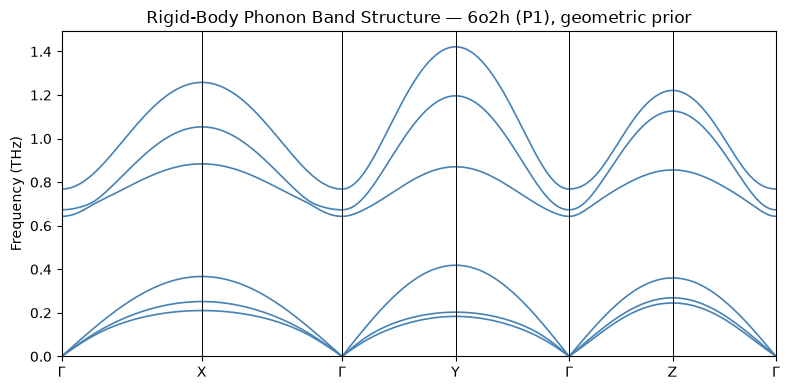

Acoustic branches vanish at Γ as required; librational rest frequencies at Γ: [0.6429 0.673  0.7682] THz


In [13]:
HSP = {'Γ':np.array([0.,0.,0.]),'X':np.array([.5,0.,0.]),
       'Y':np.array([0.,.5,0.]),'Z':np.array([0.,0.,.5])}
path_labels = ['Γ','X','Γ','Y','Γ','Z','Γ']
N_seg = 60

q_frac, tick_idx = [], [0]
for seg in range(len(path_labels)-1):
    p0, p1 = HSP[path_labels[seg]], HSP[path_labels[seg+1]]
    last = (seg == len(path_labels)-2)
    for t in np.linspace(0, 1, N_seg, endpoint=last):
        q_frac.append(p0*(1-t)+p1*t)
    if not last: tick_idx.append(len(q_frac))
tick_idx.append(len(q_frac)-1)

q_frac = np.array(q_frac)
q_cart = (B_recip @ q_frac.T).T
x = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(q_cart,axis=0),axis=1))])

def bandstructure_freqs(K_lab, qs=None):
    """Batched and fully complex. ~50x faster than the per-q Python loop."""
    qs = q_cart if qs is None else qs
    ev = mass_weighted_eigs(dynamical_matrix_batch(qs, unique, K_lab))
    return np.sqrt(np.maximum(ev, 0)) * freq_unit

freqs_bs = bandstructure_freqs(K_LAB_PRIOR)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, freqs_bs, color='steelblue', lw=1.2)
for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0],x[-1]); ax.set_ylim(0)
ax.set_title('Rigid-Body Phonon Band Structure — 6o2h (P1), geometric prior')
plt.tight_layout(); plt.savefig('band_structure.png', dpi=150); plt.show()

print(f"Acoustic branches vanish at Γ as required; librational rest frequencies "
      f"at Γ: {freqs_bs[0][3:].round(4)} THz")

## Diffuse Scattering Maps

$I(\mathbf q) = G^\dagger(\mathbf q)\,D^{-1}(\mathbf q)\,G(\mathbf q)$, with both
$G$ and $D$ complex.

$D(\mathbf q)$ is periodic in the reciprocal lattice, so $D(\mathbf G)=D(\mathbf 0)$
at every Bragg position: the 3 acoustic eigenvalues vanish there, and a
pseudo-inverse keeps $I(\mathbf q)$ finite. Immediately off a Bragg spot the
acoustic branches are linear in $|\delta\mathbf q|$ (their eigenvalues grow as
$|\delta\mathbf q|^2$), producing the $I\sim|\mathbf q-\mathbf G|^{-2}$ halos
visible on the log-scale maps.

Two things modulate halo brightness. It is *not* systematic absences — in $P1$
there are none, and the acoustic branches vanish at **every** reciprocal-lattice
point. It is $|G(\mathbf q)|^2\approx|\mathbf q F(\mathbf q)|^2$: halos are weak
wherever the molecular transform is weak, and grow overall as $|\mathbf q|^2$.

The elliptical boundary of the map comes from the spherical cutoff
$|\mathbf q|<2\pi/d_{\rm min}$ projected onto the $(h,k)$ plane, an ellipse
because $|\mathbf b_1|\neq|\mathbf b_2|$ for a triclinic cell.

Batched vs. single-point I(q): max relative difference 4.263e-13
OK: both intensity paths agree, so the plotted model is the fitted model.
Computing I(h,k,0) at 17228 of 34161 q-points (dh=dk=1/8=0.1250)...


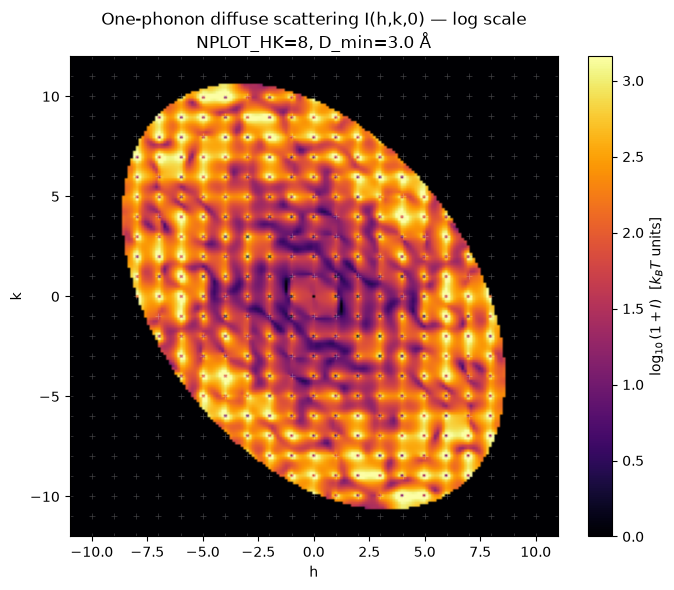

Saved diffuse_map_hk0.png


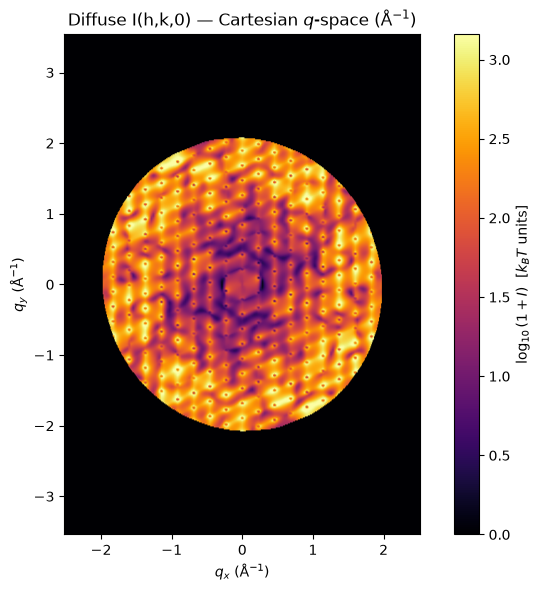

Saved diffuse_map_cart_hk0.png


In [14]:
def diffuse_intensity_batch(K_lab, h_arr, k_arr, l_arr, chunk=None,
                            min_eig_frac=1e-6, G_arr=None):
    """I(q) = G^† D(q)^+ G, vectorized.

    FULL COMPLEX G and D. D is periodic in the reciprocal lattice, so D(G)=D(0)
    at every Bragg position: the 3 acoustic eigenvalues vanish there and a
    pseudo-inverse keeps I finite. Immediately off a Bragg spot the acoustic
    eigenvalues grow as |δq|², producing the I ~ |q-G|^-2 halos.
    """
    chunk = chunk or CHUNK_EVAL
    h_arr = np.asarray(h_arr, float); k_arr = np.asarray(k_arr, float)
    l_arr = np.asarray(l_arr, float)
    N = len(h_arr); I_out = np.zeros(N)
    for s in range(0, N, chunk):
        sl = slice(s, min(s+chunk, N))
        qb = (h_arr[sl,None]*B_recip[:,0] + k_arr[sl,None]*B_recip[:,1]
              + l_arr[sl,None]*B_recip[:,2])
        Db = dynamical_matrix_batch(qb, unique, K_lab)
        Gb = G_arr[sl] if G_arr is not None else G_at_hkl_batch(h_arr[sl], k_arr[sl], l_arr[sl])
        ev, evec = np.linalg.eigh(Db)                      # complex Hermitian
        emax = np.clip(ev.max(axis=1, keepdims=True), 1e-15, None)
        pos = ev > (min_eig_frac*emax)
        ev_inv = np.where(pos, 1.0/np.where(pos, ev, 1.0), 0.0)
        proj = np.einsum('nji,nj->ni', evec.conj(), Gb) * ev_inv
        DinvG = np.einsum('nij,nj->ni', evec, proj)
        I_out[sl] = np.real(np.einsum('ni,ni->n', Gb.conj(), DinvG))
    return I_out

def forward_I(K_lab, h, k, l, G=None):
    """Single-point I(q) by a plain (non-pseudo-inverse) solve -- used where
    D(q) is known to be comfortably invertible, i.e. away from Bragg points."""
    q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
    if G is None:
        G = G_at_hkl(h, k, l)
    D = dynamical_matrix(q, unique, K_lab)
    return float(np.real(np.conj(G) @ np.linalg.solve(D, G)))

# CONSISTENCY CHECK. Two independent code paths evaluate I(q): the refinement
# objective uses forward_I's linear solve, while the maps and the Brillouin-zone
# integral use diffuse_intensity_batch's eigendecomposition with a pseudo-inverse.
# They must agree, or the figures and the predicted ADPs would describe a
# different model from the one being fit. This is a check the synthetic ground
# truth cannot supply, since an error common to both paths would cancel.
_hq = np.array([1.37, -2.13, 0.61, 3.05, -1.44])
_kq = np.array([0.22,  1.81, -2.4, 0.13,  2.77])
_lq = np.array([0.45, -0.33, 1.12, -2.06, 0.88])
_Ia = diffuse_intensity_batch(K_LAB_PRIOR, _hq, _kq, _lq)
_Ib = np.array([forward_I(K_LAB_PRIOR, h, k, l) for h, k, l in zip(_hq, _kq, _lq)])
_rel = np.abs(_Ia - _Ib)/np.maximum(np.abs(_Ib), 1e-30)
print(f"Batched vs. single-point I(q): max relative difference {_rel.max():.3e}")
assert _rel.max() < 1e-8, "the two intensity code paths disagree -- see markdown"
print("OK: both intensity paths agree, so the plotted model is the fitted model.")


P = NPLOT_HK

def compute_diffuse_map(K_lab, L_layer=0):
    """I(h, k, L_layer) on the fine grid (multiples of 1/NPLOT_HK).

    G is evaluated with the separable plane transform, which contracts one grid
    axis at a time instead of forming a dense (n_points x n_voxels) phase
    matrix -- about three orders of magnitude faster, and what makes a
    full-resolution map affordable at all."""
    h_max = int(np.ceil(cell.a/D_MIN_DIFFUSE))+1
    k_max = int(np.ceil(cell.b/D_MIN_DIFFUSE))+1
    q_cut = 2*np.pi/D_MIN_DIFFUSE
    h_pts = np.arange(-h_max*P, h_max*P + 1)/P
    k_pts = np.arange(-k_max*P, k_max*P + 1)/P
    HH, KK = np.meshgrid(h_pts, k_pts, indexing='ij')
    hf, kf = HH.ravel(), KK.ravel()
    lf = np.full_like(hf, float(L_layer))
    q  = hf[:,None]*B_recip[:,0] + kf[:,None]*B_recip[:,1] + lf[:,None]*B_recip[:,2]
    qn = np.linalg.norm(q, axis=1)
    keep = (qn > 1e-3) & (qn < q_cut)
    print(f"Computing I(h,k,{L_layer}) at {keep.sum()} of {len(hf)} q-points "
          f"(dh=dk=1/{P}={1/P:.4f})...")
    G_all = G_plane(h_pts, k_pts, float(L_layer)).reshape(-1, 6)
    I_flat = np.zeros(len(hf))
    I_flat[keep] = diffuse_intensity_batch(K_lab, hf[keep], kf[keep], lf[keep],
                                           G_arr=G_all[keep])
    return h_pts, k_pts, I_flat.reshape(HH.shape), h_max, k_max

def plot_diffuse(h_pts, k_pts, I_map, h_max, k_max, L_layer, fname):
    pos_vals = I_map[I_map > 0]
    if len(pos_vals) == 0:
        print("all I(q) = 0"); return
    vmax = np.percentile(pos_vals, 97)
    I_plot = np.clip(I_map, 0, vmax)
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow((np.log1p(I_plot)/np.log(10)).T, origin='lower', cmap='inferno',
                   extent=[-h_max, h_max, -k_max, k_max], aspect='auto')
    plt.colorbar(im, ax=ax, label=r'$\log_{10}(1+I)$  [$k_BT$ units]')
    ax.set_xlabel('h'); ax.set_ylabel('k')
    ax.set_title(f'One-phonon diffuse scattering I(h,k,{L_layer}) — log scale\n'
                 f'NPLOT_HK={P}, D_min={D_MIN_DIFFUSE} Å')
    for hi in range(-h_max, h_max+1):
        for ki in range(-k_max, k_max+1):
            if hi == 0 and ki == 0: continue
            ax.plot(hi, ki, '+', color='white', alpha=0.25, markersize=4, markeredgewidth=0.5)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()
    print(f"Saved {fname}")

def plot_diffuse_cart(h_pts, k_pts, I_map, L_layer, fname_cart, n_grid=500):
    """Same map in Cartesian q-space (Å⁻¹), for direct comparison with an
    area-detector dataset."""
    H, K = np.meshgrid(h_pts, k_pts, indexing='ij')
    qx_all = H*B_recip[0,0] + K*B_recip[0,1] + L_layer*B_recip[0,2]
    qy_all = H*B_recip[1,0] + K*B_recip[1,1] + L_layer*B_recip[1,2]
    mask = I_map > 0
    qx, qy, I_vals = qx_all[mask], qy_all[mask], I_map[mask]
    if len(I_vals) < 10:
        print("Too few nonzero points for Cartesian map."); return
    vmax  = np.percentile(I_vals, 97)
    I_log = np.log1p(np.clip(I_vals, 0, vmax))/np.log(10)
    qx_lin = np.linspace(qx_all.min(), qx_all.max(), n_grid)
    qy_lin = np.linspace(qy_all.min(), qy_all.max(), n_grid)
    QX, QY = np.meshgrid(qx_lin, qy_lin)
    I_cart = griddata((qx, qy), I_log, (QX, QY), method='linear', fill_value=0.0)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(I_cart, origin='lower', cmap='inferno',
                   extent=[qx_lin[0], qx_lin[-1], qy_lin[0], qy_lin[-1]], aspect='equal')
    plt.colorbar(im, ax=ax, label=r'$\log_{10}(1+I)$  [$k_BT$ units]')
    ax.set_xlabel(r'$q_x$ (Å$^{-1}$)'); ax.set_ylabel(r'$q_y$ (Å$^{-1}$)')
    ax.set_title(f'Diffuse I(h,k,{L_layer}) — Cartesian $q$-space (Å$^{{-1}}$)')
    plt.tight_layout(); plt.savefig(fname_cart, dpi=150); plt.show()
    print(f"Saved {fname_cart}")

h_pts0, k_pts0, I_map0, h_max0, k_max0 = compute_diffuse_map(K_LAB_PRIOR, L_layer=0)
plot_diffuse(h_pts0, k_pts0, I_map0, h_max0, k_max0, 0, 'diffuse_map_hk0.png')
plot_diffuse_cart(h_pts0, k_pts0, I_map0, 0, 'diffuse_map_cart_hk0.png')

Computing I(h,k,0.5) at 17196 of 34161 q-points (dh=dk=1/8=0.1250)...


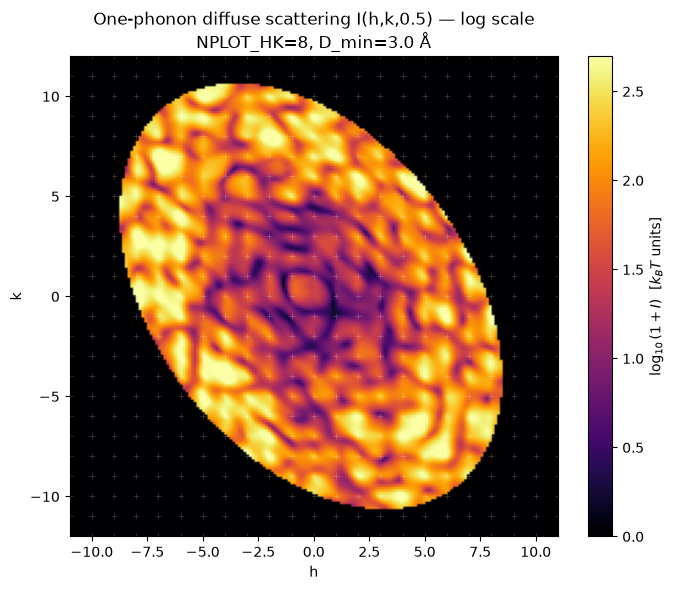

Saved diffuse_map_hk05.png


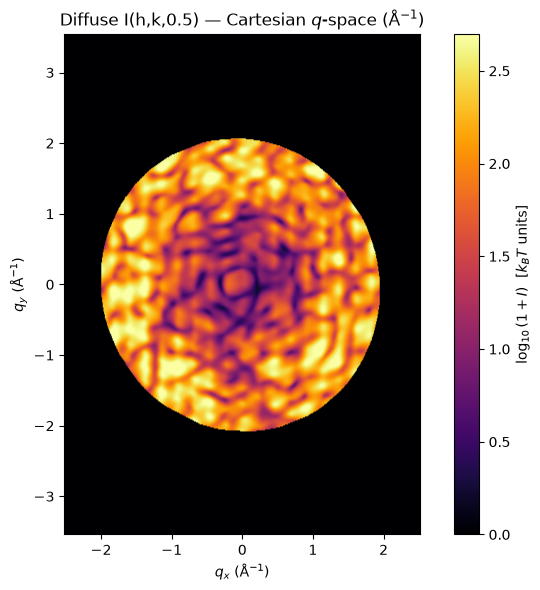

Saved diffuse_map_cart_hk05.png


In [15]:
h_pts5, k_pts5, I_map5, h_max5, k_max5 = compute_diffuse_map(K_LAB_PRIOR, L_layer=0.5)
plot_diffuse(h_pts5, k_pts5, I_map5, h_max5, k_max5, 0.5, 'diffuse_map_hk05.png')
plot_diffuse_cart(h_pts5, k_pts5, I_map5, 0.5, 'diffuse_map_cart_hk05.png')

## Synthetic Data

The "true" stiffness is the geometric prior perturbed by a random multiplicative
distortion of its Cholesky factor. Since the prior is also the refinement's
starting point, drawing the ground truth this way asks whether the data can move
the fit a realistic distance in a realistic direction, rather than whether it can
recover a target chosen for convenience.

Diffuse intensities are evaluated at a stratified set of $(h,k,l)$ points: a
near-Bragg subset, dominated by the acoustic branches and sensitive to the
long-wavelength elastic limit, and a larger mid-zone subset sensitive to the
individual contact stiffnesses. Bragg positions themselves are excluded.
Independent Gaussian noise with a Poisson-like $\sigma\propto\sqrt I$ and a floor
is added, and 15% of the points are held out for cross-validation.

In [16]:
def true_Lmap(seed=0, distortion=0.35):
    """Ground truth = geometric prior × a random Cholesky-space distortion."""
    rng = np.random.default_rng(seed)
    Lmap = {}
    for c in shell_order:
        L0 = L_PRIOR[c]
        D_pert = np.tril(distortion*rng.standard_normal((6,6)))
        np.fill_diagonal(D_pert, 1.0 + distortion*rng.standard_normal(6))
        Lmap[c] = L0 @ D_pert
    return Lmap

L_TRUE = true_Lmap(seed=0)
K_LOCAL_TRUE, K_LAB_TRUE = build_K(L_TRUE)
print("True local-frame stiffness eigenvalues per contact (all > 0 required):")
for c in shell_order:
    ev_t = np.linalg.eigvalsh(K_LOCAL_TRUE[c])
    ev_p = np.linalg.eigvalsh(K_PRIOR_LOCAL[c])
    print(f"  {str(c):14s} true {ev_t.round(2)}")
    print(f"  {'':14s} prior{ev_p.round(2)}")
assert all(np.linalg.eigvalsh(K_LOCAL_TRUE[c]).min() > 0 for c in shell_order)

print("\n(The mean B implied by this true K is reported in the ADP section below,\n once bz_covariance is defined.)")

True local-frame stiffness eigenvalues per contact (all > 0 required):
  (-1, -1, 0)    true [   9.83   70.26   85.9   137.92 1109.09 2343.08]
                 prior[  33.47   33.47   33.47  249.2  1135.19 1341.71]
  (-1, 0, -1)    true [   2.13   11.09   28.34  160.07  709.68 2019.04]
                 prior[ 16.25  16.25  16.25 145.08 581.12 715.66]
  (-1, 0, 0)     true [   6.73   16.36   35.85  553.79 3554.6  4855.61]
                 prior[  32.13   32.13   32.13  324.01 3046.81 3297.03]
  (0, -1, 0)     true [   8.08   60.56  124.46  631.7  1660.05 7903.78]
                 prior[  64.     64.     64.    967.7  1982.1  2853.31]
  (0, -1, 1)     true [  0.86   6.71   8.97  25.35 114.5  185.06]
                 prior[  5.8    9.04   9.04   9.04 103.44 107.3 ]
  (0, 0, -1)     true [  14.92   30.78  110.55  472.06 1360.   5092.93]
                 prior[  53.64   53.64   53.64  616.1  1247.83 1809.52]

(The mean B implied by this true K is reported in the ADP section below,
 once bz_

In [17]:
def sample_q_points(n_near=60, n_mid=240, seed=1):
    rng = np.random.default_rng(seed)
    q_cut = 2*np.pi/D_MIN_DIFFUSE
    h_max = int(np.ceil(cell.a/D_MIN_DIFFUSE))+1
    k_max = int(np.ceil(cell.b/D_MIN_DIFFUSE))+1

    def snap(h, k):
        return round(h*P)/P, round(k*P)/P

    pts = []
    bragg_centers = [(h0,k0) for h0 in range(-3,4) for k0 in range(-3,4) if (h0,k0)!=(0,0)]
    rng.shuffle(bragg_centers)
    for (h0,k0) in bragg_centers:
        if len(pts) >= n_near: break
        for r in (0.06, 0.12, 0.2):
            ang = rng.uniform(0, 2*np.pi)
            h, k = snap(h0 + r*np.cos(ang), k0 + r*np.sin(ang))
            for l in (0.0, 0.5):
                q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
                if 1e-3 < np.linalg.norm(q) < q_cut:
                    pts.append((h,k,l))
    pts = pts[:n_near]

    count = 0
    while count < n_mid:
        h, k = snap(rng.uniform(-h_max, h_max), rng.uniform(-k_max, k_max))
        l = rng.choice([0.0, 0.5])
        q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
        qn = np.linalg.norm(q)
        if qn < 1e-3 or qn > q_cut: continue
        if min(abs(h-round(h)), abs(k-round(k))) < 0.05: continue   # skip near-Bragg
        pts.append((h,k,l)); count += 1
    return np.array(pts)

def well_conditioned_batch(K_lab, hkl, min_eig_frac=1e-4):
    """D(q) is exactly singular only at reciprocal-lattice points, but a point
    can still land near a degenerate direction, where the plain solve used by
    the objective is ill-conditioned. Screened at the TRUE K (i.e. at the
    operating point), and vectorized."""
    q = (hkl[:,0:1]*B_recip[:,0] + hkl[:,1:2]*B_recip[:,1] + hkl[:,2:3]*B_recip[:,2])
    ev = np.linalg.eigvalsh(dynamical_matrix_batch(q, unique, K_lab))
    emax, emin = ev[:,-1], ev[:,0]
    return (emax > 0) & (emin/np.where(emax > 0, emax, 1.0) > min_eig_frac)

q_all_raw = sample_q_points()
keep_mask = well_conditioned_batch(K_LAB_TRUE, q_all_raw)
q_all = q_all_raw[keep_mask]
print(f"{len(q_all)}/{len(q_all_raw)} sampled points kept after the conditioning "
      f"screen ({len(q_all_raw)-len(q_all)} discarded)")

G_all = G_at_hkl_batch(q_all[:,0], q_all[:,1], q_all[:,2])
I_true_all = diffuse_intensity_batch(K_LAB_TRUE, q_all[:,0], q_all[:,1], q_all[:,2],
                                     G_arr=G_all)

rng = np.random.default_rng(7)
NOISE_FLOOR = 0.02*np.median(I_true_all)
NOISE_SCALE = 0.06
sigma_all = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(I_true_all, 0, None))
I_obs_all = I_true_all + rng.normal(0, sigma_all)

train_mask = rng.random(len(q_all)) > 0.15
q_train, G_train, I_train, sigma_train = (q_all[train_mask], G_all[train_mask],
                                          I_obs_all[train_mask], sigma_all[train_mask])
q_test,  G_test,  I_test,  sigma_test  = (q_all[~train_mask], G_all[~train_mask],
                                          I_obs_all[~train_mask], sigma_all[~train_mask])
w_train = 1.0/sigma_train**2

def effective_sample_size(w):
    """ESS = (Σw)²/Σw². Reported alongside the nominal count everywhere, because
    a nominal N means nothing once the weights are heterogeneous."""
    w = np.asarray(w, float)
    return w.sum()**2/np.sum(w**2)

print(f"{len(q_all)} q-points: {train_mask.sum()} training "
      f"(effective {effective_sample_size(w_train):.0f}), "
      f"{(~train_mask).sum()} held out for R_free")
print(f"{(I_obs_all < 0).mean():.1%} of synthetic observations are negative")

280/300 sampled points kept after the conditioning screen (20 discarded)
280 q-points: 246 training (effective 221), 34 held out for R_free
0.7% of synthetic observations are negative


## Where the Fitted q-Points Sit

The sampled points span two Miller-index layers ($l=0$ and $l=0.5$), so they
are not coplanar in $\mathbf q$-space; the left panel shows all of them in
true Cartesian $\mathbf q$ (Å$^{-1}$), and the two right panels show each
layer separately, overlaid on that layer's true diffuse map, so the
near-Bragg and mid-zone sampling is visible relative to the halos.


Computing I(h,k,0.0) at 17228 of 34161 q-points (dh=dk=1/8=0.1250)...
Computing I(h,k,0.5) at 17196 of 34161 q-points (dh=dk=1/8=0.1250)...


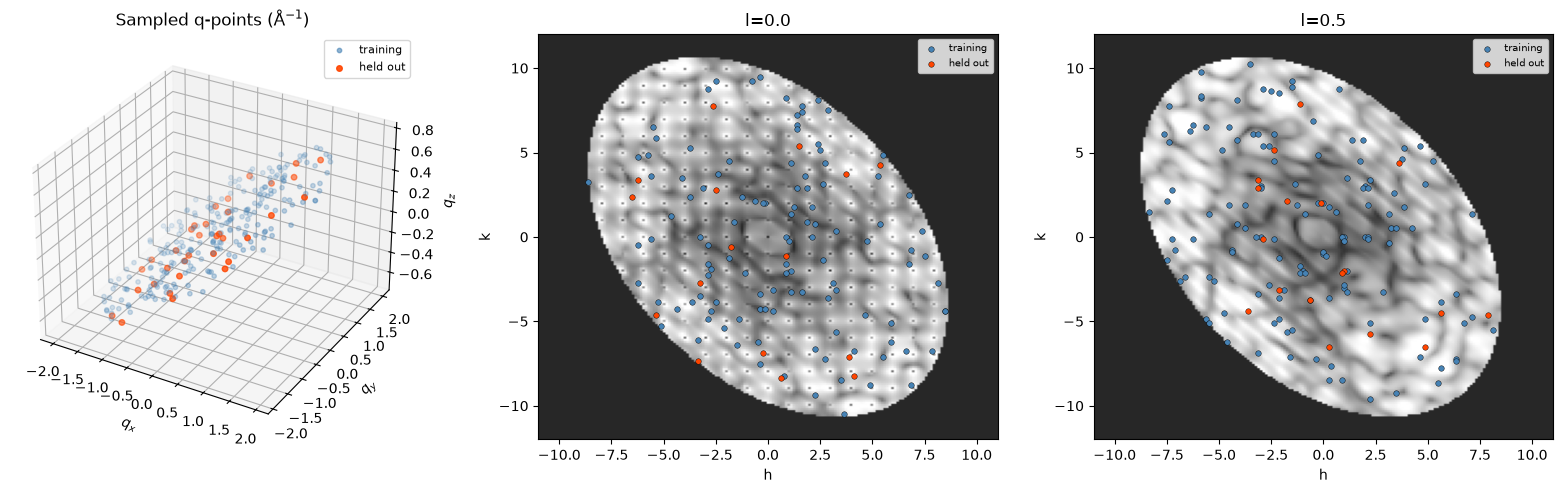

129 points at l=0, 151 points at l=0.5


In [18]:
h_pts_bg0,  k_pts_bg0,  I_bg0,  h_max_bg0,  k_max_bg0  = compute_diffuse_map(K_LAB_TRUE, L_layer=0.0)
h_pts_bg05, k_pts_bg05, I_bg05, h_max_bg05, k_max_bg05 = compute_diffuse_map(K_LAB_TRUE, L_layer=0.5)

def q_cart_of(pts):
    return (pts[:,0:1]*B_recip[:,0] + pts[:,1:2]*B_recip[:,1] + pts[:,2:3]*B_recip[:,2])

qc_train, qc_test = q_cart_of(q_train), q_cart_of(q_test)

fig = plt.figure(figsize=(16, 5))
ax3d = fig.add_subplot(1, 3, 1, projection='3d')
ax3d.scatter(*qc_train.T, s=10, alpha=0.6, color='steelblue', label='training')
ax3d.scatter(*qc_test.T,  s=16, alpha=0.9, color='orangered', label='held out')
ax3d.set_xlabel('$q_x$'); ax3d.set_ylabel('$q_y$'); ax3d.set_zlabel('$q_z$')
ax3d.set_title('Sampled q-points (Å$^{-1}$)'); ax3d.legend(fontsize=8)

def overlay_panel(ax, h_pts, k_pts, I_bg, h_max, k_max, l_layer):
    pos = I_bg[I_bg > 0]
    vmax = np.percentile(pos, 97) if len(pos) else 1.0
    ax.imshow((np.log1p(np.clip(I_bg, 0, vmax))/np.log(10)).T, origin='lower', cmap='gray',
              extent=[-h_max, h_max, -k_max, k_max], aspect='auto', alpha=0.85)
    for pts, color, label in [(q_train, 'steelblue', 'training'), (q_test, 'orangered', 'held out')]:
        sel = np.abs(pts[:,2] - l_layer) < 1e-6
        ax.scatter(pts[sel,0], pts[sel,1], s=16, color=color, edgecolor='k',
                   linewidth=0.3, label=label)
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(f'l={l_layer}')
    ax.legend(fontsize=7, loc='upper right')

overlay_panel(fig.add_subplot(1,3,2), h_pts_bg0,  k_pts_bg0,  I_bg0,  h_max_bg0,  k_max_bg0,  0.0)
overlay_panel(fig.add_subplot(1,3,3), h_pts_bg05, k_pts_bg05, I_bg05, h_max_bg05, k_max_bg05, 0.5)

plt.tight_layout(); plt.savefig('sampled_q_points.png', dpi=150); plt.show()
print(f"{(q_all[:,2]==0.0).sum()} points at l=0, {(q_all[:,2]==0.5).sum()} points at l=0.5")

## Refining $K$ to the Synthetic Data

$$\mathcal L(\theta)=\sum_{\mathbf q\in\rm train}w(\mathbf q)
\bigl[I_{\rm obs}(\mathbf q)-I_{\rm model}(\mathbf q;\theta)\bigr]^2
+\lambda\sum_{\mathbf n}
\bigl\|\log\bigl(K_{\mathbf n,\rm prior}^{-1/2}K_{\mathbf n}
K_{\mathbf n,\rm prior}^{-1/2}\bigr)\bigr\|_F^2$$

with $w=1/\sigma^2$ and the second term the geodesic distance to the geometric
prior described above, summed over the 6 contacts. Because that distance is
invariant under $K\to TKT^{\mathsf T}$, it is the same whether evaluated on the
local-frame or the lab-frame stiffnesses.

**Order of operations.** `LAMBDA_PRIOR` is selected by cross-validation *before*
the main refinement, and everything downstream — the fitted $K$, the distance
diagnostics, the Gauss-Newton spectrum, the predicted ADPs — uses the selected
value. The default in the parameters cell only seeds the scan.

**Gradient.** $I=G^\dagger D^{-1}G$ and $d(D^{-1})=-D^{-1}dD\,D^{-1}$, so
$dI=-v^\dagger dD\,v$ with $v=D^{-1}G$. $D$ is linear in each $K_{\mathbf n}$, so
$dD$ is a known linear function of $dK_{\mathbf n}$ and $dI/dK_{\mathbf n}$ is
closed-form at essentially no cost beyond the forward evaluation. The regularizer
contributes $2\lambda\,K_{\rm prior}^{-1/2}\bigl(P^{-1}\log P\bigr)
K_{\rm prior}^{-1/2}$ with $P=K_{\rm prior}^{-1/2}KK_{\rm prior}^{-1/2}$. Both are
chained through the fixed lab-frame transform and $K=LL^{\mathsf T}$ to give
$d\mathcal L/dL$, checked below against finite differences.

**Optimizer.** L-BFGS-B with the analytic gradient, unconstrained: the Cholesky
parameterization makes every point in parameter space a valid model. The loss is
vectorized over the whole point batch.

**Two convergence questions, two tests.** *Is the fit converged?* Once the loss
stops improving by more than about one $\chi^2$ unit there is nothing left to
learn — the noise on $\chi^2$ itself is $\sqrt{2\,\mathrm{dof}}$, so smaller
changes cannot alter any statement about the model. That trailing-window test is
the stopping rule. *Is $K$ converged?* Not the same question: along a flat
direction the loss barely changes while $K$ travels a long way, so both the
projected gradient and the loss can look settled while the stiffnesses are still
in motion.

The refinement therefore runs L-BFGS-B in warm-started segments and reports both
per segment: the loss, split into data and penalty so it is comparable across
$\lambda$, and the **geodesic step** — how far $K$ moved, in the same metric the
regularizer uses, where 0.01 is a 1% change in one stiffness eigenvalue of one
contact.

When the loss criterion fires while the geodesic step is still large, the fit is
statistically converged but $K$ is not: the reported stiffnesses are one point in
a nearly flat region rather than a point estimate. The notebook says so
explicitly. That region is what the prior and the sloppiness spectrum describe,
and a larger `LAMBDA_PRIOR` shrinks it — which the scan below settles on held-out
data.

In [19]:
def loss_and_grad(theta, q_list, G_list, I_obs, weights):
    """Vectorized over the whole point batch. G_list is precomputed once: it
    depends only on the structure and q, never on theta, so recomputing it inside
    a function L-BFGS-B calls every iteration would repeat the same sums
    hundreds of times."""
    Lmap = theta_to_Lmap(theta)
    K_local, K_lab = build_K(Lmap)
    N_mat = {c: Gc_inv_matrix(unique[c]['c_local']) @ unique[c]['Gamma'].T
             for c in shell_order}

    q_list = np.asarray(q_list, float); G_arr = np.asarray(G_list)
    q_batch = (q_list[:,0:1]*B_recip[:,0] + q_list[:,1:2]*B_recip[:,1]
               + q_list[:,2:3]*B_recip[:,2])
    D_batch = dynamical_matrix_batch(q_batch, unique, K_lab)
    # solve needs an explicit trailing RHS axis to batch over N systems
    V = np.linalg.solve(D_batch, G_arr[:,:,None])[:,:,0]
    Imodel = np.real(np.sum(np.conj(G_arr)*V, axis=1))
    resid = Imodel - np.asarray(I_obs)
    weights = np.asarray(weights)
    data_loss = float(np.sum(weights*resid**2))
    coeff = 2.0*weights*resid

    grad_L = {}
    for c in shell_order:
        R_n = unique[c]['R_n']
        A_n = ad_translation(R_n)
        phase = np.exp(1j*(q_batch @ R_n))
        U  = V @ A_n.T
        w1 = U - phase[:,None]*V
        w2 = V - phase.conj()[:,None]*U
        Graw = -(np.einsum('ni,nj->nij', U.conj(), w1) + np.einsum('ni,nj->nij', V.conj(), w2))
        G_A  = np.einsum('ij,njk,lk->nil', N_mat[c], Graw, N_mat[c])
        dL_c = np.real(np.einsum('nij,jk->nik', G_A + G_A.transpose(0,2,1), Lmap[c]))
        grad_L[c] = np.einsum('n,nij->ij', coeff, dL_c)

    reg  = regularizer_prior(K_local)
    dRdK = regularizer_prior_dK(K_local)
    for c in shell_order:
        grad_L[c] += (dRdK[c] + dRdK[c].T) @ Lmap[c]
        grad_L[c] = np.tril(grad_L[c])

    return data_loss + reg, Lmap_to_theta(grad_L)

In [20]:
# Gradient check: analytic vs. central finite differences along random directions.
rng_chk = np.random.default_rng(42)
theta_chk = Lmap_to_theta(L_PRIOR)*(1 + 0.05*rng_chk.standard_normal(N_PARAMS))
n_chk = min(15, len(q_train))
q_chk, G_chk, I_chk, w_chk = q_train[:n_chk], G_train[:n_chk], I_train[:n_chk], w_train[:n_chk]

loss0, grad0 = loss_and_grad(theta_chk, q_chk, G_chk, I_chk, w_chk)
eps, errs = 1e-6, []
for idx in rng_chk.choice(N_PARAMS, size=8, replace=False):
    tp = theta_chk.copy(); tp[idx] += eps
    tm = theta_chk.copy(); tm[idx] -= eps
    fd = (loss_and_grad(tp, q_chk, G_chk, I_chk, w_chk)[0]
          - loss_and_grad(tm, q_chk, G_chk, I_chk, w_chk)[0])/(2*eps)
    errs.append(abs(fd - grad0[idx])/max(abs(fd), 1e-6))
print(f"Gradient check, max relative error over 8 random directions: {max(errs):.2e}")
assert max(errs) < 1e-4

Gradient check, max relative error over 8 random directions: 6.28e-05


In [21]:
# --- Convergence criteria --------------------------------------------------
# Two different questions, and they need two different tests.
#
#   Is the FIT converged?  Statistically, once the loss stops improving by more
#   than about one chi-squared unit there is nothing left to learn: the noise on
#   chi-squared itself is sqrt(2*dof), so smaller changes cannot alter any
#   statement about the model. This is the stopping rule.
#
#   Is K converged?  Not the same thing. Along a flat direction the loss barely
#   moves while K travels a long way, so the projected gradient -- and the loss
#   itself -- can look settled while the stiffnesses are still in motion. The
#   geodesic step measures that directly, in the same metric the regularizer
#   uses: a step of 0.01 is a 1% change in one stiffness eigenvalue of one
#   contact. It is reported every segment and is the diagnostic that says whether
#   the reported K is a point estimate or one point in a flat region.

def geodesic_step(theta_a, theta_b):
    """Largest geodesic distance any single contact's K moved between two
    iterates. exp(d) is the factor along the worst-affected direction."""
    Ka, _ = build_K(theta_to_Lmap(theta_a))
    Kb, _ = build_K(theta_to_Lmap(theta_b))
    worst = 0.0
    for c in shell_order:
        Minv = _sqrtm_inv_sym(Ka[c])
        P = Minv @ Kb[c] @ Minv
        w = np.linalg.eigvalsh(0.5*(P + P.T))
        w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
        worst = max(worst, float(np.sqrt(np.sum(np.log(w)**2))))
    return worst

BLOCK     = 500     # iterations per segment
MAX_BLOCK = 80      # segments
LOSS_TOL  = 1.0     # stop when the loss improves by less than this (chi-squared
LOSS_WIN  = 5       # units) over LOSS_WIN consecutive segments
GEO_TOL   = 1e-2    # also stop if K itself stops moving this much per segment

def refine(theta_start, args, block=BLOCK, max_block=MAX_BLOCK,
           loss_tol=LOSS_TOL, loss_win=LOSS_WIN, geo_tol=GEO_TOL, verbose=True):
    """L-BFGS-B in warm-started segments, stopping on the trailing-window loss
    improvement, with the geodesic step reported alongside as a diagnostic.

    Segments rather than one call so both quantities can be measured between
    them; ftol and gtol are zero within a segment so it always runs its full
    block. L-BFGS-B rebuilds its curvature estimate each segment, which costs a
    few percent of the iterations.
    """
    theta = np.asarray(theta_start, float).copy()
    hist  = [theta.copy()]
    nit = nfev = 0
    rows, why = [], "max_block"
    if verbose:
        print(f"   {'seg':>3s} {'iters':>7s} {'data loss':>12s} {'penalty':>9s} "
              f"{'K moved':>10s}")
    for b in range(max_block):
        res = minimize(loss_and_grad, theta, args=args, jac=True, method='L-BFGS-B',
                       options={'maxiter': block, 'maxfun': 4*block,
                                'ftol': 0.0, 'gtol': 0.0},
                       callback=lambda xk: hist.append(xk.copy()))
        step = geodesic_step(theta, res.x)
        theta = res.x; nit += res.nit; nfev += res.nfev
        K_local, _ = build_K(theta_to_Lmap(theta))
        pen = regularizer_prior(K_local)
        rows.append((nit, res.fun, res.fun - pen, pen, step))
        if verbose:
            print(f"   {b+1:3d} {nit:7d} {res.fun-pen:12.6g} {pen:9.4f} {step:10.3e}")
        if step < geo_tol:
            why = "geodesic"; break
        if len(rows) > loss_win and (rows[-1-loss_win][1] - rows[-1][1]) < loss_tol:
            why = "loss"; break
    return theta, hist, nit, nfev, rows, why


In [22]:
# --- Helpers used by the selection scan and by the analysis below ----------

def fit_stats(K_lab, q_list, G_list, I_list):
    """R-factor and linear correlation coefficient.

    R alone is a poor summary once observations can be negative: the denominator
    is inflated by the magnitude of negatives, and R -> 1 is also what a model
    predicting ~0 produces. CC separates those cases, so both are reported.
    """
    Imodel = diffuse_intensity_batch(K_lab, q_list[:,0], q_list[:,1], q_list[:,2],
                                     G_arr=np.asarray(G_list))
    R  = np.sum(np.abs(Imodel - I_list))/np.sum(np.abs(I_list))
    CC = np.corrcoef(Imodel, I_list)[0,1]
    return R, CC, Imodel

def geodesic_per_contact(theta_a, theta_b):
    """Geodesic distance between two parameter vectors, per contact."""
    Ka, _ = build_K(theta_to_Lmap(theta_a))
    Kb, _ = build_K(theta_to_Lmap(theta_b))
    out = {}
    for c in shell_order:
        Minv = _sqrtm_inv_sym(Ka[c])
        P = Minv @ Kb[c] @ Minv
        w = np.linalg.eigvalsh(0.5*(P + P.T))
        w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
        out[c] = float(np.sqrt(np.sum(np.log(w)**2)))
    return out

THETA_PRIOR = Lmap_to_theta(L_PRIOR)
theta_true  = Lmap_to_theta(L_TRUE)
D_PRIOR_TRUTH = geodesic_per_contact(THETA_PRIOR, theta_true)
REF_PT = max(D_PRIOR_TRUTH.values())

print("Geodesic distance from the prior to the ground truth, per contact:")
for c in shell_order:
    print(f"   {str(c):14s} {D_PRIOR_TRUTH[c]:6.3f}")
print(f"   {'worst':14s} {REF_PT:6.3f}")
print()
print("This is the reference every truth→fit number has to be read against. A fit")
print("that does not get below it has not improved on the starting guess, however")
print("well it reproduces the intensities.")


Geodesic distance from the prior to the ground truth, per contact:
   (-1, -1, 0)     2.441
   (-1, 0, -1)     3.364
   (-1, 0, 0)      2.445
   (0, -1, 0)      2.959
   (0, -1, 1)      2.592
   (0, 0, -1)      2.766
   worst           3.364

This is the reference every truth→fit number has to be read against. A fit
that does not get below it has not improved on the starting guess, however
well it reproduces the intensities.


### Selecting `LAMBDA_PRIOR`

The regularizer weight decides whether the poorly-determined directions have a
restoring force at all. Too small and the optimizer slides along them
indefinitely; too large and the penalty overrides the stiff directions the data
does determine. It is selected **before** the main refinement, and everything
downstream — the fitted $K$, the sloppiness spectrum, the ADP prediction — then
uses the selected value.

Selection is by **$k$-fold cross-validation on $R$**, which uses no ground truth
and so transfers unchanged to the experimental notebook. Cross-validation rather
than a single held-out split because with a 15% holdout only a few dozen points
carry the estimate, and the resulting noise on $R$ is comparable to the variation
across $\lambda$ — enough to make the minimum unresolvable. $k$-fold uses every
point for testing exactly once.

The scan reports, per $\lambda$: $\chi^2/\mathrm{dof}$, the cross-validated $R$
and $CC$ with their fold-to-fold spread, the geodesic distances prior→fit and
truth→fit, the iteration count, and the final geodesic step. The last shows
directly whether the problem has become well-posed; `truth→fit` is a check
available only here, and is *not* used for selection.

2-fold cross-validation over 280 points  (prior→truth = 3.364)

  lambda  chi2/dof     R_cv       ±     CC_cv  prior→fit  truth→fit   iters  last step
      10    1.5621   0.0200  0.0037   0.99969      1.916      3.239    4000   2.01e-02
       3    1.3418   0.0187  0.0019   0.99975      2.170      3.134    3500   4.52e-02
       1    1.2521   0.0180  0.0008   0.99978      2.430      3.219    3500   6.60e-02
     0.3    1.1900   0.0183  0.0005   0.99977      2.738      3.748    3500   2.73e-01
     0.1    1.1333   0.0193  0.0015   0.99972      3.702      4.562    7000   3.21e-01
    0.03    1.1156   0.0212  0.0002   0.99965      4.544      5.089    3000   6.49e-01
    0.01    1.1071   0.0209  0.0004   0.99967      5.576      6.224    3000   5.41e-01

best R_cv = 0.0180 at lambda = 1  (standard error 0.0005)
one-standard-error rule -> LAMBDA_PRIOR = 1
   at that value: χ²/dof 1.2521, prior→fit 2.430, truth→fit 3.219  (prior→truth 3.364)


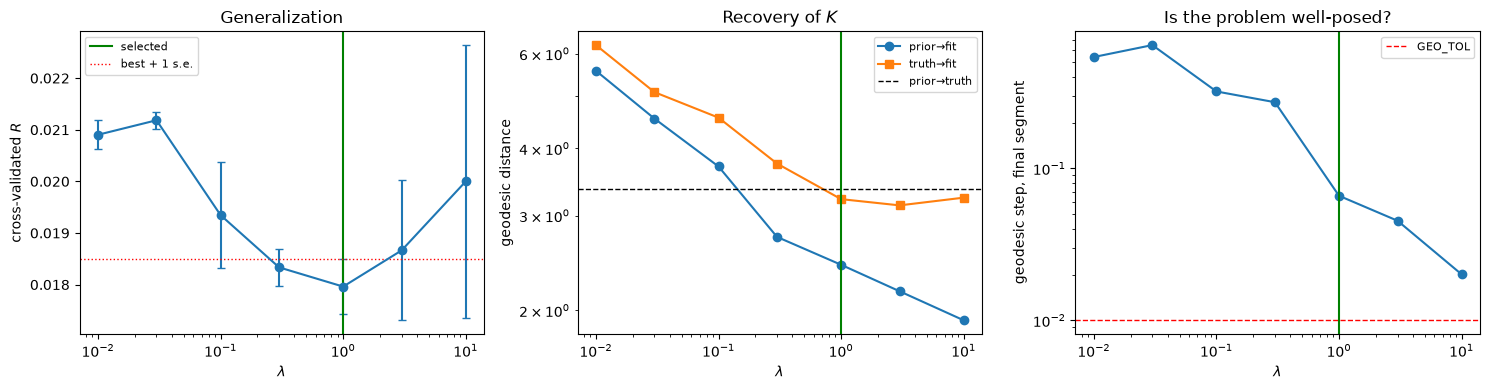

In [23]:
# --- Cross-validated selection of LAMBDA_PRIOR -----------------------------
LAMBDA_SCAN = [1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0]
N_FOLDS     = 2        # 1 reproduces a single held-out split; raise for a
                       # tighter estimate at proportionally more compute
SCAN_BLOCKS = 30       # segment cap per fit during the scan

# The scan rebinds the module-level LAMBDA_PRIOR, which only works because
# regularizer_prior looks it up at call time rather than binding it as a default
# argument. Verify that here rather than discovering it from identical rows.
_saved_lambda = LAMBDA_PRIOR
_probe = {shell_order[0]: 1.05*K_PRIOR_LOCAL[shell_order[0]]}
LAMBDA_PRIOR = 1.0;  _p1 = regularizer_prior(_probe)
LAMBDA_PRIOR = 10.0; _p2 = regularizer_prior(_probe)
LAMBDA_PRIOR = _saved_lambda
assert abs(_p2/_p1 - 10.0) < 1e-9, \
    "regularizer_prior is not picking up LAMBDA_PRIOR at call time"

_rng_cv = np.random.default_rng(11)
_perm   = _rng_cv.permutation(len(q_all))
_fold   = np.array_split(_perm, max(N_FOLDS, 1))

# Warm-started along the lambda path, walked from LARGE to SMALL. Heavily
# regularized fits sit near the prior; relaxing lambda lets the fit move outward
# in steps, so each start is close to its target.
_WARM = {'theta': None}

def cv_score(lam):
    """Cross-validated R and CC, plus the fit on all data at this lambda."""
    global LAMBDA_PRIOR
    LAMBDA_PRIOR = lam
    _start = _WARM['theta'] if _WARM['theta'] is not None else THETA_PRIOR
    Rs, CCs = [], []
    if N_FOLDS > 1:
        for f in _fold:
            te = np.zeros(len(q_all), bool); te[f] = True
            th, _, _, _, _, _ = refine(_start,
                                       (q_all[~te], G_all[~te], I_obs_all[~te],
                                        1.0/sigma_all[~te]**2),
                                       max_block=SCAN_BLOCKS, verbose=False)
            _, Kl = build_K(theta_to_Lmap(th))
            R, CC, _ = fit_stats(Kl, q_all[te], G_all[te], I_obs_all[te])
            Rs.append(R); CCs.append(CC)
    th, _, nit, _, rw, _ = refine(_start, (q_train, G_train, I_train, w_train),
                                  max_block=SCAN_BLOCKS, verbose=False)
    _WARM['theta'] = th
    _, Kl = build_K(theta_to_Lmap(th))
    if N_FOLDS <= 1:
        R, CC, _ = fit_stats(Kl, q_test, G_test, I_test)
        Rs, CCs = [R], [CC]
    Im   = np.array([forward_I(Kl, *q, G=G) for q, G in zip(q_train, G_train)])
    chi2 = float(np.sum(w_train*(Im - I_train)**2)/max(len(q_train)-N_PARAMS, 1))
    return (np.mean(Rs), np.std(Rs), np.mean(CCs), chi2,
            max(geodesic_per_contact(THETA_PRIOR, th).values()),
            max(geodesic_per_contact(theta_true, th).values()),
            nit, rw[-1][4])

print(f"{N_FOLDS}-fold cross-validation over {len(q_all)} points  "
      f"(prior→truth = {REF_PT:.3f})\n")
print(f"{'lambda':>8s} {'chi2/dof':>9s} {'R_cv':>8s} {'±':>7s} {'CC_cv':>9s} "
      f"{'prior→fit':>10s} {'truth→fit':>10s} {'iters':>7s} {'last step':>10s}")
_scan = []
for _lam in sorted(LAMBDA_SCAN, reverse=True):
    r = cv_score(_lam)
    _scan.append((_lam,) + r)
    print(f"{_lam:8.3g} {r[3]:9.4f} {r[0]:8.4f} {r[1]:7.4f} {r[2]:9.5f} "
          f"{r[4]:10.3f} {r[5]:10.3f} {r[6]:7d} {r[7]:10.2e}")
LAMBDA_PRIOR = _saved_lambda
_scan.sort(key=lambda row: row[0])   # back to ascending lambda for plotting

# --- Automatic selection ---------------------------------------------------
# One-standard-error rule: among the values whose cross-validated R is within one
# fold-to-fold standard error of the best, take the LARGEST lambda. The R curve
# is shallow compared with its own noise, so picking the bare minimum would be
# fitting the fold split; the larger lambda is the more conservative model and
# also the better-posed optimization.
_Rs   = np.array([r[1] for r in _scan])
_ses  = np.array([r[2] for r in _scan])/max(np.sqrt(N_FOLDS), 1.0)
_i    = int(np.argmin(_Rs))
_thr  = _Rs[_i] + _ses[_i]
LAMBDA_PRIOR = float(max(r[0] for r in _scan if r[1] <= _thr))

print(f"\nbest R_cv = {_Rs[_i]:.4f} at lambda = {_scan[_i][0]:g}  "
      f"(standard error {_ses[_i]:.4f})")
print(f"one-standard-error rule -> LAMBDA_PRIOR = {LAMBDA_PRIOR:g}")
_sel = [r for r in _scan if r[0] == LAMBDA_PRIOR][0]
print(f"   at that value: χ²/dof {_sel[4]:.4f}, prior→fit {_sel[5]:.3f}, "
      f"truth→fit {_sel[6]:.3f}  (prior→truth {REF_PT:.3f})")
if _sel[6] >= REF_PT:
    print("\n   truth→fit is NOT below prior→truth: at this lambda the refined K is")
    print("   no closer to the truth than the starting guess, even though the")
    print("   intensities are reproduced well. The data constrains I(q), not K.")

_fig, _ax = plt.subplots(1, 3, figsize=(15, 4))
_l = [r[0] for r in _scan]
_ax[0].errorbar(_l, _Rs, yerr=_ses, fmt='o-', capsize=3)
_ax[0].axvline(LAMBDA_PRIOR, color='g', ls='-', lw=1.5, label='selected')
_ax[0].axhline(_thr, color='r', ls=':', lw=1, label='best + 1 s.e.')
_ax[0].set_xscale('log'); _ax[0].set_xlabel(r'$\lambda$')
_ax[0].set_ylabel('cross-validated $R$'); _ax[0].set_title('Generalization')
_ax[0].legend(fontsize=8)
_ax[1].loglog(_l, [r[5] for r in _scan], 'o-', label='prior→fit')
_ax[1].loglog(_l, [r[6] for r in _scan], 's-', label='truth→fit')
_ax[1].axhline(REF_PT, color='k', ls='--', lw=1, label='prior→truth')
_ax[1].axvline(LAMBDA_PRIOR, color='g', ls='-', lw=1.5)
_ax[1].set_xlabel(r'$\lambda$'); _ax[1].set_ylabel('geodesic distance')
_ax[1].set_title('Recovery of $K$'); _ax[1].legend(fontsize=8)
_ax[2].loglog(_l, [max(r[8], 1e-12) for r in _scan], 'o-')
_ax[2].axhline(GEO_TOL, color='r', ls='--', lw=1, label='GEO_TOL')
_ax[2].axvline(LAMBDA_PRIOR, color='g', ls='-', lw=1.5)
_ax[2].set_xlabel(r'$\lambda$'); _ax[2].set_ylabel('geodesic step, final segment')
_ax[2].set_title('Is the problem well-posed?'); _ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig('lambda_scan.png', dpi=150); plt.show()


### Where the Fit Actually Went

The scan yields three distances per $\lambda$: prior→truth (fixed), prior→fit, and
truth→fit. Because the worst-contact geodesic distance is a genuine metric — a
maximum of metrics is a metric — those three numbers determine a triangle, which
can be drawn.

The prior sits at the origin and the truth on the positive axis at the fixed
distance between them. Each $\lambda$ places the fit somewhere in the plane; the
sequence traces out where the refinement travels as the regularizer is loosened.

The circle drawn through the prior, centred on the truth, is the break-even
contour: a fit **inside** it is closer to the truth than the starting guess was,
and a fit **outside** it has been dragged past the truth into directions the data
does not constrain. The 2-D picture is an exact rendering of these three
distances, not of the full 126-dimensional geometry — the fit's true displacement
has components orthogonal to the prior–truth axis that this collapses into one.

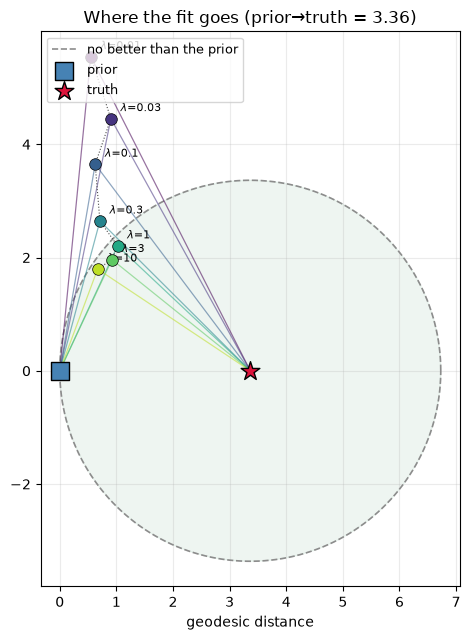

  lambda  prior→fit  truth→fit  improved?  off-axis
    0.01      5.576      6.224         NO     5.549
    0.03      4.544      5.089         NO     4.453
     0.1      3.702      4.562         NO     3.649
     0.3      2.738      3.748         NO     2.645
       1      2.430      3.219        yes     2.206
       3      2.170      3.134        yes     1.964
      10      1.916      3.239        yes     1.796

'off-axis' is the component of the fit's displacement perpendicular to the
prior→truth direction: motion that is neither toward nor away from the
truth, purely along directions the data does not constrain.


In [24]:
# --- The prior / truth / fit triangle, as a function of lambda -------------
def _triangle_vertex(d_pt, d_pf, d_tf):
    """Place the fit given its distances to prior (origin) and truth (d_pt, 0)."""
    if d_pt < 1e-12: return np.nan, np.nan
    x = (d_pf**2 - d_tf**2 + d_pt**2)/(2*d_pt)
    y2 = d_pf**2 - x**2
    return x, np.sqrt(max(y2, 0.0))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
_th = np.linspace(0, 2*np.pi, 400)
ax.plot(REF_PT + REF_PT*np.cos(_th), REF_PT*np.sin(_th), color='0.55', ls='--',
        lw=1.2, label='no better than the prior')
ax.fill(REF_PT + REF_PT*np.cos(_th), REF_PT*np.sin(_th), color='seagreen', alpha=0.08)

_cols = plt.cm.viridis(np.linspace(0, 0.9, len(_scan)))
_pts = []
for (row, col) in zip(_scan, _cols):
    lam, d_pf, d_tf = row[0], row[5], row[6]
    xf, yf = _triangle_vertex(REF_PT, d_pf, d_tf)
    _pts.append((xf, yf))
    ax.plot([0, xf, REF_PT], [0, yf, 0], color=col, lw=0.9, alpha=0.55)
    ax.scatter([xf], [yf], s=70, color=col, zorder=5, edgecolor='k', linewidth=0.5)
    ax.annotate(f'$\\lambda$={lam:g}', (xf, yf), textcoords='offset points',
                xytext=(7, 5), fontsize=8)
_pts = np.array(_pts)
ax.plot(_pts[:,0], _pts[:,1], color='0.3', lw=0.8, ls=':', zorder=4)

ax.scatter([0], [0], s=160, marker='s', color='steelblue', zorder=6,
           edgecolor='k', label='prior')
ax.scatter([REF_PT], [0], s=200, marker='*', color='crimson', zorder=6,
           edgecolor='k', label='truth')
ax.set_aspect('equal'); ax.set_xlabel('geodesic distance'); ax.set_ylabel('')
ax.set_title(f'Where the fit goes (prior→truth = {REF_PT:.2f})')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig('fit_triangles.png', dpi=150); plt.show()

print(f"{'lambda':>8s} {'prior→fit':>10s} {'truth→fit':>10s} {'improved?':>10s} "
      f"{'off-axis':>9s}")
for row, (xf, yf) in zip(_scan, _pts):
    print(f"{row[0]:8.3g} {row[5]:10.3f} {row[6]:10.3f} "
          f"{'yes' if row[6] < REF_PT else 'NO':>10s} {yf:9.3f}")
print("\n'off-axis' is the component of the fit's displacement perpendicular to the")
print("prior→truth direction: motion that is neither toward nor away from the")
print("truth, purely along directions the data does not constrain.")


### Refinement at the Selected $\lambda$

Everything below — the fitted stiffnesses, the distance diagnostics, the
Gauss-Newton spectrum, the predicted ADPs, the mode animations — uses the
`LAMBDA_PRIOR` chosen above.

In [25]:
print(f"Refining (segments of {BLOCK} iterations)")
print(f"  stop when the loss improves by < {LOSS_TOL} over {LOSS_WIN} segments, "
      f"or K moves < {GEO_TOL:g} in one")
theta_fit, theta_history, NIT, NFEV, _rows, _why = refine(
    Lmap_to_theta(L_PRIOR), (q_train, G_train, I_train, w_train))
theta0 = theta_history[0]
_, K_LAB_FIT = build_K(theta_to_Lmap(theta_fit))

_step = _rows[-1][4]
_dl   = (_rows[-1-LOSS_WIN][1] - _rows[-1][1]) if len(_rows) > LOSS_WIN else float('nan')
print(f"\nStopped after {NIT} iterations ({NFEV} evaluations) on: {_why}")
print(f"  loss improvement over the last {LOSS_WIN} segments: {_dl:.4f} χ² units")
print(f"  K moved {_step:.3e} in the final segment "
      f"(a factor {np.exp(_step):.3f} along the worst direction)")

chi2_dof = float(np.sum(w_train*(np.array([forward_I(K_LAB_FIT, *q, G=G)
                                           for q, G in zip(q_train, G_train)]) - I_train)**2)
                 / max(len(q_train) - N_PARAMS, 1))
print(f"  weighted χ²/dof (training) = {chi2_dof:.4f}")

if _why == "loss" and _step > 10*GEO_TOL:
    print("\nThe FIT is statistically converged but K is NOT: it was still moving")
    print(f"{_step:.2f} per {BLOCK} iterations when the loss stopped improving. The")
    print("reported K is therefore one point in a nearly flat region, not a point")
    print("estimate. That region is what the prior and the sloppiness spectrum")
    print("describe; a larger LAMBDA_PRIOR shrinks it (see the scan below).")
elif _why == "max_block":
    print("\nHit MAX_BLOCK without meeting either criterion -- raise it, or raise")
    print("LAMBDA_PRIOR if the geodesic step is not decaying.")

Refining (segments of 500 iterations)
  stop when the loss improves by < 1.0 over 5 segments, or K moves < 0.01 in one
   seg   iters    data loss   penalty    K moved
     1     500      168.439   24.4497  2.538e+00
     2    1000       157.62   23.0736  1.012e+00
     3    1500      154.222   22.0855  7.591e-01
     4    2000      152.549   22.3830  4.400e-01
     5    2500      151.961   22.3997  3.314e-01
     6    3000      151.531   22.4758  2.471e-01
     7    3500      151.055   22.6451  2.254e-01
     8    4000      150.965   22.5223  2.095e-01
     9    4500      150.628   22.7443  1.800e-01
    10    5000      150.559   22.7005  1.170e-01
    11    5500      150.331   22.8553  1.220e-01

Stopped after 5500 iterations (5994 evaluations) on: loss
  loss improvement over the last 5 segments: 0.8203 χ² units
  K moved 1.220e-01 in the final segment (a factor 1.130 along the worst direction)
  weighted χ²/dof (training) = 1.2528

The FIT is statistically converged but K is NOT: i

training set:  R = 0.0089   CC = 1.0000
held out:      R = 0.0145   CC = 0.9999


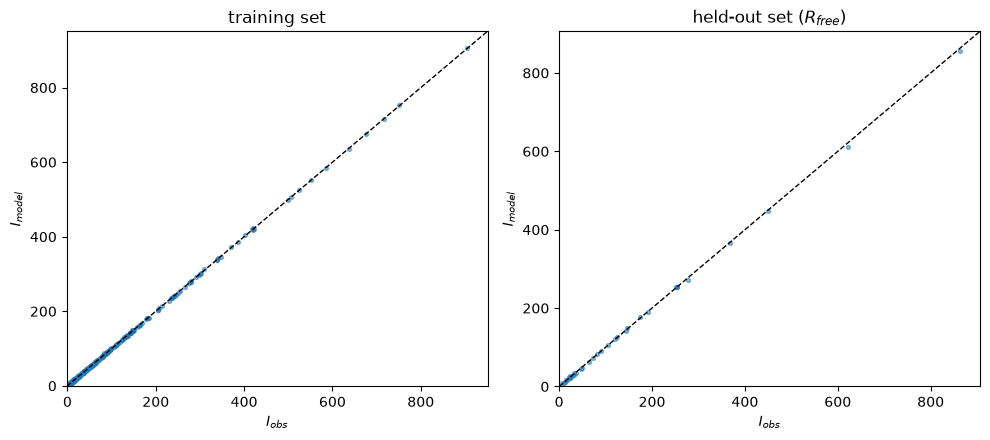

In [26]:
# R and CC on training and held-out data, at the selected lambda.
R_train, CC_train, I_model_train = fit_stats(K_LAB_FIT, q_train, G_train, I_train)
R_free,  CC_free,  I_model_test  = fit_stats(K_LAB_FIT, q_test,  G_test,  I_test)
print(f"training set:  R = {R_train:.4f}   CC = {CC_train:.4f}")
print(f"held out:      R = {R_free:.4f}   CC = {CC_free:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
for ax, Im, Io, title in [(axes[0], I_model_train, I_train, 'training set'),
                          (axes[1], I_model_test,  I_test,  'held-out set ($R_{free}$)')]:
    ax.scatter(Io, Im, s=8, alpha=0.5)
    lim = [min(0, Io.min()*1.05), max(Io.max(), Im.max())*1.05]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('$I_{obs}$'); ax.set_ylabel('$I_{model}$'); ax.set_title(title)
plt.tight_layout(); plt.savefig('refinement_fit_quality.png', dpi=150); plt.show()

### Distance Travelled, in the Metric that Respects the Units of $K$

Three geodesic distances per contact: how far the truth sits from the prior, how
far the fit went, and how close it landed to the truth. A fit that recovered the
truth shows truth→fit $\ll$ prior→truth. A fit that travels substantially
*further* from the prior than the truth does is being pulled along directions the
data does not constrain, which is a statement about `LAMBDA_PRIOR` rather than
about the optimizer.

In [27]:
# --- How far did the fit travel, and did it land on the truth? -------------
# The decisive synthetic-test number, in the metric that respects the units of K.
# Three distances per contact: how far the truth sits from the prior, how far the
# fit went, and how close the fit landed to the truth. A fit that travels much
# further from the prior than the truth does is wandering along directions the
# data does not constrain -- the regularizer is too weak.

_d_pt = D_PRIOR_TRUTH                                # prior  -> truth
_d_pf = geodesic_per_contact(THETA_PRIOR, theta_fit) # prior  -> fit
_d_tf = geodesic_per_contact(theta_true, theta_fit)  # truth  -> fit

print(f"{'contact':14s} {'prior→truth':>12s} {'prior→fit':>11s} {'truth→fit':>11s}")
for c in shell_order:
    print(f"{str(c):14s} {_d_pt[c]:12.3f} {_d_pf[c]:11.3f} {_d_tf[c]:11.3f}")
print(f"{'worst':14s} {max(_d_pt.values()):12.3f} {max(_d_pf.values()):11.3f} "
      f"{max(_d_tf.values()):11.3f}")
print()
print("A fit that recovered the truth would show truth→fit « prior→truth.")
print("prior→fit substantially larger than prior→truth means the fit has been")
print("pulled past the truth along poorly-constrained directions.")

contact         prior→truth   prior→fit   truth→fit
(-1, -1, 0)           2.441       1.910       1.745
(-1, 0, -1)           3.364       1.679       3.230
(-1, 0, 0)            2.445       1.876       1.473
(0, -1, 0)            2.959       2.439       2.247
(0, -1, 1)            2.592       1.593       2.351
(0, 0, -1)            2.766       2.094       2.092
worst                 3.364       2.439       3.230

A fit that recovered the truth would show truth→fit « prior→truth.
prior→fit substantially larger than prior→truth means the fit has been
pulled past the truth along poorly-constrained directions.


## How Many Parameters Does the Data Determine?

### The Jacobian, and why it carries $\sqrt{w}$

With $\chi^2=\sum_i w_i\,(I_i(\theta)-y_i)^2$ and $w_i=1/\sigma_i^2$, define the
**standardized residual** $r_i=\sqrt{w_i}\,(I_i-y_i)=(I_i-y_i)/\sigma_i$, so that
$\chi^2=\|r\|^2$. Its Jacobian is

$$J_{i\alpha}=\frac{\partial r_i}{\partial\theta_\alpha}
=\sqrt{w_i}\,\frac{\partial I_i}{\partial\theta_\alpha}$$

and the Gauss-Newton curvature is $\tfrac12\partial^2\chi^2/\partial\theta^2=J^{\mathsf T}J$.
This is the Fisher information of the Gaussian likelihood, and the $\sqrt w$ is what
makes $r$ dimensionless — each residual measured in units of its own error bar.
Weighting by $w$ instead of $\sqrt w$ would give a matrix with units of
$\sigma^{-4}(\partial I/\partial\theta)^2$, which is not an information and whose
inverse is not a covariance.

$J^{\mathsf T}J$ has a useful reading: a displacement $\delta\theta$ costs
$\Delta\chi^2=\delta\theta^{\mathsf T}(J^{\mathsf T}J)\,\delta\theta$. Note it does
**not** depend on the data — only on the model, the sampled $\mathbf q$, and the
error bars. The sloppy spectrum is a property of the experimental design, not of
the noise realization.

### The units problem, and its resolution

You are right to be suspicious. Under a reparameterization $\theta=A\phi$,

$$J\to JA,\qquad J^{\mathsf T}J\to A^{\mathsf T}(J^{\mathsf T}J)A$$

so the eigenvalues of $J^{\mathsf T}J$ change completely. With parameters carrying
different dimensions — here Cholesky entries of $K_{RR}$ in
$\sqrt{k_BT}/\mathrm{rad}$ and of $K_{TT}$ in $\sqrt{k_BT}/\mathrm{Å}$ — the raw
spectrum is not an invariant of the problem, and "how many directions are
determined" cannot be read off it. Counting eigenvalues above some fraction of
$\lambda_{\max}$, which is what sloppiness plots usually do, inherits that
arbitrariness.

**A metric on parameter space is what makes the question well posed.** Given any
symmetric positive-definite $M$ with the same transformation law,
$M\to A^{\mathsf T}MA$, the generalized eigenvalues of the pencil
$(J^{\mathsf T}J,\,M)$ are unchanged by *any* invertible reparameterization,
because both matrices transform identically.

Here $M$ is supplied by the geometry of the problem rather than chosen. The
regularizer is the squared affine-invariant geodesic distance
$R=\lambda\sum_{\mathbf n}d^2(K_{\mathbf n},K^{\rm prior}_{\mathbf n})$, and the
Hessian of a squared geodesic distance at its base point is twice the Riemannian
metric tensor. So

$$M=\frac{1}{2\lambda}\frac{\partial^2R}{\partial\theta^2}$$

is the natural metric on the manifold of positive-definite stiffness matrices,
pulled back to $\theta$ coordinates — independent of $\lambda$, and coordinate-free
by construction.

### The invariant spectrum

$$g_i=\text{eigenvalues of }M^{-1}J^{\mathsf T}J
\;=\;\frac{\Delta\chi^2}{(\text{geodesic displacement})^2}$$

$g$ is dimensionless, reparameterization-invariant, independent of $\lambda$, and
directly interpretable: **$g_i$ is the $\chi^2$ penalty for moving one geodesic
unit along direction $i$**, where one geodesic unit is a factor of $e$ in one
stiffness eigenvalue of one contact. A direction with $g\gtrsim1$ is measurable —
displacing it costs more than one unit of $\chi^2$, the scale on which $\chi^2$
itself is meaningful. A direction with $g\ll1$ is invisible to the data.

This gives a **prior-free** count, $n_{\rm measurable}=\#\{g>1\}$, which is the
honest answer to "how many directions does the data determine".

The prior then enters only as a threshold. Posterior precision is
$J^{\mathsf T}J+\tfrac12\partial^2R/\partial\theta^2 = J^{\mathsf T}J+\lambda M$, so
the recovered fraction along direction $i$ is

$$\frac{g_i}{g_i+\lambda}$$

Changing $\lambda$ slides a cutoff along a *fixed* curve rather than changing the
curve. Both are plotted: the $g$ spectrum, with the $g=1$ and $g=\lambda$ lines
marked, and the shrinkage $g/(g+\lambda)$.

The raw $J^{\mathsf T}J$ spectrum is shown alongside for familiarity, but it is the
non-invariant one and should not be used for counting.

In [28]:
# --- Invariant sloppiness analysis -----------------------------------------
def reg_grad_theta(theta, lam=1.0):
    """dR/dtheta for the geodesic penalty, through K = L L^T."""
    Lmap = theta_to_Lmap(theta)
    K_local, _ = build_K(Lmap)
    dRdK = regularizer_prior_dK(K_local, lam=lam)
    return Lmap_to_theta({c: np.tril((dRdK[c] + dRdK[c].T) @ Lmap[c])
                          for c in shell_order})

def parameter_metric(theta, eps=1e-5):
    """M = (1/2) d^2/dtheta^2 of the summed squared geodesic distance to the
    prior, i.e. the affine-invariant Riemannian metric on stiffness space pulled
    back to theta coordinates. Independent of LAMBDA_PRIOR by construction."""
    n = len(theta); H = np.zeros((n, n))
    for j in range(n):
        tp = theta.copy(); tp[j] += eps
        tm = theta.copy(); tm[j] -= eps
        H[:, j] = (reg_grad_theta(tp, lam=1.0) - reg_grad_theta(tm, lam=1.0))/(2*eps)
    return 0.25*(H + H.T)          # (1/2) * symmetrized Hessian

def weighted_jacobian(theta, q_list, G_list, weights, scale=1.0, eps=1e-5):
    """J = d r / d theta with r the STANDARDIZED residual (I - y)/sigma, so that
    chi^2 = ||r||^2 and J^T J = (1/2) d^2 chi^2 / d theta^2 is a Fisher
    information. Independent of the data values -- only the model, the sampled q,
    and the error bars enter."""
    sw = np.sqrt(np.asarray(weights, float))
    q_list = np.asarray(q_list, float); G_arr = np.asarray(G_list)
    qb = (q_list[:,0:1]*B_recip[:,0] + q_list[:,1:2]*B_recip[:,1]
          + q_list[:,2:3]*B_recip[:,2])
    def I_of(th):
        _, K_lab = build_K(theta_to_Lmap(th))
        D = dynamical_matrix_batch(qb, unique, K_lab)
        V = np.linalg.solve(D, G_arr[:,:,None])[:,:,0]
        return scale*np.real(np.sum(np.conj(G_arr)*V, axis=1))
    Jm = np.zeros((len(q_list), len(theta)))
    for j in range(len(theta)):
        tp = theta.copy(); tp[j] += eps
        tm = theta.copy(); tm[j] -= eps
        Jm[:, j] = sw*(I_of(tp) - I_of(tm))/(2*eps)
    return Jm

def invariant_spectrum(theta, q_list, G_list, weights, scale=1.0):
    """g = eig(M^-1 J^T J): chi^2 cost per squared geodesic displacement.
    Dimensionless, reparameterization-invariant, independent of LAMBDA_PRIOR."""
    Jm = weighted_jacobian(theta, q_list, G_list, weights, scale)
    F  = Jm.T @ Jm
    M  = parameter_metric(theta)
    Mi = _sqrtm_inv_sym(M)
    A  = Mi @ F @ Mi
    return np.linalg.eigvalsh(0.5*(A + A.T))[::-1], F, M, Jm

def report_sloppiness(theta, q_list, G_list, weights, scale=1.0,
                      fname='sloppiness_spectrum.png'):
    g, F, M, Jm = invariant_spectrum(theta, q_list, G_list, weights, scale)
    g = np.maximum(g, 0.0)
    ev_raw = np.linalg.eigvalsh(F)[::-1]
    n_meas = int(np.sum(g > 1.0))
    shrink = g/(g + LAMBDA_PRIOR)

    print(f"invariant spectrum g = Δχ² per squared geodesic unit")
    print(f"   g_max {g[0]:.4e}   g_min {g[-1]:.4e}   range {g[0]/max(g[-1],1e-300):.2e}")
    print(f"   measurable (g > 1):            {n_meas:3d} / {len(g)}")
    print(f"   recovered >90% at λ={LAMBDA_PRIOR:g}:  "
          f"{int(np.sum(shrink>0.9)):3d};  >50%: {int(np.sum(shrink>0.5)):3d}")
    print(f"\n   for reference, the raw J^T J spectrum spans "
          f"{ev_raw[0]/max(ev_raw[-1],1e-300):.1e} -- but that number changes under")
    print( "   any reparameterization and should not be used for counting.")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].semilogy(np.arange(1, len(ev_raw)+1),
                   np.maximum(ev_raw, 1e-300)/ev_raw[0], 'o-', ms=3, color='0.5')
    ax[0].set_xlabel('index'); ax[0].set_ylabel(r'$\lambda_i/\lambda_1$')
    ax[0].set_title('Raw $J^TJ$ (not invariant)')
    ax[1].semilogy(np.arange(1, len(g)+1), np.maximum(g, 1e-300), 'o-', ms=3)
    ax[1].axhline(1.0, color='r', ls='--', lw=1, label=r'$g=1$: measurable')
    ax[1].axhline(LAMBDA_PRIOR, color='g', ls=':', lw=1.4,
                  label=rf'$g=\lambda$ = {LAMBDA_PRIOR:g}')
    ax[1].axvline(n_meas+0.5, color='k', ls=':', lw=1)
    ax[1].set_xlabel('index'); ax[1].set_ylabel(r'$g$  ($\Delta\chi^2$ per geodesic unit$^2$)')
    ax[1].set_title(f'Invariant spectrum  ({n_meas} measurable)'); ax[1].legend(fontsize=8)
    ax[2].plot(np.arange(1, len(g)+1), shrink, 'o-', ms=3)
    ax[2].axhline(0.5, color='r', ls='--', lw=1)
    ax[2].set_ylim(-0.02, 1.02); ax[2].set_xlabel('index')
    ax[2].set_ylabel(r'recovered fraction $g/(g+\lambda)$')
    ax[2].set_title(rf'Shrinkage at $\lambda$ = {LAMBDA_PRIOR:g}')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()
    return g, n_meas


invariant spectrum g = Δχ² per squared geodesic unit
   g_max 6.7543e+05   g_min 2.3510e-09   range 2.87e+14
   measurable (g > 1):             67 / 126
   recovered >90% at λ=1:   50;  >50%:  67

   for reference, the raw J^T J spectrum spans 7.8e+13 -- but that number changes under
   any reparameterization and should not be used for counting.


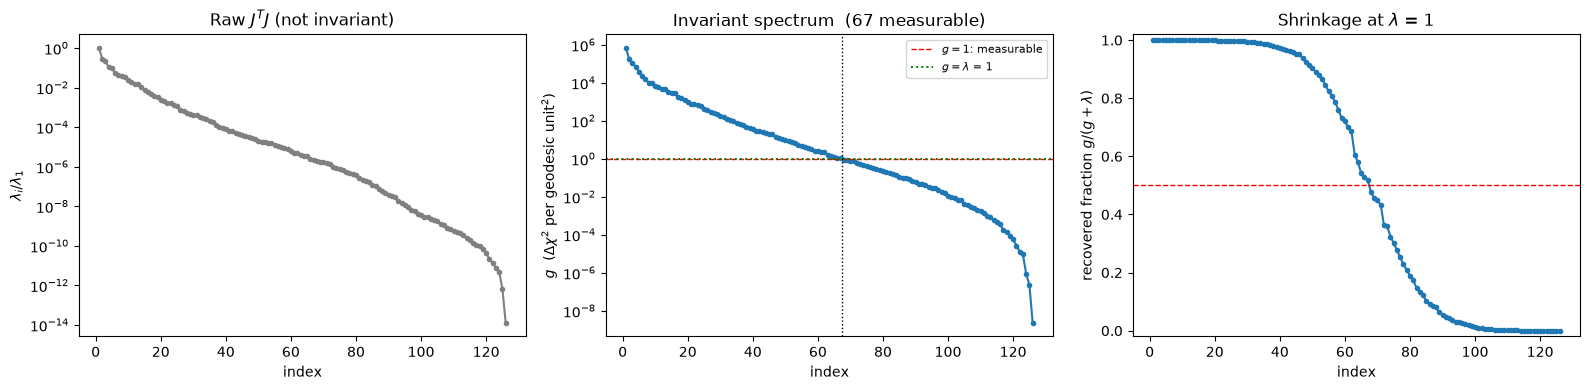


At the selected LAMBDA_PRIOR = 1, the data determines 67 of 126
parameter combinations more tightly than the prior does.


In [29]:
gen_spec, n_eff = report_sloppiness(theta_fit, q_train, G_train, w_train)
print(f"\nAt the selected LAMBDA_PRIOR = {LAMBDA_PRIOR:g}, the data determines "
      f"{n_eff} of {N_PARAMS}")
print(f"parameter combinations more tightly than the prior does.")


### Is Anything Exactly Invisible?

Two questions the spectrum alone does not settle. Does the model have directions
that change *no* intensity anywhere — an exact null space — or is the sloppiness
just a steep but non-degenerate decay? And is what we see a property of the
physics or of the finite sampling?

The model has no structural null space. Writing
$D(\mathbf q)=\sum_{\mathbf n}[A^\dagger KA+K-e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}A^\dagger K-\mathrm{h.c.}]$,
the factors $e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}$ are independent functions of
$\mathbf q$ for distinct $\mathbf R_{\mathbf n}$, so $\delta K_{\mathbf n}\neq0$
implies $\delta D\neq0$ somewhere. But $I$ sees $D$ only through the scalar
$G^\dagger D^{-1}G$, so a direction is invisible *to the experiment* whenever
$\delta D\perp vv^\dagger$ at every sampled $\mathbf q$ — a condition on the
sampling, not on the model.

The test below computes $g$ at the true $K$ for increasing numbers of
$\mathbf q$-points. Note the Jacobian does not involve the data, so noiseless data
changes nothing: what is varied is the experimental design. With fewer points than
parameters an exact null space is forced by counting, and the rank check confirms
it. Beyond that, if the small $g$ lift as points are added, the sloppiness is a
sampling limitation; if they saturate, it is intrinsic to the $1/\omega^2$
weighting and no amount of the same kind of data will fix it.

N =    60:  rank(J) =  60/126   g_max 6.176e+12   g_min 0.000e+00   measurable (g>1)  45
N =   126:  rank(J) = 126/126   g_max 6.686e+12   g_min 0.000e+00   measurable (g>1)  63
N =   280:  rank(J) = 126/126   g_max 1.945e+13   g_min 2.271e-09   measurable (g>1)  82
N =   800:  rank(J) = 126/126   g_max 5.857e+13   g_min 3.895e-08   measurable (g>1)  95
N =  2000:  rank(J) = 126/126   g_max 1.801e+14   g_min 0.000e+00   measurable (g>1) 102

rank(J) saturates at min(N, 126); below that the null space is
forced by counting, not by physics.


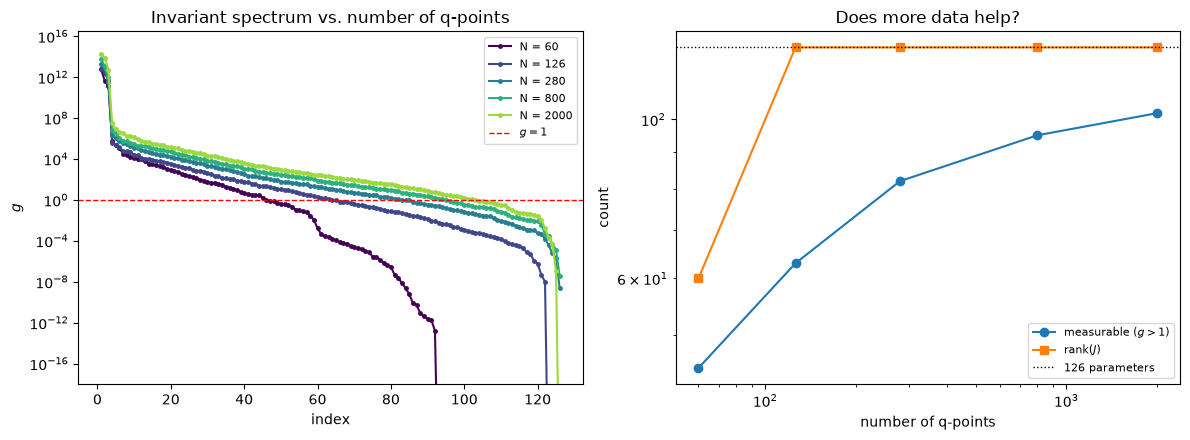


going from N = 280 to N = 2000 q-points:
   g_max   1.945e+13 -> 1.801e+14   (x9.3, ~linear in N)
   g_min   2.271e-09 -> 0.000e+00   (x0.0)
   measurable 82 -> 102

If g_min grows in proportion to N, the sloppy directions are merely
under-sampled. If it stalls while g_max grows, the spectrum has an
intrinsic shape set by the 1/omega^2 weighting, and more of the same kind
of data buys nothing there.


In [30]:
# --- Does more data lift the sloppy directions? ----------------------------
# Evaluated at the TRUE K with uniform weights, so the result is a statement about
# the experimental design alone: no noise, no regularizer, no fitted values.
NULL_SIZES = [60, 126, 280, 800, 2000]

_rng_n = np.random.default_rng(17)
_hmaxn = int(np.ceil(cell.a/D_MIN_DIFFUSE))+1
_kmaxn = int(np.ceil(cell.b/D_MIN_DIFFUSE))+1
_qcutn = 2*np.pi/D_MIN_DIFFUSE

def _sample_q(n):
    out = []
    while len(out) < n:
        h = np.round(_rng_n.uniform(-_hmaxn, _hmaxn)*P)/P
        k = np.round(_rng_n.uniform(-_kmaxn, _kmaxn)*P)/P
        l = np.round(_rng_n.uniform(-2, 2)*P)/P
        q = h*B_recip[:,0] + k*B_recip[:,1] + l*B_recip[:,2]
        if 1e-3 < np.linalg.norm(q) < _qcutn and min(abs(h-round(h)), abs(k-round(k)),
                                                     abs(l-round(l))) > 1e-9:
            out.append((h, k, l))
    return np.array(out)

_M_true = parameter_metric(theta_true)
_Mi_true = _sqrtm_inv_sym(_M_true)

_res = []
for _n in NULL_SIZES:
    _q = _sample_q(_n)
    _G = G_at_hkl_batch(_q[:,0], _q[:,1], _q[:,2])
    _J = weighted_jacobian(theta_true, _q, _G, np.ones(_n))
    _A = _Mi_true @ (_J.T @ _J) @ _Mi_true
    _g = np.maximum(np.linalg.eigvalsh(0.5*(_A + _A.T))[::-1], 0.0)
    _rank = int(np.linalg.matrix_rank(_J, tol=1e-10*np.linalg.norm(_J, 2)))
    _res.append((_n, _g, _rank))
    print(f"N = {_n:5d}:  rank(J) = {_rank:3d}/{N_PARAMS}   g_max {_g[0]:.3e}   "
          f"g_min {_g[-1]:.3e}   measurable (g>1) {int(np.sum(_g>1)):3d}")

print(f"\nrank(J) saturates at min(N, {N_PARAMS}); below that the null space is")
print("forced by counting, not by physics.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for (_n, _g, _r), col in zip(_res, plt.cm.viridis(np.linspace(0, .85, len(_res)))):
    ax[0].semilogy(np.arange(1, len(_g)+1), np.maximum(_g, 1e-30), 'o-', ms=2.5,
                   color=col, label=f'N = {_n}')
ax[0].axhline(1.0, color='r', ls='--', lw=1, label=r'$g=1$')
ax[0].set_xlabel('index'); ax[0].set_ylabel(r'$g$')
ax[0].set_title('Invariant spectrum vs. number of q-points')
ax[0].legend(fontsize=8); ax[0].set_ylim(1e-18, None)

_ns = [r[0] for r in _res]
ax[1].loglog(_ns, [np.sum(r[1] > 1) for r in _res], 'o-', label=r'measurable ($g>1$)')
ax[1].loglog(_ns, [r[2] for r in _res], 's-', label='rank($J$)')
ax[1].axhline(N_PARAMS, color='k', ls=':', lw=1, label=f'{N_PARAMS} parameters')
ax[1].set_xlabel('number of q-points'); ax[1].set_ylabel('count')
ax[1].set_title('Does more data help?'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('null_space_test.png', dpi=150); plt.show()

_g0, _gN = _res[2][1], _res[-1][1]
print(f"\ngoing from N = {_res[2][0]} to N = {_res[-1][0]} q-points:")
print(f"   g_max   {_g0[0]:.3e} -> {_gN[0]:.3e}   (x{_gN[0]/_g0[0]:.1f}, ~linear in N)")
print(f"   g_min   {_g0[-1]:.3e} -> {_gN[-1]:.3e}   (x{_gN[-1]/max(_g0[-1],1e-300):.1f})")
print(f"   measurable {int(np.sum(_g0>1))} -> {int(np.sum(_gN>1))}")
print("\nIf g_min grows in proportion to N, the sloppy directions are merely")
print("under-sampled. If it stalls while g_max grows, the spectrum has an")
print("intrinsic shape set by the 1/omega^2 weighting, and more of the same kind")
print("of data buys nothing there.")


In [31]:
def bz_covariance(K_lab, n_grid=BZ_NGRID, offset=True, eig_floor=None, chunk=None):
    """Σ = <(Ω,v)(Ω,v)^T>, from integrating D(q)^-1 over the Brillouin zone.

    Two details of the quadrature matter:

    * the grid is OFFSET (Monkhorst-Pack style) so it never lands on Γ. The
      acoustic contribution goes as ∫d³q/q² -- convergent in 3D but easy to
      undersample with a coarse Γ-inclusive grid, and Σ is the ADP prediction;
    * the eigenvalue floor is ABSOLUTE rather than relative to ev.max() at each
      q. With a strongly anisotropic K a genuine small acoustic eigenvalue near
      Γ could otherwise be zeroed merely because ev.max() is large there.
    """
    chunk = chunk or CHUNK_EVAL
    g = (np.arange(n_grid) + (0.5 if offset else 0.0))/n_grid
    Ig, Jg, Kg = np.meshgrid(g, g, g, indexing='ij')
    q_batch = np.column_stack([Ig.ravel(), Jg.ravel(), Kg.ravel()]) @ B_recip.T
    N = len(q_batch)

    if eig_floor is None:
        Dref = dynamical_matrix_batch(q_batch[:min(N, 2000)], unique, K_lab)
        eig_floor = 1e-9 * mass_weighted_eigs(Dref).max()

    Sigma = np.zeros((6,6))
    for s0 in range(0, N, chunk):
        sl = slice(s0, min(s0+chunk, N))
        Db = dynamical_matrix_batch(q_batch[sl], unique, K_lab)
        Dw = np.einsum('ij,njk,lk->nil', Msq_inv, Db, Msq_inv)
        ev, evec = np.linalg.eigh(Dw)
        e_lab = np.einsum('ij,njk->nik', Msq_inv.T, evec)
        mask  = ev > eig_floor
        coeff = np.where(mask, 1.0/np.where(mask, ev, 1.0), 0.0)
        Sigma += np.real(np.einsum('ns,nis,njs->ij', coeff, e_lab, e_lab.conj()))
    return Sigma/N

def atom_adp_tensors(Sigma, positions):
    """Full anisotropic displacement tensor U (Å², 3x3) per atom. Vectorized."""
    d = np.asarray(positions) - r_cm_at
    N = len(d)
    Jr = np.zeros((N, 3, 6))
    Jr[:,0,1] =  d[:,2]; Jr[:,0,2] = -d[:,1]
    Jr[:,1,0] = -d[:,2]; Jr[:,1,2] =  d[:,0]
    Jr[:,2,0] =  d[:,1]; Jr[:,2,1] = -d[:,0]
    Jr[:,0,3] = Jr[:,1,4] = Jr[:,2,5] = 1.0
    return np.einsum('nia,ab,njb->nij', Jr, Sigma, Jr)

def isotropic_B(U):
    return (8*np.pi**2/3) * np.trace(U, axis1=1, axis2=2)

def mean_predicted_B(K_lab, n_grid=BZ_NGRID):
    return isotropic_B(atom_adp_tensors(bz_covariance(K_lab, n_grid=n_grid), apos)).mean()

def check_bz_convergence(K_lab, grids=(8, 12, 16, BZ_NGRID)):
    """Σ is the headline ADP prediction -- never report it without this."""
    print("BZ-grid convergence of the predicted mean B:")
    prev = None
    for n in grids:
        B = mean_predicted_B(K_lab, n_grid=n)
        delta = '' if prev is None else f'   Δ = {100*(B-prev)/prev:+.2f}%'
        print(f"  n_grid={n:3d}³ ({n**3:6d} q-points):  mean B = {B:8.3f} Å²{delta}")
        prev = B


## What the Data Actually Determines

$K$ itself is poorly determined, but that is not the same as saying the data is
uninformative. The quantity measured at each $\mathbf q$ is

$$I(\mathbf q)=G^\dagger D^{-1}G=\mathrm{Tr}\bigl[D(\mathbf q)^{-1}GG^\dagger\bigr]
=\sum_s\frac{|G\cdot e_s|^2}{\omega_s^2}$$

a single projection of $D^{-1}$ onto one rank-1 direction, and weighted as
$1/\omega^2$. Two consequences follow, and they explain everything seen above.

**The data measures the soft sector.** A branch three times stiffer contributes
nine times less intensity. The stiff directions of $K$ are therefore nearly
invisible, which is where the $\sim53$ prior-carried directions come from. It is
not a defect of the sampling — it is what thermal diffuse scattering is.

**$\Sigma$ carries exactly the same weighting.** The displacement covariance
$\Sigma=\langle uu^\dagger\rangle=N^{-1}\sum_{\mathbf q}D(\mathbf q)^{-1}$ is the
same $1/\omega^2$-weighted object, integrated over the zone rather than projected
onto $G$. So the ADPs are determined about as well as the intensities are, even
though $K$ is not. (Worth keeping in mind when reading the ADP comparison in the
experimental notebook as an independent check: it is a genuinely different
functional over a different set of $\mathbf q$, but it probes the same soft
sector the fit was trained on.)

**Why the band structure looks converged.** $\omega(\mathbf q)$ is 6 numbers per
$\mathbf q$; $D(\mathbf q)$ is 36 real numbers. Matching eigenvalues is a 6-of-36
compression, and matrices related by unitary conjugation share them exactly. So a
band structure can agree closely while $D$ — and hence $K$ — differs a great deal.

Note the degeneracy is in the *data*, not the model: in
$D(\mathbf q)=\sum_{\mathbf n}[A^\dagger KA+K-e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}A^\dagger K-\mathrm{h.c.}]$
the factors $e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}$ are independent functions of
$\mathbf q$ for distinct $\mathbf R_{\mathbf n}$, so $K_{\mathbf n}$ *is* recoverable
from $D$ known everywhere. It is the finite, $1/\omega^2$-weighted sampling that
loses it.

The cell below turns this from an argument into a measurement. Sampling the
posterior $\theta\sim\mathcal N(\hat\theta,\,\mathcal C)$ with
$\mathcal C=(J^{\mathsf T}J+\tfrac12\partial^2R/\partial\theta^2)^{-1}$ and
propagating through, it shows which *physical* quantities survive: the dispersion
with an uncertainty band, the predicted mean $B$, and the per-contact spread in
$K$ measured in the geodesic metric.

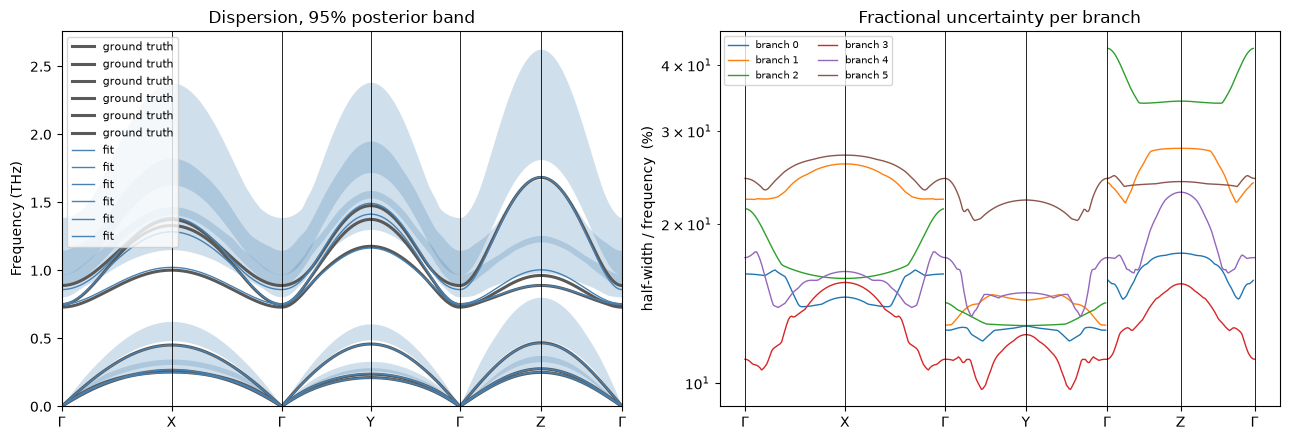

Ground-truth dispersion inside the 95% posterior band: 0.6% of (q, branch) pairs
Median fractional uncertainty, acoustic branches 0-2: 16.03%
Median fractional uncertainty, librational branches 3-5: 16.15%

Mean B: fit 0.386  posterior 0.246 ± 0.022 Å²  (9.1%)   truth 0.385 Å²

contact         posterior spread in K   worst-direction factor
(-1, -1, 0)                     1.948                     7.01
(-1, 0, -1)                     3.390                    29.67
(-1, 0, 0)                      1.479                     4.39
(0, -1, 0)                      1.122                     3.07
(0, -1, 1)                      2.479                    11.93
(0, 0, -1)                      1.444                     4.24

Read the three together: the dispersion is pinned to a few percent, the
mean B to around ten, while individual contact stiffnesses are uncertain by
factors. The data measures the soft dynamics, not the springs.


In [32]:
# --- Propagate the posterior to physical observables -----------------------
# Covariance from the Gauss-Newton Hessian of the data term plus the prior's
# curvature. With chi^2 = sum w r^2 the Fisher information is J^T J, and treating
# the penalty R as -2 ln(prior) contributes R''/2, so C = (J^T J + H_R/2)^-1.
# Inflating by chi2/dof allows for model error on top of the quoted sigmas.

N_POST = 60          # posterior samples
INFLATE_BY_CHI2 = True

def posterior_cov_sqrt(theta, q_list, G_list, weights, scale=1.0, chi2_dof=1.0):
    Jm = weighted_jacobian(theta, q_list, G_list, weights, scale)
    H  = Jm.T @ Jm + LAMBDA_PRIOR*parameter_metric(theta)
    H  = 0.5*(H + H.T)
    w, V = np.linalg.eigh(H)
    w = np.maximum(w, 1e-12*w.max())
    f = np.sqrt(chi2_dof) if INFLATE_BY_CHI2 else 1.0
    return f*(V*w**-0.5)          # C^(1/2): samples = theta + Csqrt @ randn

_Csq = posterior_cov_sqrt(theta_fit, q_train, G_train, w_train, chi2_dof=chi2_dof)
_rng_p = np.random.default_rng(3)
_samples = theta_fit[None, :] + (_Csq @ _rng_p.standard_normal((N_PARAMS, N_POST))).T

# --- 1. dispersion ---------------------------------------------------------
_bands = np.stack([bandstructure_freqs(build_K(theta_to_Lmap(t))[1]) for t in _samples])
_lo, _hi = np.percentile(_bands, [2.5, 97.5], axis=0)
_fit_b   = bandstructure_freqs(K_LAB_FIT)
_true_b  = bandstructure_freqs(K_LAB_TRUE)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for s in range(6):
    ax[0].fill_between(x, _lo[:, s], _hi[:, s], color='steelblue', alpha=0.25, lw=0)
ax[0].plot(x, _true_b, color='0.35', lw=2.2, label='ground truth')
ax[0].plot(x, _fit_b,  color='steelblue', lw=1.0, label='fit')
for ti in tick_idx: ax[0].axvline(x[ti], color='k', lw=0.6)
ax[0].set_xticks([x[ti] for ti in tick_idx]); ax[0].set_xticklabels(path_labels)
ax[0].set_ylabel('Frequency (THz)'); ax[0].set_xlim(x[0], x[-1]); ax[0].set_ylim(0)
ax[0].set_title('Dispersion, 95% posterior band'); ax[0].legend(fontsize=8)

_rel = np.where(_fit_b > 1e-9, 0.5*(_hi - _lo)/np.maximum(_fit_b, 1e-9), np.nan)
for s in range(6):
    ax[1].plot(x, 100*_rel[:, s], lw=1.0, label=f'branch {s}')
for ti in tick_idx: ax[1].axvline(x[ti], color='k', lw=0.6)
ax[1].set_xticks([x[ti] for ti in tick_idx]); ax[1].set_xticklabels(path_labels)
ax[1].set_ylabel('half-width / frequency  (%)'); ax[1].set_yscale('log')
ax[1].set_title('Fractional uncertainty per branch'); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.savefig('posterior_bands.png', dpi=150); plt.show()

_inside = np.mean((_true_b >= _lo) & (_true_b <= _hi))
print(f"Ground-truth dispersion inside the 95% posterior band: {_inside:.1%} of "
      f"(q, branch) pairs")
print(f"Median fractional uncertainty, acoustic branches 0-2: "
      f"{100*np.nanmedian(_rel[:, :3]):.2f}%")
print(f"Median fractional uncertainty, librational branches 3-5: "
      f"{100*np.nanmedian(_rel[:, 3:]):.2f}%")

# --- 2. displacement parameters -------------------------------------------
_B = np.array([isotropic_B(atom_adp_tensors(
                   bz_covariance(build_K(theta_to_Lmap(t))[1], n_grid=12),
                   apos)).mean()
               for t in _samples[:min(N_POST, 25)]])
_B_true = isotropic_B(atom_adp_tensors(bz_covariance(K_LAB_TRUE, n_grid=12), apos)).mean()
print(f"\nMean B: fit {isotropic_B(atom_adp_tensors(bz_covariance(K_LAB_FIT, n_grid=12), apos)).mean():.3f}"
      f"  posterior {np.mean(_B):.3f} ± {np.std(_B):.3f} Å²"
      f"  ({100*np.std(_B)/np.mean(_B):.1f}%)   truth {_B_true:.3f} Å²")

# --- 3. the stiffnesses themselves ----------------------------------------
_spread = {c: np.std([geodesic_per_contact(theta_fit, t)[c] for t in _samples[:30]])
           for c in shell_order}
print(f"\n{'contact':14s} {'posterior spread in K':>22s} {'worst-direction factor':>24s}")
for c in shell_order:
    print(f"{str(c):14s} {_spread[c]:22.3f} {np.exp(_spread[c]):24.2f}")
print("\nRead the three together: the dispersion is pinned to a few percent, the")
print("mean B to around ten, while individual contact stiffnesses are uncertain by")
print("factors. The data measures the soft dynamics, not the springs.")


### Which Directions Are Recoverable

An isotropic perturbation of the prior — how `L_TRUE` is built — mixes the
data-determined and prior-carried directions together, so `truth→fit` measures a
blend. This test separates them.

The Gauss-Newton spectrum supplies an orthogonal split of parameter space into
the $n_{\rm eff}$ directions the data constrains more tightly than the prior and
the remainder it does not. Two alternative ground truths are constructed, one
displaced from the prior purely along the stiff subspace and one purely along the
sloppy subspace, **scaled to the same geodesic distance**. Synthetic data is
generated from each and refit.

The expectation, if the reading above is right: the stiff perturbation is
recovered, the sloppy one is not, and both reproduce the intensities equally well.
That also answers what happens if the ground truth is placed further from the
prior — the recoverable fraction stays roughly constant, so `truth→fit` grows in
proportion rather than the fit suddenly succeeding or failing.

In [33]:
# --- Stiff vs. sloppy: which displacements from the prior are recoverable? --
Jm_p    = weighted_jacobian(THETA_PRIOR, q_train, G_train, w_train)
Hd_p    = Jm_p.T @ Jm_p
Hr_p    = 2*LAMBDA_PRIOR*parameter_metric(THETA_PRIOR)
_Binv   = _sqrtm_inv_sym(Hr_p)
_M      = 0.5*((_Binv @ Hd_p @ _Binv) + (_Binv @ Hd_p @ _Binv).T)
_gv, _U = np.linalg.eigh(_M)
_ord    = np.argsort(_gv)[::-1]
_gv, _U = _gv[_ord], _U[:, _ord]
_dirs   = _Binv @ _U                      # back to theta coordinates
_n_eff  = int(np.sum(_gv > 1.0))
print(f"data-dominated directions: {_n_eff} / {N_PARAMS}")

def _unit(v): return v/np.linalg.norm(v)
_stiff_dir  = _unit(_dirs[:, :max(_n_eff, 1)].sum(axis=1))
_sloppy_dir = _unit(_dirs[:, _n_eff:].sum(axis=1)) if _n_eff < N_PARAMS else None

def _make_truth(direction, target_d=1.5, tol=0.02):
    """Displace the prior along `direction`, scaled to a target geodesic distance."""
    lo, hi = 1e-4, 50.0
    for _ in range(60):
        a = 0.5*(lo + hi)
        th = THETA_PRIOR + a*direction
        try:
            d = max(geodesic_per_contact(THETA_PRIOR, th).values())
        except np.linalg.LinAlgError:
            hi = a; continue
        if abs(d - target_d) < tol: break
        lo, hi = (a, hi) if d < target_d else (lo, a)
    return th, d

def _recovery(theta_t, label):
    _, Klab_t = build_K(theta_to_Lmap(theta_t))
    I_t  = diffuse_intensity_batch(Klab_t, q_all[:,0], q_all[:,1], q_all[:,2], G_arr=G_all)
    sg   = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(I_t, 0, None))
    I_o  = I_t + np.random.default_rng(5).normal(0, sg)
    w    = 1.0/sg**2
    th, _, _, _, rw, _ = refine(THETA_PRIOR, (q_all, G_all, I_o, w),
                                max_block=30, verbose=False)
    _, Klab_f = build_K(theta_to_Lmap(th))
    d_pt = max(geodesic_per_contact(THETA_PRIOR, theta_t).values())
    d_tf = max(geodesic_per_contact(theta_t, th).values())
    R, CC, _ = fit_stats(Klab_f, q_all, G_all, I_o)
    print(f"{label:22s} prior→truth {d_pt:6.3f}   truth→fit {d_tf:6.3f}   "
          f"recovered {100*(1-d_tf/d_pt):5.1f}%   R {R:.4f}  CC {CC:.5f}")
    return d_pt, d_tf

print(f"\n{'perturbation':22s} {'distances and recovery':>60s}")
for _d, _lab in [(_stiff_dir, 'stiff subspace'),
                 (_sloppy_dir, 'sloppy subspace')]:
    if _d is None: continue
    _th_t, _ = _make_truth(_d)
    _recovery(_th_t, _lab)
_recovery(theta_true, 'isotropic (L_TRUE)')

print("\nIf the stiff row recovers a large fraction while the sloppy row recovers")
print("little -- at comparable R and CC -- then truth→fit for an isotropic")
print("perturbation is measuring the sloppy component, and scales with how far the")
print("truth is placed rather than indicating the fit has failed.")


data-dominated directions: 60 / 126

perturbation                                                 distances and recovery
stiff subspace         prior→truth  1.502   truth→fit  1.093   recovered  27.2%   R 0.0104  CC 0.99994
sloppy subspace        prior→truth  1.519   truth→fit  1.712   recovered -12.7%   R 0.0091  CC 0.99996
isotropic (L_TRUE)     prior→truth  3.364   truth→fit  3.027   recovered  10.0%   R 0.0092  CC 0.99996

If the stiff row recovers a large fraction while the sloppy row recovers
little -- at comparable R and CC -- then truth→fit for an isotropic
perturbation is measuring the sloppy component, and scales with how far the
truth is placed rather than indicating the fit has failed.


### Reading the Stiff and Sloppy Directions

The eigendirections of $(F,P)$ — data curvature $F=J^{\mathsf T}J$ against prior
curvature $P=\tfrac12\partial^2R/\partial\theta^2$ — are abstract vectors in the
126-dimensional Cholesky space. Three things make them interpretable.

**How much of each is recovered, in closed form.** For a Gaussian linear model the
posterior mean is $\hat\theta=(F+P)^{-1}F\,\theta_{\rm true}$, so along a
generalized eigendirection with eigenvalue $f=F/P$ the recovered fraction is
exactly $f/(1+f)$ — no refit required. The shrinkage curve is the honest answer to
"which directions are stiff": not a binary split but a continuum, and $n_{\rm eff}$
counts $f>1$, i.e. directions recovered more than half. A direction sitting just
above that cutoff is barely measured, which is why a test perturbation built from
*all* the data-dominated directions came back only ~43% rather than ~100%.

**What each direction is, in $K$.** Mapping $\delta\theta\to\delta K_{\mathbf n}$
and non-dimensionalizing with each contact's gyration radius
($S=\mathrm{diag}(I/\rho_g,I)$, so translational and rotational entries are
comparable), each direction decomposes by **which contact** it lives on, by
**block** ($TT$, $TR$, $RR$), and within each block into an **isotropic** part —
an overall stiffening — and a **deviatoric** part, a change of anisotropy at fixed
magnitude.

**What each direction does, physically.** The induced fractional change in the
acoustic sound speeds near $\Gamma$, in the librational rest frequencies at
$\Gamma$, at the zone boundary, and in the predicted mean $B$. This is the
decomposition that answers the question directly: a direction the data pins down
tightly but which changes no observable is uninteresting, and one that is poorly
determined but moves the sound speeds is a warning.

### What the composition says

Averaged over the two subspaces, the split is sharp:

| subspace | $RR$ | $TR$ | $TT$ |
|---|---|---|---|
| data-determined | 0.02 | 0.41 | 0.57 |
| prior-carried | 0.61 | 0.36 | 0.03 |

**The diffuse data measures translational contact stiffness and barely sees
rotational contact stiffness.** Three effects compound to produce this:

1. $I\propto1/\omega^2$, and the librational branches are the stiff ones.
2. At small reduced $\mathbf q$ the acoustic eigenvectors are *pure translations* —
   $D(0)$ annihilates exactly the three translations — so the brightest part of
   the pattern, the halos, couples only through $G_T=i\mathbf qF$.
3. $L(\mathbf q)\to0$ as $\mathbf q\to0$ (the first moment about the centroid
   vanishes), so $G_R$ is further suppressed exactly where the intensity is
   largest.

The $TR$ block sits in between, at $\sim0.4$ in both subspaces, which is what one
should expect: the contacts are off-centre, so translation–rotation coupling mixes
librational character into the acoustic branches at finite $\mathbf q$ and is
therefore partly visible.

The contact ranking follows the same logic. The stiffest directions are
concentrated on the largest contact, and the sloppiest on the smallest — the
contact with the fewest atom pairs and the smallest patch contributes least to
every mode, so its stiffness is the least observable.

recovered fraction f/(1+f):  >90% for  49 directions, >50% for  66, <10% for  41
n_eff (f > 1) = 66 / 126

Composition, and the effect of a displacement of geodesic size 0.2 along each direction:
 dir         f  recov    RR    TR    TT  iso(TT)    top contact   Δν_ac  Δν_lib   Δν_zb      ΔB
   0  2.34e+05 100.0%  0.00  0.01  0.99     0.52     (0, -1, 0)    4.7%    2.7%    5.4%   11.6%
   1  1.02e+05 100.0%  0.00  0.00  1.00     0.18     (0, -1, 0)    3.3%    2.4%    3.7%    3.9%
   2  6.14e+04 100.0%  0.00  0.01  0.99     0.12     (0, -1, 0)    2.7%    1.0%    2.5%    0.9%
  65  1.10e+00  52.3%  0.23  0.70  0.07     0.32     (0, -1, 0)    0.4%    0.7%    0.4%    0.0%
 123  1.34e-06   0.0%  0.98  0.02  0.00     0.28     (0, -1, 1)    0.0%    0.0%    0.0%    0.0%
 124  3.43e-07   0.0%  0.99  0.01  0.00     0.30     (0, -1, 1)    0.0%    0.0%    0.0%    0.0%
 125  6.21e-09   0.0%  0.99  0.01  0.00     0.31     (0, -1, 1)    0.0%    0.0%    0.0%    0.0%
   Δν_ac  acoustic branches near Γ (

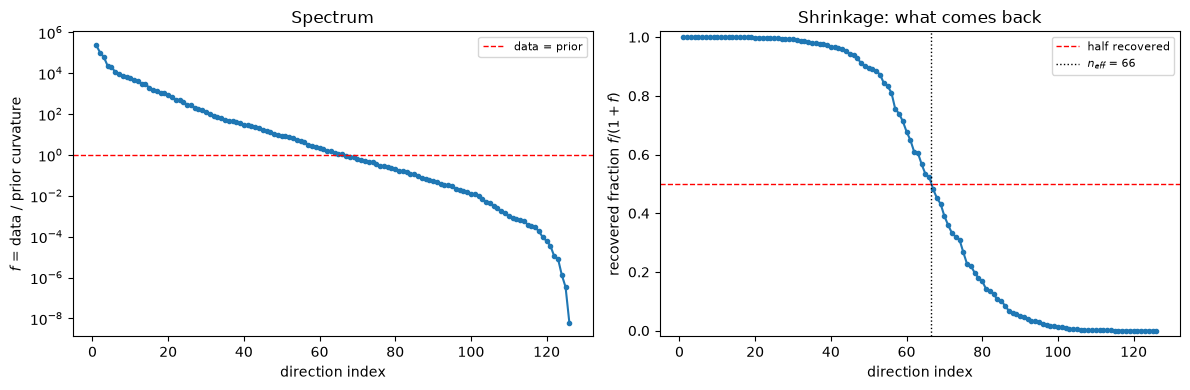

In [34]:
# --- Anatomy of the stiff and sloppy directions ----------------------------
_Fm = Jm_p.T @ Jm_p                      # data curvature at the prior
_Pm = LAMBDA_PRIOR*parameter_metric(THETA_PRIOR)   # prior precision = lambda * M
_Pi = _sqrtm_inv_sym(_Pm)
_A  = _Pi @ _Fm @ _Pi
_f, _V = np.linalg.eigh(0.5*(_A + _A.T))
_o  = np.argsort(_f)[::-1]
_f, _V = np.maximum(_f[_o], 0.0), _V[:, _o]
_DIRS = _Pi @ _V                          # back to theta coordinates
_shrink = _f/(1.0 + _f)

print(f"recovered fraction f/(1+f):  >90% for {np.sum(_shrink>0.9):3d} directions, "
      f">50% for {np.sum(_shrink>0.5):3d}, <10% for {np.sum(_shrink<0.1):3d}")
print(f"n_eff (f > 1) = {int(np.sum(_f>1))} / {N_PARAMS}")

# --- composition of a direction -------------------------------------------
_S = {c: np.diag(np.r_[np.full(3, 1.0/unique[c]['rho_g']), np.ones(3)])
      for c in shell_order}

def direction_anatomy(direction, eps=1e-4):
    """Where a theta-direction lives in K, non-dimensionalized."""
    tp, tm = THETA_PRIOR + eps*direction, THETA_PRIOR - eps*direction
    Kp, _ = build_K(theta_to_Lmap(tp)); Km, _ = build_K(theta_to_Lmap(tm))
    dK = {c: _S[c] @ ((Kp[c]-Km[c])/(2*eps)) @ _S[c] for c in shell_order}
    tot = sum(np.sum(dK[c]**2) for c in shell_order) or 1.0
    per_contact = {c: np.sum(dK[c]**2)/tot for c in shell_order}
    blocks, iso = {}, {}
    for name, sl in [('RR', slice(0,3)), ('TT', slice(3,6))]:
        b = sum(np.sum(dK[c][sl, sl]**2) for c in shell_order)
        t = sum((np.trace(dK[c][sl, sl])**2)/3 for c in shell_order)
        blocks[name] = b/tot; iso[name] = t/max(b, 1e-300)
    blocks['TR'] = sum(2*np.sum(dK[c][0:3,3:6]**2) for c in shell_order)/tot
    return per_contact, blocks, iso

# --- what a direction does, physically ------------------------------------
# Every direction is rescaled to the SAME geodesic distance before the effect is
# measured. Without that the comparison is meaningless: a unit-norm step in theta
# is a different physical perturbation for every direction, because theta holds
# Cholesky entries whose magnitude runs from ~sqrt(K_TT) ~ 7 to ~sqrt(K_RR) ~ 40.
_q_ac = np.array([[0.04,0,0],[0,0.04,0],[0,0,0.04]]) @ B_recip.T   # near Gamma
_q_zb = (B_recip @ np.array([0.5,0.5,0.5]))[None, :]
EFFECT_D = 0.20        # geodesic distance at which every direction is compared

def scale_to_geodesic(direction, target_d=EFFECT_D, tol=0.01):
    """Amplitude along `direction` giving a geodesic displacement of target_d."""
    lo, hi = 1e-6, 1e4
    for _ in range(80):
        a = np.sqrt(lo*hi)
        try:
            d = max(geodesic_per_contact(THETA_PRIOR, THETA_PRIOR + a*direction).values())
        except np.linalg.LinAlgError:
            hi = a; continue
        if abs(d - target_d) < tol*target_d: return a
        lo, hi = (a, hi) if d < target_d else (lo, a)
    return a

def direction_effect(direction, target_d=EFFECT_D):
    """Fractional change in physical observables for a displacement of fixed
    geodesic size along `direction`. Branches are sorted ascending, so [:3] are
    acoustic and [3:] librational."""
    a = scale_to_geodesic(direction, target_d)
    def obs(th):
        _, Kl = build_K(theta_to_Lmap(th))
        f_ac = bandstructure_freqs(Kl, _q_ac)[:, :3].ravel()   # acoustic near Gamma
        f_G  = bandstructure_freqs(Kl, np.zeros((1,3)))[0][3:] # librational at Gamma
        f_zb = bandstructure_freqs(Kl, _q_zb)[0]               # zone boundary, all 6
        B    = isotropic_B(atom_adp_tensors(bz_covariance(Kl, n_grid=8), apos)).mean()
        return np.r_[f_ac, f_G, f_zb, B]
    p, m = obs(THETA_PRIOR + a*direction), obs(THETA_PRIOR - a*direction)
    return np.abs(p-m)/np.maximum(0.5*np.abs(p+m), 1e-30)

_probe_idx = [0, 1, 2, max(0, int(np.sum(_f>1))-1), N_PARAMS-3, N_PARAMS-2, N_PARAMS-1]
print(f"\nComposition, and the effect of a displacement of geodesic size "
      f"{EFFECT_D} along each direction:")
print(f"{'dir':>4s} {'f':>9s} {'recov':>6s} {'RR':>5s} {'TR':>5s} {'TT':>5s} "
      f"{'iso(TT)':>8s} {'top contact':>14s} {'Δν_ac':>7s} {'Δν_lib':>7s} "
      f"{'Δν_zb':>7s} {'ΔB':>7s}")
for i in _probe_idx:
    d = _DIRS[:, i]/np.linalg.norm(_DIRS[:, i])
    pc, bl, iso = direction_anatomy(d)
    eff = direction_effect(d)
    top = max(pc, key=pc.get)
    print(f"{i:4d} {_f[i]:9.2e} {_shrink[i]:6.1%} {bl['RR']:5.2f} {bl['TR']:5.2f} "
          f"{bl['TT']:5.2f} {iso['TT']:8.2f} {str(top):>14s} "
          f"{np.mean(eff[0:9]):7.1%} {np.mean(eff[9:12]):7.1%} "
          f"{np.mean(eff[12:18]):7.1%} {eff[-1]:7.1%}")
print("   Δν_ac  acoustic branches near Γ (the sound speeds)")
print("   Δν_lib librational rest frequencies at Γ")
print("   Δν_zb  all six branches at the zone boundary")
print("   A direction with small f but large Δν_lib is one the data does NOT")
print("   determine yet which moves the optical branches -- read the dispersion")
print("   uncertainty band with that in mind.")

# --- averaged over the stiff and sloppy halves ----------------------------
_ne = max(int(np.sum(_f > 1)), 1)
print(f"\naveraged composition ({_ne} data-dominated vs {N_PARAMS-_ne} prior-carried):")
for _lab, _rng in [('stiff', range(0, _ne)), ('sloppy', range(_ne, N_PARAMS))]:
    _acc = np.zeros(3); _isotr = 0.0; _pcs = {c: 0.0 for c in shell_order}
    for i in _rng:
        d = _DIRS[:, i]/np.linalg.norm(_DIRS[:, i])
        pc, bl, iso = direction_anatomy(d)
        _acc += np.array([bl['RR'], bl['TR'], bl['TT']]); _isotr += iso['TT']
        for c in shell_order: _pcs[c] += pc[c]
    _acc /= len(_rng); _isotr /= len(_rng)
    _pcs = {c: v/len(_rng) for c, v in _pcs.items()}
    print(f"   {_lab:7s} RR {_acc[0]:.2f}   TR {_acc[1]:.2f}   TT {_acc[2]:.2f}   "
          f"isotropic fraction of TT {_isotr:.2f}")
    _rank = sorted(_pcs.items(), key=lambda kv: -kv[1])
    print(f"   {'':7s} contacts: " +
          "  ".join(f"{str(c)} {v:.2f}" for c, v in _rank[:3]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(np.arange(1, N_PARAMS+1), np.maximum(_f, 1e-12), 'o-', ms=3)
ax[0].axhline(1.0, color='r', ls='--', lw=1, label='data = prior')
ax[0].set_xlabel('direction index'); ax[0].set_ylabel('$f$ = data / prior curvature')
ax[0].set_title('Spectrum'); ax[0].legend(fontsize=8)
ax[1].plot(np.arange(1, N_PARAMS+1), _shrink, 'o-', ms=3)
ax[1].axhline(0.5, color='r', ls='--', lw=1, label='half recovered')
ax[1].axvline(_ne+0.5, color='k', ls=':', lw=1, label=f'$n_{{eff}}$ = {_ne}')
ax[1].set_xlabel('direction index'); ax[1].set_ylabel('recovered fraction $f/(1+f)$')
ax[1].set_ylim(-0.02, 1.02); ax[1].set_title('Shrinkage: what comes back')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('stiff_sloppy_anatomy.png', dpi=150); plt.show()


## Watching the Band Structure Converge

The true band structure (from $K_{\rm true}$) is the thick grey line along the
same Γ–X–Γ–Y–Γ–Z–Γ path; the coloured line is the current Cholesky parameters at
each L-BFGS-B iteration. Only band structures are recomputed per frame (one
batched call, a few hundred $6\times6$ complex-Hermitian eigenproblems), never
the full diffuse map, and frames are rasterized and discarded one at a time.

Because the diffuse signal is dominated by the acoustic branches, expect the
low-frequency bands near Γ to lock onto the true curve quickly while the
librational branches — which contribute far less to $I(\mathbf q)$ — converge
more slowly. That asymmetry is the visible face of the sloppiness quantified
below: it is not a defect of the optimizer but a statement about which parameter
combinations the data actually constrains.

In [35]:
freqs_true_bs = bandstructure_freqs(K_LAB_TRUE)
ymax = max(freqs_true_bs.max(), bandstructure_freqs(K_LAB_FIT).max())*1.15

frame_idx = np.unique(np.linspace(0, len(theta_history)-1,
                                  min(60, len(theta_history))).astype(int))

legend_handles = [Line2D([0],[0], color='0.6', lw=3.5, label='Ground truth'),
                  Line2D([0],[0], color='steelblue', lw=1.3, label='Current fit')]

images_bs = []
for fi in frame_idx:
    _, K_lab_fi = build_K(theta_to_Lmap(theta_history[fi]))
    freqs_fi = bandstructure_freqs(K_lab_fi)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, freqs_true_bs, color='0.6', lw=3.5, zorder=1)
    ax.plot(x, freqs_fi, color='steelblue', lw=1.3, zorder=2)
    for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
    ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
    ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0], x[-1]); ax.set_ylim(0, ymax)
    ax.set_title(f'Band-structure convergence — iteration {fi}/{len(theta_history)-1}')
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8)
    plt.tight_layout()
    images_bs.append(fig_to_image(fig))
    plt.close(fig)

imageio.mimsave('band_structure_convergence.gif', images_bs, fps=8, loop=0)
del images_bs; gc.collect()
print(f"Saved band_structure_convergence.gif ({len(frame_idx)} frames from "
      f"{len(theta_history)} iterations)")

Saved band_structure_convergence.gif (60 frames from 5501 iterations)


### Prior, Fit, and Truth Side by Side

The same $(h,k)$ plane computed from three stiffness matrices — the geometric
prior the refinement started from, the refined result, and the ground truth the
synthetic data was generated from — on a **shared colour scale**, so the question
"has the diffuse scattering moved appreciably" can be answered by eye.

$G(\mathbf q)$ depends only on the structure, never on $K$, so it is evaluated
once for the plane and reused for all three panels.

The pairwise correlation coefficients printed underneath are the quantitative
version of the same comparison. Expect all three to be very high: the point of the
figure is that a large change in $K$ produces a small change in the pattern, which
is the sloppiness seen from the observable side.

**Where to look.** The log-scale panels are dominated by $|G(\mathbf q)|^2$, which
is identical for all three $K$ — only the modulation by $D^{-1}$ differs, and on a
scale spanning five decades a tens-of-percent change is invisible. Three ways to
see what the fit did:

* **Ratio maps** (second figure): $I/I_{\rm truth}-1$ on a linear diverging scale.
  This divides out the common structure and shows only what $K$ controls.
* **$CC$ on $\log I$** rather than on $I$. The raw $CC$ is inflated by the halo
  peaks, which all three models reproduce because they share $G$; the log version
  weights the whole plane evenly and is the more honest number.
* **A half-integer $l$ plane.** At $l=0$ the plane runs through the integer
  Bragg positions, so the halos dominate; at $l=0.5$ they are absent and the
  mid-zone signal — where the librational branches contribute relatively more —
  sets the pattern. Set `L_PANEL = 0.5` and re-run.

Evaluating G once on a 177×193 plane, reused for all three panels...


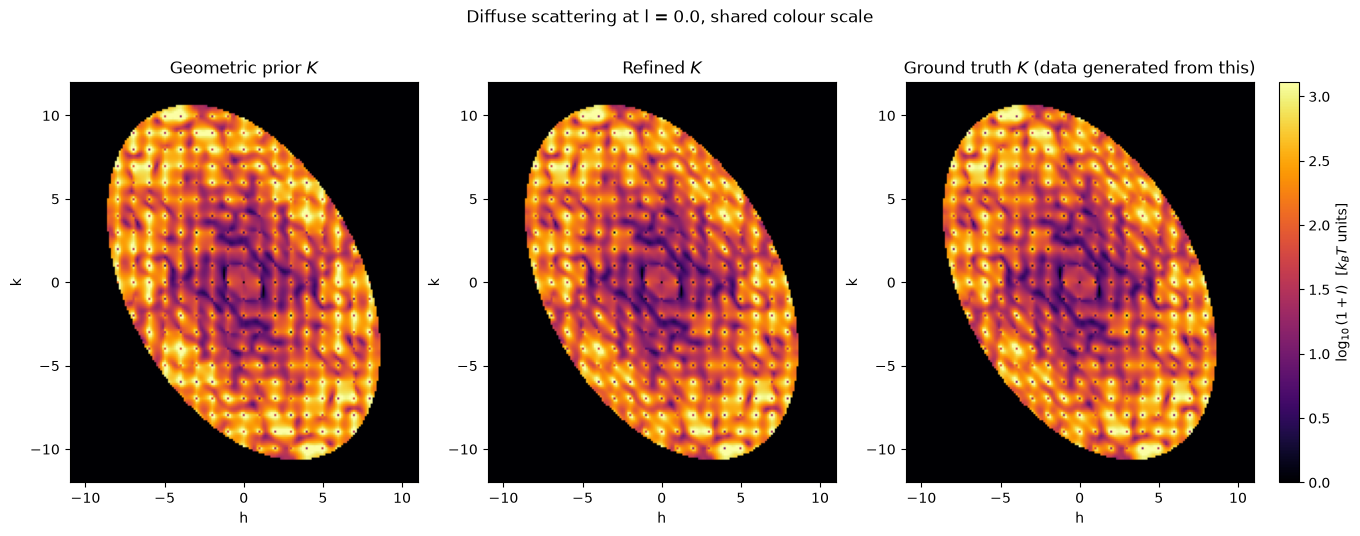


pairwise correlation over 17228 plane pixels:
   prior  vs truth :  CC = 0.957016
   fit    vs truth :  CC = 0.999946
   prior  vs fit   :  CC = 0.956799

If prior-vs-truth is already very high, the refinement had little room to
move the pattern -- which is the sloppiness of the model seen from the
observable side rather than from the parameter side.


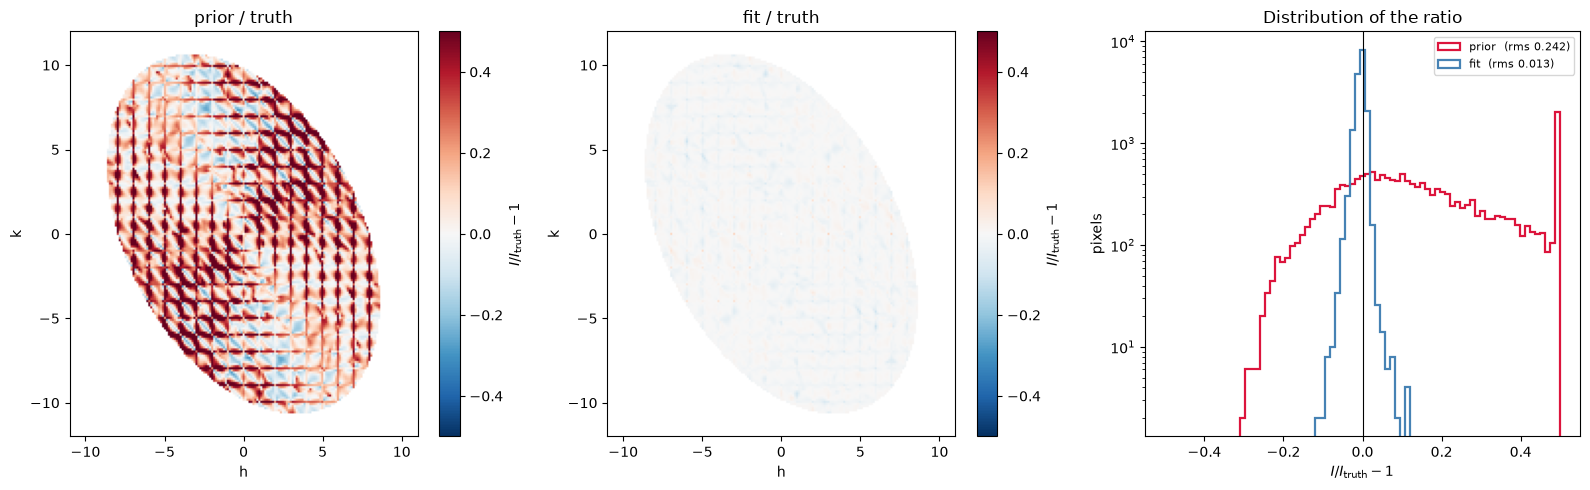

prior /truth: rms deviation  0.2415, 90th percentile |dev|  0.5289
fit   /truth: rms deviation  0.0126, 90th percentile |dev|  0.0205

This is the comparison to read, not the log maps: the log maps are
dominated by |G(q)|^2, which is the same for all three K, so they look
alike however far apart the stiffnesses are.

CC on log I over 17228 pixels (halo dominance removed):
   prior  vs truth : 0.990798
   fit    vs truth : 0.999961


In [36]:
# --- Prior / fit / truth on one colour scale -------------------------------
L_PANEL = 0.0

def _plane_intensity(K_lab, h_pts, k_pts, l_layer, G_all_plane, q_cut):
    HH, KK = np.meshgrid(h_pts, k_pts, indexing='ij')
    hf, kf = HH.ravel(), KK.ravel()
    lf = np.full_like(hf, float(l_layer))
    q  = hf[:,None]*B_recip[:,0] + kf[:,None]*B_recip[:,1] + lf[:,None]*B_recip[:,2]
    keep = (np.linalg.norm(q, axis=1) > 1e-3) & (np.linalg.norm(q, axis=1) < q_cut)
    out = np.zeros(len(hf))
    out[keep] = diffuse_intensity_batch(K_lab, hf[keep], kf[keep], lf[keep],
                                        G_arr=G_all_plane[keep])
    return out.reshape(HH.shape)

_hmax = int(np.ceil(cell.a/D_MIN_DIFFUSE))+1
_kmax = int(np.ceil(cell.b/D_MIN_DIFFUSE))+1
_qcut = 2*np.pi/D_MIN_DIFFUSE
_hp = np.arange(-_hmax*P, _hmax*P + 1)/P
_kp = np.arange(-_kmax*P, _kmax*P + 1)/P
print(f"Evaluating G once on a {len(_hp)}×{len(_kp)} plane, reused for all three panels...")
_Gpl = G_plane(_hp, _kp, L_PANEL).reshape(-1, 6)

_maps = {lab: _plane_intensity(K, _hp, _kp, L_PANEL, _Gpl, _qcut)
         for lab, K in [('prior', K_LAB_PRIOR), ('fit', K_LAB_FIT), ('truth', K_LAB_TRUE)]}

_pos = np.concatenate([m[m > 0] for m in _maps.values()])
_vmax = np.percentile(_pos, 97)
_ext = [-_hmax, _hmax, -_kmax, _kmax]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, lab, title in zip(axes, ['prior', 'fit', 'truth'],
                          ['Geometric prior $K$', 'Refined $K$',
                           'Ground truth $K$ (data generated from this)']):
    im = ax.imshow((np.log1p(np.clip(_maps[lab], 0, _vmax))/np.log(10)).T,
                   origin='lower', cmap='inferno', extent=_ext, aspect='auto',
                   vmin=0, vmax=np.log1p(_vmax)/np.log(10))
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(title)
fig.colorbar(im, ax=axes, label=r'$\log_{10}(1+I)$  [$k_BT$ units]',
             fraction=0.025, pad=0.02)
fig.suptitle(f'Diffuse scattering at l = {L_PANEL}, shared colour scale', y=1.02)
plt.savefig('map_prior_fit_truth.png', dpi=150, bbox_inches='tight'); plt.show()

_m = _maps['truth'] > 0
print(f"\npairwise correlation over {_m.sum()} plane pixels:")
for a, b in [('prior','truth'), ('fit','truth'), ('prior','fit')]:
    print(f"   {a:6s} vs {b:6s}:  CC = {np.corrcoef(_maps[a][_m], _maps[b][_m])[0,1]:.6f}")
print("\nIf prior-vs-truth is already very high, the refinement had little room to")
print("move the pattern -- which is the sloppiness of the model seen from the")
print("observable side rather than from the parameter side.")


# --- Ratio maps: where the fit actually changed anything --------------------
# On a log scale spanning five decades a 10% change is invisible, and the pattern
# is dominated by |G(q)|^2, which is identical for all three K. Dividing by the
# truth removes that common factor and leaves only what K controls.
_rt = {lab: np.where(_maps['truth'] > 0, _maps[lab]/np.maximum(_maps['truth'], 1e-300), np.nan)
       for lab in ('prior', 'fit')}
_lim = 0.5     # +-50%

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lab, title in zip(axes[:2], ['prior', 'fit'],
                          ['prior / truth', 'fit / truth']):
    im = ax.imshow(np.clip(_rt[lab]-1, -_lim, _lim).T, origin='lower', cmap='RdBu_r',
                   extent=_ext, aspect='auto', vmin=-_lim, vmax=_lim)
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(title)
    plt.colorbar(im, ax=ax, label=r'$I/I_{\rm truth}-1$')
_b = np.linspace(-_lim, _lim, 80)
for lab, col in [('prior', 'crimson'), ('fit', 'steelblue')]:
    v = (_rt[lab]-1).ravel(); v = v[np.isfinite(v)]
    axes[2].hist(np.clip(v, -_lim, _lim), bins=_b, histtype='step', lw=1.6,
                 color=col, label=f'{lab}  (rms {np.std(v):.3f})')
axes[2].axvline(0, color='k', lw=0.8); axes[2].set_yscale('log')
axes[2].set_xlabel(r'$I/I_{\rm truth}-1$'); axes[2].set_ylabel('pixels')
axes[2].set_title('Distribution of the ratio'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig('map_ratio_to_truth.png', dpi=150); plt.show()

for lab in ('prior', 'fit'):
    v = (_rt[lab]-1).ravel(); v = v[np.isfinite(v)]
    print(f"{lab:6s}/truth: rms deviation {np.std(v):7.4f}, "
          f"90th percentile |dev| {np.percentile(np.abs(v), 90):7.4f}")
print("\nThis is the comparison to read, not the log maps: the log maps are")
print("dominated by |G(q)|^2, which is the same for all three K, so they look")
print("alike however far apart the stiffnesses are.")

# --- CC on log intensity, which de-weights the halo peaks ------------------
_m2 = (_maps['truth'] > 0) & (_maps['prior'] > 0) & (_maps['fit'] > 0)
print(f"\nCC on log I over {_m2.sum()} pixels (halo dominance removed):")
for a, b in [('prior','truth'), ('fit','truth')]:
    print(f"   {a:6s} vs {b:6s}: {np.corrcoef(np.log(_maps[a][_m2]), np.log(_maps[b][_m2]))[0,1]:.6f}")


## Synthetic vs. Fitted Diffuse Scattering

The full diffuse map recomputed from the true and fitted stiffnesses, side by
side. The refinement only ever saw `I_train` at the sampled q-points; this map
compares the two models everywhere, including regions with no training data
nearby.

The two intensity panels are $\log_{10}(1+I)$; the two residual panels are
**not** log-transformed. The absolute-residual colourbar is literally
$I_{\rm fit}-I_{\rm true}$ in untransformed intensity units — and because $I$
spans many orders of magnitude between the acoustic halos and the weak mid-zone
signal, that residual is dominated by whatever happens at the brightest halo
pixels even when the fit is good everywhere else. The relative panel,
$(I_{\rm fit}-I_{\rm true})/I_{\rm true}$, divides out the local intensity scale
so good agreement in the faint mid-zone shows up instead of being swamped.

Computing I(h,k,0) at 17228 of 34161 q-points (dh=dk=1/8=0.1250)...


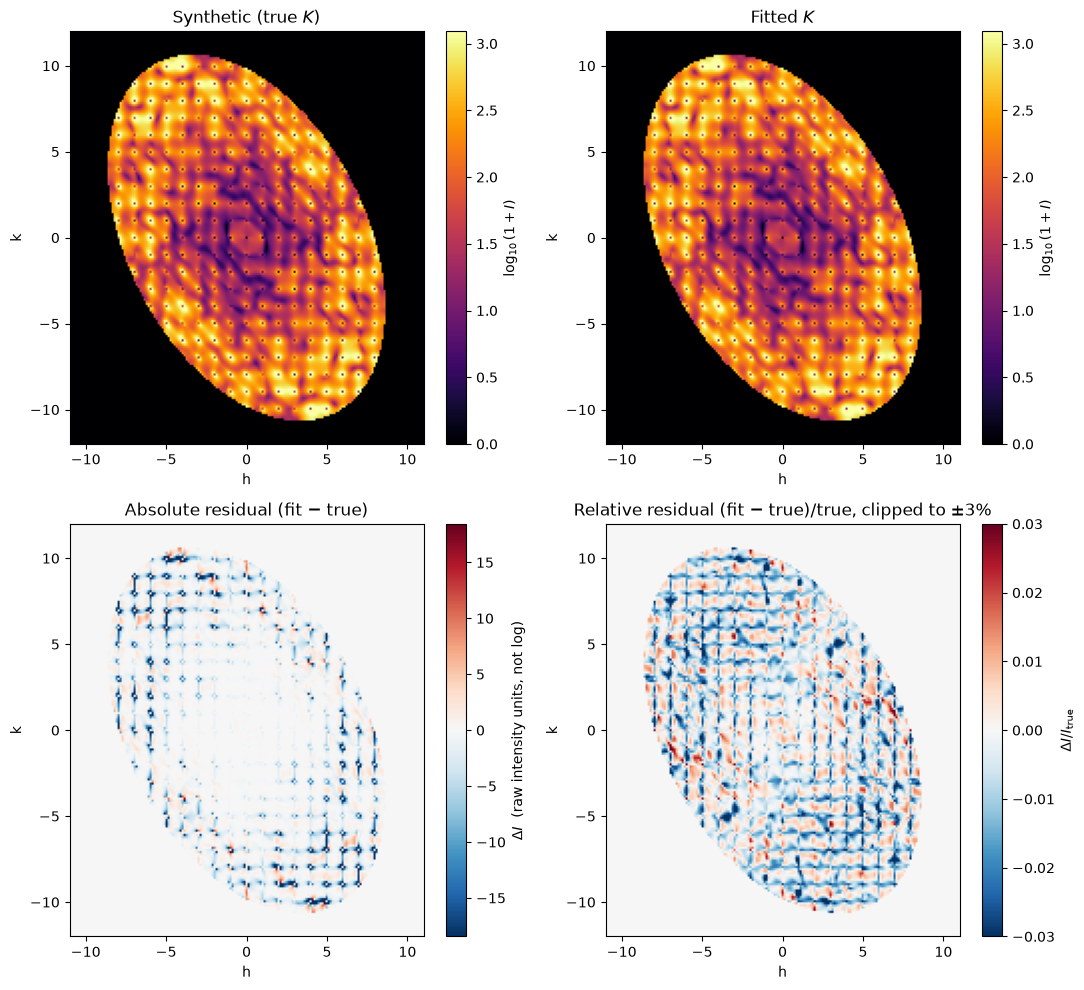

Saved diffuse_map_true_vs_fit_hk0.png
Absolute residual RMS: 4.57  (I_true RMS: 331.4)
Relative residual, unclipped — median |·|: 8.24e-05, 90th pct |·|: 0.0134


In [37]:
h_pts_cmp, k_pts_cmp, I_true_map, h_max_cmp, k_max_cmp = h_pts_bg0, k_pts_bg0, I_bg0, h_max_bg0, k_max_bg0
_, _, I_fit_map, _, _ = compute_diffuse_map(K_LAB_FIT, L_layer=0)

def plot_diffuse_comparison(h_pts, k_pts, I_true, I_fit, h_max, k_max, fname, rel_clip=1.0):
    pos_vals = np.concatenate([I_true[I_true > 0], I_fit[I_fit > 0]])
    vmax = np.percentile(pos_vals, 97) if len(pos_vals) else 1.0
    resid = I_fit - I_true
    rmax = np.percentile(np.abs(resid), 99) if np.any(resid) else 1.0

    # Relative residual: divides out the intensity scale so the (very bright)
    # near-Bragg acoustic halos don't dominate the comparison the way they do
    # in the absolute residual. A small floor avoids dividing by ~0 near the
    # dark Bragg spots themselves.
    floor = 0.02 * vmax
    rel = resid / np.maximum(I_true, floor)
    rel_disp = np.clip(rel, -rel_clip, rel_clip)

    extent = [-h_max, h_max, -k_max, k_max]
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))

    im0 = axes[0,0].imshow((np.log1p(np.clip(I_true, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='auto')
    axes[0,0].set_title('Synthetic (true $K$)')
    plt.colorbar(im0, ax=axes[0,0], label=r'$\log_{10}(1+I)$')

    im1 = axes[0,1].imshow((np.log1p(np.clip(I_fit, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='auto')
    axes[0,1].set_title('Fitted $K$')
    plt.colorbar(im1, ax=axes[0,1], label=r'$\log_{10}(1+I)$')

    im2 = axes[1,0].imshow(resid.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='auto', vmin=-rmax, vmax=rmax)
    axes[1,0].set_title('Absolute residual (fit − true)')
    plt.colorbar(im2, ax=axes[1,0], label='$\\Delta I$  (raw intensity units, not log)')

    im3 = axes[1,1].imshow(rel_disp.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='auto', vmin=-rel_clip, vmax=rel_clip)
    axes[1,1].set_title(f'Relative residual (fit − true)/true, clipped to ±{100*rel_clip:.0f}%')
    plt.colorbar(im3, ax=axes[1,1], label='$\\Delta I / I_{\\rm true}$')

    for ax in axes.flat:
        ax.set_xlabel('h'); ax.set_ylabel('k')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

    rms_resid = np.sqrt(np.mean(resid**2))
    rms_true  = np.sqrt(np.mean(I_true**2))
    print(f"Saved {fname}")
    print(f"Absolute residual RMS: {rms_resid:.4g}  (I_true RMS: {rms_true:.4g})")
    print(f"Relative residual, unclipped — median |·|: {np.median(np.abs(rel)):.3g}, "
          f"90th pct |·|: {np.percentile(np.abs(rel), 90):.3g}")

plot_diffuse_comparison(h_pts_cmp, k_pts_cmp, I_true_map, I_fit_map, h_max_cmp, k_max_cmp,
                        'diffuse_map_true_vs_fit_hk0.png', 0.03)


## Predicted Atomic Displacement Parameters

The single-cell generalized-coordinate covariance
$\Sigma=\langle(\Omega,v)(\Omega,v)^{\mathsf T}\rangle$ follows from integrating
$D(\mathbf q)^{-1}$ over the Brillouin zone. Projecting onto an atom at
$\mathbf r$ via
$\delta\mathbf r=\mathbf v+\boldsymbol\Omega\times(\mathbf r-\mathbf r_{\rm cm})$
gives that atom's full $3\times3$ tensor $U=J_r\Sigma J_r^{\mathsf T}$ — the same
object a crystallographic ANISOU record holds — with
$B=\tfrac{8\pi^2}{3}\mathrm{Tr}(U)$ as its isotropic trace.

Both models are in the same reduced ($k_BT=1$) units, so the atom-by-atom
comparison of $B$ or of the full $U$ is meaningful on an absolute scale. The
deposited ADPs are shown separately: against an arbitrarily-chosen synthetic $K$
an absolute comparison carries no meaning, and only becomes direct once $K$ is fit
to real diffuse data.

The acoustic part of the integrand behaves as $\int d^3q/q^2$ — convergent in
three dimensions but straightforward to undersample — so the Brillouin-zone grid
is offset to avoid $\Gamma$ and its convergence is checked explicitly below.

In [38]:
# Σ, the ADP projection, and the convergence check are evaluated here;
# their definitions sit with the other machinery further up, because the
# posterior propagation needs them too.
Sigma_true = bz_covariance(K_LAB_TRUE)
Sigma_fit  = bz_covariance(K_LAB_FIT)
U_true, U_fit = atom_adp_tensors(Sigma_true, apos), atom_adp_tensors(Sigma_fit, apos)
B_true, B_fit = isotropic_B(U_true), isotropic_B(U_fit)

check_bz_convergence(K_LAB_TRUE)
print()
print(f"Mean predicted B (true K):  {B_true.mean():.3f} Å²")
print(f"Mean predicted B (fit K):   {B_fit.mean():.3f} Å²   "
      f"({100*(B_fit.mean()-B_true.mean())/B_true.mean():+.2f}%)")
print(f"Mean deposited B (6o2h):    {b_exp.mean():.2f} Å²  "
      f"(not comparable on an absolute scale to an arbitrary synthetic K)")

BZ-grid convergence of the predicted mean B:
  n_grid=  8³ (   512 q-points):  mean B =    0.378 Å²
  n_grid= 12³ (  1728 q-points):  mean B =    0.385 Å²   Δ = +1.81%
  n_grid= 16³ (  4096 q-points):  mean B =    0.388 Å²   Δ = +0.85%
  n_grid= 20³ (  8000 q-points):  mean B =    0.390 Å²   Δ = +0.50%

Mean predicted B (true K):  0.390 Å²
Mean predicted B (fit K):   0.391 Å²   (+0.09%)
Mean deposited B (6o2h):    13.11 Å²  (not comparable on an absolute scale to an arbitrary synthetic K)


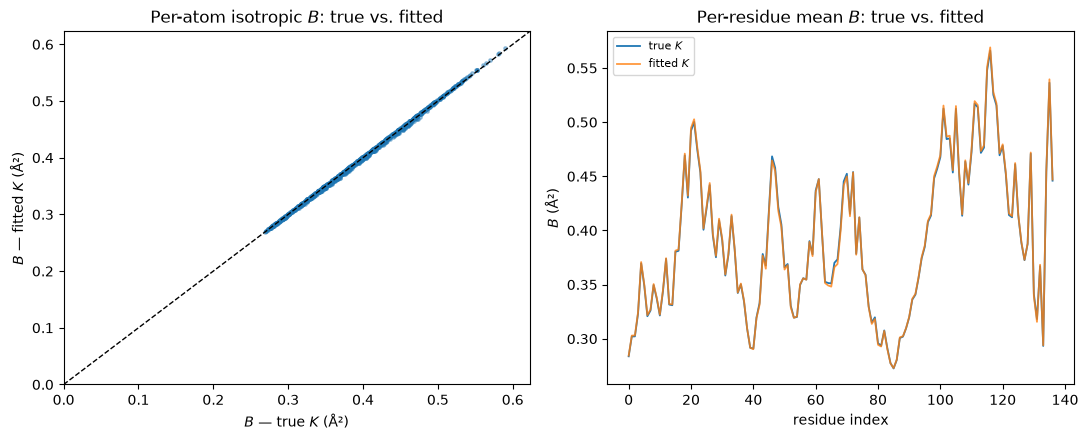

In [39]:
# Per-residue means, compared directly (true vs. fitted, same units)
res_ids = []
for ch in st[0]:
    for res in ch:
        for atom in res:
            res_ids.append((ch.name, res.seqid.num))
res_index = {}
res_inverse = np.empty(len(res_ids), dtype=int)
for i, key in enumerate(res_ids):
    res_inverse[i] = res_index.setdefault(key, len(res_index))
n_res = len(res_index)
def per_residue_mean(x):
    out = np.zeros(n_res)
    counts = np.zeros(n_res)
    for v, r in zip(x, res_inverse):
        out[r] += v; counts[r] += 1
    return out / counts

B_true_res, B_fit_res = per_residue_mean(B_true), per_residue_mean(B_fit)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ax = axes[0]
ax.scatter(B_true, B_fit, s=6, alpha=0.4)
lim = [0, max(B_true.max(), B_fit.max())*1.05]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('$B$ — true $K$ (Å²)'); ax.set_ylabel('$B$ — fitted $K$ (Å²)')
ax.set_title('Per-atom isotropic $B$: true vs. fitted')

ax = axes[1]
ax.plot(B_true_res, label='true $K$', lw=1.3)
ax.plot(B_fit_res, label='fitted $K$', lw=1.3, alpha=0.8)
ax.set_xlabel('residue index'); ax.set_ylabel('$B$ (Å²)')
ax.set_title('Per-residue mean $B$: true vs. fitted')
ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig('adp_comparison.png', dpi=150); plt.show()


### Anisotropic Comparison

The isotropic trace above discards the shape of each atom's displacement
ellipsoid. The full tensor comparison below checks whether the refinement
also recovers that shape: the six independent components of $U$ plotted
against each other (true vs. fitted, pooled over all atoms), and each
atom's anisotropy ratio (largest/smallest principal displacement) — a
model that only matches on the isotropic trace but gets the anisotropy
wrong would show good agreement in the $B$-factor plots above but poor
agreement here.


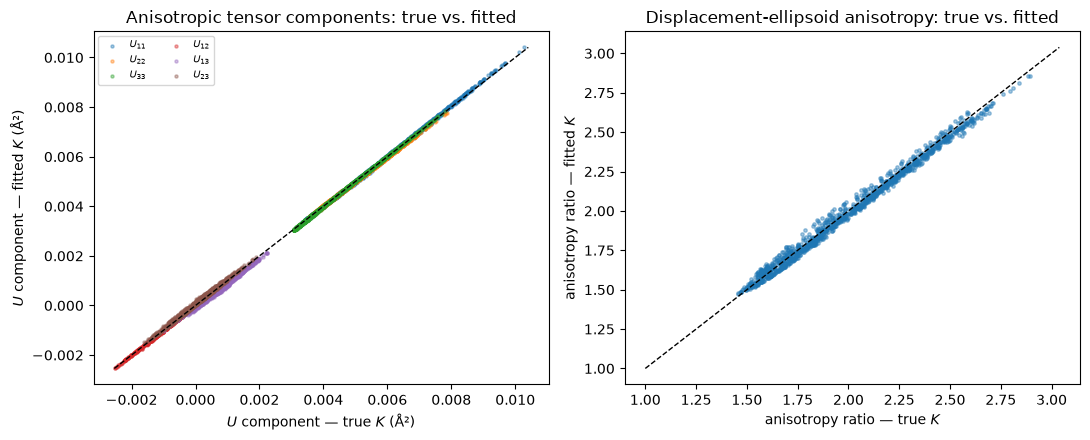

In [40]:
def anisotropy_ratio(U):
    ev = np.linalg.eigvalsh(U)
    return ev[:, -1] / np.clip(ev[:, 0], 1e-12, None)

comp_idx   = [(0,0),(1,1),(2,2),(0,1),(0,2),(1,2)]
comp_names = ['$U_{11}$','$U_{22}$','$U_{33}$','$U_{12}$','$U_{13}$','$U_{23}$']

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ax = axes[0]
for (i,j), name in zip(comp_idx, comp_names):
    ax.scatter(U_true[:,i,j], U_fit[:,i,j], s=5, alpha=0.4, label=name)
lim = [min(U_true.min(), U_fit.min()), max(U_true.max(), U_fit.max())]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('$U$ component — true $K$ (Å²)'); ax.set_ylabel('$U$ component — fitted $K$ (Å²)')
ax.set_title('Anisotropic tensor components: true vs. fitted')
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
aniso_true, aniso_fit = anisotropy_ratio(U_true), anisotropy_ratio(U_fit)
ax.scatter(aniso_true, aniso_fit, s=6, alpha=0.4)
lim2 = [1, max(aniso_true.max(), aniso_fit.max())*1.05]
ax.plot(lim2, lim2, 'k--', lw=1)
ax.set_xlabel('anisotropy ratio — true $K$'); ax.set_ylabel('anisotropy ratio — fitted $K$')
ax.set_title('Displacement-ellipsoid anisotropy: true vs. fitted')

plt.tight_layout(); plt.savefig('adp_anisotropic_comparison.png', dpi=150); plt.show()


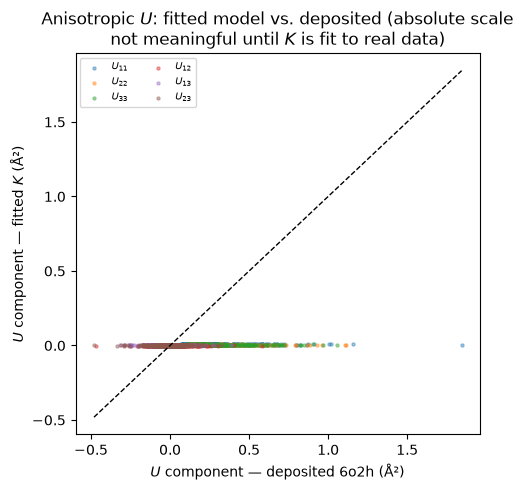

In [41]:
# Deposited ANISOU comparison, when present: this is the comparison that
# becomes meaningful once K is fit to real (not synthetic) diffuse data.
if has_aniso.mean() > 0.5:
    fig, ax = plt.subplots(figsize=(5,5))
    for (i,j), name in zip(comp_idx, comp_names):
        ax.scatter(u_exp[has_aniso,i,j], U_fit[has_aniso,i,j], s=5, alpha=0.4, label=name)
    lim = [min(u_exp[has_aniso].min(), U_fit[has_aniso].min()),
           max(u_exp[has_aniso].max(), U_fit[has_aniso].max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlabel('$U$ component — deposited 6o2h (Å²)')
    ax.set_ylabel('$U$ component — fitted $K$ (Å²)')
    ax.set_title('Anisotropic $U$: fitted model vs. deposited (absolute scale\n'
                 'not meaningful until $K$ is fit to real data)')
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig('adp_vs_deposited_anisotropic.png', dpi=150); plt.show()
else:
    print(f"Only {has_aniso.mean():.1%} of atoms in 6o2h carry ANISOU records "
          f"(full anisotropic refinement typically needs atomic resolution); "
          f"skipping the deposited anisotropic comparison. Isotropic B-factors "
          f"are compared above regardless.")


## Phonon Mode Visualization

Each phonon mode at a chosen $\mathbf q$-point is rendered as a looping GIF
of the rigid-body motion, using the fitted model. $|\Omega|$ and $|v|$ are
the rotational and translational norms of the mass-weighted eigenvector
(normalized so $\Omega^{\mathsf T}J\Omega+v^{\mathsf T}mv=1$); their ratio
gives the rotational kinetic-energy fraction, used below to label each mode
librational, translational, or mixed. Displacement amplitude is defined as
the largest per-atom displacement in Å, not the center-of-mass displacement.


In [42]:
Q_VIZ     = np.array([0.5, 0.25, 0.0])  # fractional — zone-boundary, off-axis
AMPLITUDE = 3.0    # Å — maximum per-atom displacement
N_FRAMES  = 30
GIF_FPS   = 12

q_viz  = B_recip @ Q_VIZ
D_viz  = dynamical_matrix(q_viz, unique, K_LAB_FIT)
# Complex Hermitian, as everywhere else -- Re(D) has different eigenvalues and the
# acoustic (smallest) ones are worst affected, so a .real here would animate a
# different set of modes from the ones that were fit.
Dw_viz = np.einsum('ij,jk,lk->il', Msq_inv, D_viz, Msq_inv)
ev_v, evec_v = np.linalg.eigh(Dw_viz)
ev_v      = np.maximum(ev_v, 0)
freqs_viz = np.sqrt(ev_v) * freq_unit
evecs_lab = Msq_inv.T @ evec_v          # complex, one column per mode

# A phonon eigenvector at general q is genuinely complex: the physical motion is
# Re(e e^{i(q.R - wt)}), so components lead each other in phase. For a single-cell
# animation we rotate each mode by the global phase that makes it as real as
# possible (exact for a standing mode, a good approximation otherwise) and record
# how much amplitude the residual imaginary part carries.
_phase = np.exp(-1j*np.angle(evecs_lab[np.abs(evecs_lab).argmax(axis=0),
                                       np.arange(6)]))
evecs_lab = evecs_lab * _phase[None, :]
_im_frac = np.linalg.norm(evecs_lab.imag, axis=0)/np.linalg.norm(evecs_lab, axis=0)
print(f"Residual out-of-phase amplitude per mode: {_im_frac.round(3)}")
print("  (0 = a pure standing mode the single-cell animation represents exactly;")
print("   large values mean the components genuinely lead each other in phase.)")

print(f"Modes at q={Q_VIZ}:")
hdr = f"{'Mode':>5} {'Freq (THz)':>14} {'|Ω|':>9} {'|v|':>9}  {'rot KE %':>9}  character"
print(hdr); print('-'*len(hdr))
for s in range(6):
    Om = evecs_lab[:3, s].real; v = evecs_lab[3:, s].real
    rot_KE, trans_KE = float(Om @ J @ Om), float(m_total * (v@v))
    rot_pct = 100 * rot_KE / max(rot_KE + trans_KE, 1e-30)
    char = 'librational' if rot_pct > 60 else ('translational' if rot_pct < 40 else 'mixed')
    print(f"  {s:3d}  {freqs_viz[s]:14.6f}  {np.linalg.norm(Om):9.4f}  "
          f"{np.linalg.norm(v):9.4f}  {rot_pct:9.1f}%  {char}")


Residual out-of-phase amplitude per mode: [0.405 0.441 0.217 0.122 0.642 0.137]
  (0 = a pure standing mode the single-cell animation represents exactly;
   large values mean the components genuinely lead each other in phase.)
Modes at q=[0.5  0.25 0.  ]:
 Mode     Freq (THz)       |Ω|       |v|   rot KE %  character
--------------------------------------------------------------
    0        0.312290     0.0002     0.0071        6.3%  translational
    1        0.348687     0.0002     0.0069        8.2%  translational
    2        0.447073     0.0000     0.0078        0.5%  translational
    3        1.161441     0.0007     0.0024       91.4%  librational
    4        1.253211     0.0007     0.0003       99.9%  librational
    5        1.506733     0.0008     0.0020       94.1%  librational


In [43]:
# Molecular isosurface: marching cubes on the CALCULATED model density
# (rho_model, built alongside the phases -- the transform used for G runs on
# the unwrapped hybrid density, not on this grid), downsampled
# for speed, keeping only the largest connected component so periodic-image
# and solvent-void fragments are discarded, then Lambert-shaded per face so
# shape and roughness stay visible even at partial transparency.
base_pos = apos.copy()
pts_cm   = base_pos - r_cm_at

MC_DS = 0.5
rho_mc = nd_zoom(rho_model.astype(np.float32), MC_DS, order=1)
nu_mc, nv_mc, nw_mc = rho_mc.shape
_iso_level = rho_mc.max() * 0.05
mc_verts_grid, mc_faces_raw, _normals, _vals = marching_cubes(rho_mc, level=_iso_level)
_frac = mc_verts_grid / np.array([nu_mc, nv_mc, nw_mc])
mc_verts_raw = (A_orth @ _frac.T).T

def _largest_component(verts, faces):
    n = len(verts)
    idx_i = np.concatenate([faces[:,0], faces[:,1], faces[:,2]])
    idx_j = np.concatenate([faces[:,1], faces[:,2], faces[:,0]])
    adj   = csr_matrix((np.ones(len(idx_i), dtype=np.int8), (idx_i, idx_j)), shape=(n, n))
    _, labels = sc_connected_components(adj, directed=False)
    keep_label = np.bincount(labels).argmax()
    keep = np.where(labels == keep_label)[0]
    remap = np.full(n, -1, dtype=int); remap[keep] = np.arange(len(keep))
    face_ok = (labels[faces] == keep_label).all(axis=1)
    return verts[keep], remap[faces[face_ok]]

mc_verts_cart, mc_faces = _largest_component(mc_verts_raw, mc_faces_raw)
mc_verts_cm = mc_verts_cart - r_cm_at
print(f"Isosurface: {len(mc_verts_cm)} verts, {len(mc_faces)} tris "
      f"(largest connected component, level={_iso_level:.3f} e/Å³)")

_LIGHT = np.array([0.5, 0.8, 1.0]); _LIGHT /= np.linalg.norm(_LIGHT)

def _shade(tri_array, hex_color, alpha, ambient=0.35):
    v0, v1, v2 = tri_array[:,0], tri_array[:,1], tri_array[:,2]
    n = np.cross(v1 - v0, v2 - v0)
    mag = np.linalg.norm(n, axis=1, keepdims=True)
    n /= np.where(mag > 1e-12, mag, 1.0)
    intensity = ambient + (1 - ambient) * np.abs(n @ _LIGHT)
    r = int(hex_color[1:3], 16) / 255
    g = int(hex_color[3:5], 16) / 255
    b = int(hex_color[5:7], 16) / 255
    return np.column_stack([intensity*r, intensity*g, intensity*b, np.full(len(tri_array), alpha)])

def displaced_mc(mode_idx, scale):
    Om_raw = evecs_lab[:3, mode_idx].real.copy()
    v_raw  = evecs_lab[3:, mode_idx].real.copy()
    norm_vec = np.sqrt(Om_raw @ Om_raw + v_raw @ v_raw)
    if norm_vec < 1e-10:
        return mc_verts_cm + r_cm_at
    Om_u, v_u = Om_raw/norm_vec, v_raw/norm_vec
    delta_unit = v_u[None,:] + np.cross(Om_u[None,:], pts_cm)
    max_d = np.linalg.norm(delta_unit, axis=1).max()
    if max_d < 1e-12:
        return mc_verts_cm + r_cm_at
    fac = scale / max_d
    Om_s, v_s = fac*Om_u, fac*v_u
    if abs(fac)*np.linalg.norm(Om_u) > 1e-10:
        return Rot.from_rotvec(Om_s).apply(mc_verts_cm) + r_cm_at + v_s
    return mc_verts_cm + r_cm_at + v_s

eq_bbox_min = mc_verts_cart.min(axis=0)
eq_bbox_max = mc_verts_cart.max(axis=0)


Isosurface: 10744 verts, 21090 tris (largest connected component, level=0.404 e/Å³)


In [44]:
MODE_COLORS = ['#4e9de0', '#e05c5c', '#4fba74', '#e0b14e', '#a56be0', '#e07e4e']
SURF_ALPHA  = 0.65
ELEV, AZIM  = 20, -60

def make_mode_gif(mode_idx, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS, fname=None, figsize=(6,5)):
    """Render one phonon mode as a looping GIF and save it to disk (no
    in-notebook display, and memory is freed after each mode)."""
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'mode_{mode_idx}_q{qstr}.gif'
    color  = MODE_COLORS[mode_idx % len(MODE_COLORS)]
    scales = amplitude * np.sin(2*np.pi*np.arange(n_frames)/n_frames)
    pad = amplitude * 2.5
    xlim = (eq_bbox_min[0]-pad, eq_bbox_max[0]+pad)
    ylim = (eq_bbox_min[1]-pad, eq_bbox_max[1]+pad)
    zlim = (eq_bbox_min[2]-pad, eq_bbox_max[2]+pad)

    Om_r = evecs_lab[:3, mode_idx].real
    rot_KE   = float(Om_r @ J @ Om_r)
    trans_KE = m_total * float(np.linalg.norm(evecs_lab[3:, mode_idx].real)**2)
    rot_pct  = 100*rot_KE/(rot_KE+trans_KE+1e-30)

    images = []
    for sc in scales:
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            verts = displaced_mc(mode_idx, sc)
            tris  = verts[mc_faces]
            rgba  = _shade(tris, color, SURF_ALPHA)
            poly  = Poly3DCollection(tris, facecolors=rgba, linewidths=0, edgecolor='none')
            ax.add_collection3d(poly)
            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off(); ax.view_init(elev=ELEV, azim=AZIM)
            ax.set_title(f'Mode {mode_idx}   {freqs_viz[mode_idx]:.4f} THz\n'
                         f'q={list(Q_VIZ)}   rot {rot_pct:.0f}%  trans {100-rot_pct:.0f}%',
                         color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig))
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

print(f"Generating surface GIFs at q={Q_VIZ} (amplitude={AMPLITUDE} Å max per-atom)...")
for s in range(6):
    print(f"Mode {s}: {freqs_viz[s]:.6f} THz", end="  ... ")
    try:
        path = make_mode_gif(s)
        print(f"saved -> {path}")
    except Exception as e:
        print(f"FAILED: {e}")
    gc.collect()
print("Load any GIF with: display(IPImage(filename='mode_N_q....gif'))")


Generating surface GIFs at q=[0.5  0.25 0.  ] (amplitude=3.0 Å max per-atom)...
Mode 0: 0.312290 THz  ... saved -> mode_0_q0.50_0.25_0.00.gif
Mode 1: 0.348687 THz  ... saved -> mode_1_q0.50_0.25_0.00.gif
Mode 2: 0.447073 THz  ... saved -> mode_2_q0.50_0.25_0.00.gif
Mode 3: 1.161441 THz  ... saved -> mode_3_q0.50_0.25_0.00.gif
Mode 4: 1.253211 THz  ... saved -> mode_4_q0.50_0.25_0.00.gif
Mode 5: 1.506733 THz  ... saved -> mode_5_q0.50_0.25_0.00.gif
Load any GIF with: display(IPImage(filename='mode_N_q....gif'))


In [45]:
# Supercell wave: each cell (i,j,k) is a rigid copy displaced by
# amplitude * cos(2*pi*q_frac.[i,j,k] + phase). The central cell is
# colored distinctly from its neighbors so the propagating wave pattern
# can be read off against a fixed reference point.
SUPER_N1, SUPER_N2, SUPER_N3 = 3, 3, 1   # a full 3x3x3 renders 27 isosurfaces per
                                          # frame and can exhaust notebook-kernel memory;
                                          # 3x3x1 already shows the in-plane wave pattern
MODE_SUPER   = 0
SUPER_COLOR  = '#4e9de0'
SUPER_ALPHA  = 0.38
CENTER_COLOR = '#e05c5c'
CENTER_ALPHA = 0.55

def make_supercell_gif(mode_idx=MODE_SUPER, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS,
                       n1=SUPER_N1, n2=SUPER_N2, n3=SUPER_N3, fname=None, figsize=(10,9)):
    if fname is None:
        qstr = '_'.join(f'{x:.2f}' for x in Q_VIZ)
        fname = f'supercell_mode{mode_idx}_q{qstr}.gif'

    cells_ijk = [(i,j,k) for i in range(n1) for j in range(n2) for k in range(n3)]
    center_ijk = (n1//2, n2//2, n3//2)
    phase0 = np.array([2*np.pi*(Q_VIZ[0]*i + Q_VIZ[1]*j + Q_VIZ[2]*k) for i,j,k in cells_ijk])
    T_cell = np.array([i*a1 + j*a2 + k*a3 for i,j,k in cells_ijk])

    all_eq = np.vstack([mc_verts_cart + T for T in T_cell])
    pad = amplitude * 2.5
    xlim = (all_eq[:,0].min()-pad, all_eq[:,0].max()+pad)
    ylim = (all_eq[:,1].min()-pad, all_eq[:,1].max()+pad)
    zlim = (all_eq[:,2].min()-pad, all_eq[:,2].max()+pad)

    images = []
    for fi in range(n_frames):
        t = 2*np.pi*fi/n_frames
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax  = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            for (i,j,k), T, ph0 in zip(cells_ijk, T_cell, phase0):
                sc = amplitude * np.cos(ph0 + t)
                verts = displaced_mc(mode_idx, sc) + T
                tris_v = verts[mc_faces]
                is_center = (i,j,k) == center_ijk
                color = CENTER_COLOR if is_center else SUPER_COLOR
                alpha = CENTER_ALPHA if is_center else SUPER_ALPHA
                rgba = _shade(tris_v, color, alpha)
                poly = Poly3DCollection(tris_v, facecolors=rgba, linewidths=0, edgecolor='none')
                ax.add_collection3d(poly)

            ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
            ax.set_axis_off(); ax.view_init(elev=25, azim=-55)
            ax.set_title(f'Supercell phonon — Mode {mode_idx}  {freqs_viz[mode_idx]:.4f} THz\n'
                         f'q={list(Q_VIZ)}   {n1}×{n2}×{n3} cells (center cell highlighted)',
                         color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig))
        finally:
            plt.close(fig)

    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

print(f"Generating {SUPER_N1}×{SUPER_N2}×{SUPER_N3} supercell GIF for mode {MODE_SUPER}...")
try:
    sc_path = make_supercell_gif()
    print(f"Saved -> {sc_path}")
except Exception as e:
    print(f"Supercell GIF failed: {e}")
    import traceback; traceback.print_exc()


Generating 3×3×1 supercell GIF for mode 0...
Saved -> supercell_mode0_q0.50_0.25_0.00.gif


## Summary

| Output | File | Description |
|--------|------|-------------|
| Solvent contrast | `solvent_contrast.png` | Density profile into the protein, contrast profile, contrast histogram |
| Band structure | `band_structure.png` | Phonon dispersion Γ–X–Y–Z–Γ (geometric prior) |
| Diffuse map l=0 | `diffuse_map_hk0.png`, `diffuse_map_cart_hk0.png` | TDS in the hk0 plane |
| Diffuse map l=0.5 | `diffuse_map_hk05.png`, `diffuse_map_cart_hk05.png` | TDS at half-integer l |
| Sampled q-points | `sampled_q_points.png` | 3D Cartesian view plus per-layer overlays |
| Refinement fit quality | `refinement_fit_quality.png` | $I_{\rm obs}$ vs $I_{\rm model}$, training and held-out |
| Band-structure convergence | `band_structure_convergence.gif` | True vs. fit, frame per L-BFGS-B iteration |
| Sloppiness spectrum | `sloppiness_spectrum.png` | Gauss-Newton eigenvalues; how many parameters the data determines |
| Synthetic vs. fitted map | `diffuse_map_true_vs_fit_hk0.png` | True $K$, fitted $K$, and residuals |
| ADP comparison (isotropic) | `adp_comparison.png` | Per-atom and per-residue $B$: true vs. fitted |
| ADP comparison (anisotropic) | `adp_anisotropic_comparison.png` | Full $U$ components and anisotropy ratio |
| ADP vs. deposited | `adp_vs_deposited_anisotropic.png` | Fitted model vs. 6o2h ANISOU |
| Mode GIFs | `mode_N_q*.gif` | All 6 modes at the chosen q-point |
| Supercell wave | `supercell_mode*.gif` | 3×3×1 supercell phonon wave |

**Molecular transform.** $F$ and $L$ come from the hybrid electron density —
measured amplitudes with model phases — reduced to the solvent-contrast density
$\rho_{\rm eff}=\rho-\rho_{\rm sol}M$ and unwrapped onto a single molecule, each
voxel carrying the phase $e^{+2\pi i(h,k,l)\cdot\mathbf n_v}$ of the lattice image
it belongs to. Checked three ways: against the measured amplitudes at integer
$hkl$ binned by resolution, against brute-force summation over explicitly
unwrapped coordinates at fractional $hkl$, and the separable plane path against
the scattered-point path.

**Contact stiffness.** Six distinct contacts — distinct, not symmetry-distinct,
since $P1$ has no point symmetry — each an independent $6\times6$ matrix specified
in a frame anchored at the measured contact centroid via a Cholesky factor
$K=LL^{\mathsf T}$. The prior is the stiffness of $n$ isotropic point springs at
the atom-pair midpoints, supplying the contact-count scaling, the
$\kappa_R/\kappa_T\sim\rho_g^2$ ratio, and the patch anisotropy. Refinement is
regularized toward it under the geodesic metric on positive-definite matrices,
which respects the mixed units of $K$ and is invariant to the choice of reference
point and axes.

**Refinement.** L-BFGS-B on the Cholesky parameters with an analytic gradient
checked against finite differences, vectorized over the point batch. Training and
held-out $R$ and $CC$ are both reported, and the Gauss-Newton spectrum states how
many of the 126 parameters the data actually determines.